In [1]:
import numpy as np
import scipy.linalg as la
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib import rcParams
from TurbCurv import orr_sommerfeld, orr_sommerfeld_non_uniform_nuT_ij, orr_sommerfeld_non_uniform_nuT_ij_iterative_debug
from TurbCurv import orr_sommerfeld_non_uniform, D_matrices_non_uniform, solve_bvp_model, orr_sommerfeld_non_uniform_nuT_ij_Chebyshev
from TurbCurv import chebyshev_grid, chebyshev_diff_matrix, interpolate_to_chebyshev
from scipy import integrate
import h5py
import cmath
from scipy.interpolate import CubicSpline
from scipy.interpolate import UnivariateSpline
from findiff import FinDiff
from scipy.integrate import cumtrapz
%matplotlib inline
plt.rc('text',usetex=True)
plt.rc('font',family='serif')
rcParams.update({'figure.autolayout': True})

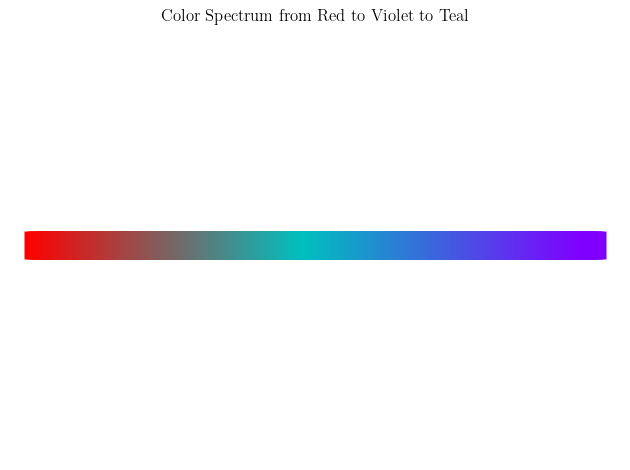

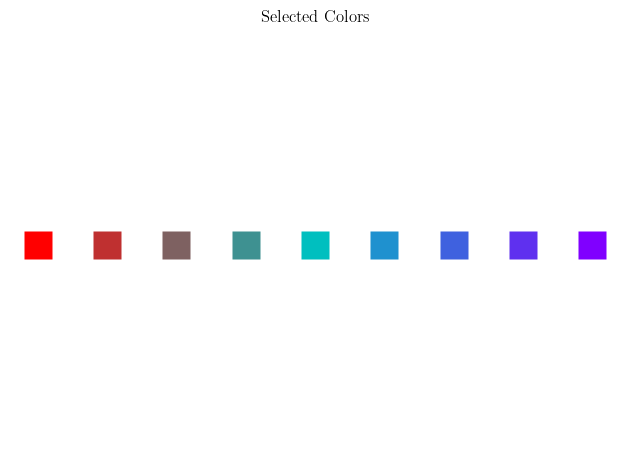

In [2]:
# Define the colors
color1 = np.array([1, 0, 0])  # red
color5 = np.array([0, 0.75, 0.75])  # teal
color9 = np.array([0.5, 0, 1])  # violet

# Number of intermediate colors
num_colors = 100

# Interpolate colors between color1 and color5
colors1_to_5 = np.linspace(color1, color5, num_colors)

# Interpolate colors between color5 and color9
colors5_to_9 = np.linspace(color5, color9, num_colors)

# Combine the colors to form a full spectrum
full_spectrum = np.vstack((colors1_to_5, colors5_to_9))

# Pick 9 colors evenly distributed across the spectrum
indices = np.round(np.linspace(0, full_spectrum.shape[0] - 1, 9)).astype(int)
selected_colors = full_spectrum[indices]

# Store the selected colors in a list
color_array = [list(selected_colors[i]) for i in range(9)]

# Plot the spectrum
plt.figure()
for i in range(full_spectrum.shape[0]):
    plt.plot(i, 1, 's', markersize=20, markeredgecolor='none', markerfacecolor=full_spectrum[i])
plt.axis('off')
plt.title('Color Spectrum from Red to Violet to Teal')
plt.show()

# Display the selected colors
plt.figure()
for i in range(9):
    plt.plot(i, 1, 's', markersize=20, markeredgecolor='none', markerfacecolor=selected_colors[i])
plt.axis('off')
plt.title('Selected Colors')
plt.show()


In [3]:
color_blue = np.array([0.12156862745098039, 0.4666666666666667, 0.7058823529411765])  # Blue
color_orange = np.array([1, 0.5, 0])  # Orange
color_green = np.array([0.17254901960784313, 0.6274509803921569, 0.17254901960784313])#np.array([0, 1, 0])  # Green
color_red_brown = np.array([0.8392156862745098, 0.15294117647058825, 0.1568627450980392])#np.array([0.6, 0, 0])  # Dark red or brownish red
color_purple = np.array([0.5, 0, 1])  # Purple/Violet
color_red_dashed = np.array([1, 0, 0])  # Red

limited_color_array = [
    color_blue, 
    color_orange, 
    color_green, 
    color_red_brown, 
    color_purple, 
    color_red_dashed
]

color_array_with_flat_wall = [color_array[0],color_array[1],color_array[2],color_array[3],color_array[4],color_array[5], \
                              color_array[6],color_array[7],color_array[8],'k']

In [4]:
def mape(y_true, y_pred): 
    """
    Calculate Mean Absolute Percentage Error (MAPE)

    Args:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: MAPE value
    """

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # Avoid division by zero
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100



In [6]:
def ddxi_fft(f, x, kx):
    f_hat     = np.fft.fft(f)
    df_dx_hat = 1j*kx*f_hat
    df_dx     = np.real(np.fft.ifft(df_dx_hat))
    return df_dx


In [7]:
cd '/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv'

/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv


In [8]:
filename=['phase_averaged_data_all_10_c-25.mat', 
          'phase_averaged_data_all_09_c-15.mat', 
          'phase_averaged_data_all_08_c-7.mat', 
          'phase_averaged_data_all_07_c-2.mat', 
          'phase_averaged_data_all_06_c0.mat', 
          'phase_averaged_data_all_02_c2.mat', 
          'phase_averaged_data_all_03_c7.mat', 
          'phase_averaged_data_all_04_c15.mat',
          'phase_averaged_data_all_05_c25.mat',
          'phase_averaged_data_all_01_flat.mat'];

filename_TKE=['TKE_budget_terms_10_c-25.mat', 
              'TKE_budget_terms_09_c-15.mat', 
              'TKE_budget_terms_08_c-7.mat', 
              'TKE_budget_terms_07_c-2.mat', 
              'TKE_budget_terms_06_c0.mat', 
              'TKE_budget_terms_02_c2.mat', 
              'TKE_budget_terms_03_c7.mat', 
              'TKE_budget_terms_04_c15.mat',
              'TKE_budget_terms_05_c25.mat',
              'TKE_budget_terms_01_flat.mat'];


c_array=[-25,-15,-7,-2,0,2,7,15,25,0];
limited_c_array_index=[0,3,4,5,8]
limited_color_array = [color_array[0],color_array[3],color_array[4],color_array[5],color_array[8]]
num_data=np.size(c_array)
num_data

10

In [9]:
#### Read in profiles from mat files
sully_path='/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/data/phase_averaged_and_TKE_data/'

class profile_mat_data:
    def __init__(self,Filename):
        DATA=sio.loadmat(Filename)
        zi=1
        Nx=864;
        Ny=576;
        Nz=144;

        self.eta = DATA['eta_phase_avg']
        self.u_w_surf = DATA['u_w_phase_avg'][:,0]-np.mean(DATA['u_w_phase_avg'][:,0],axis=0)
        self.w_surf   = DATA['w_phase_avg'][:,0]-np.mean(DATA['w_phase_avg'][:,0],axis=0)
        self.w   = DATA['w_phase_avg'][:,:]-np.mean(DATA['w_phase_avg'][:,:],axis=0)
        self.w_phase_avg   = DATA['w_phase_avg'][:,:]
        self.w_mean = np.mean(DATA['w_phase_avg'],axis=0)

        self.u_w_t_avg_mean = np.mean(DATA['u_w_time_avg'][:,:],axis=0)
        self.v_w_t_avg_mean = np.mean(DATA['v_w_time_avg'][:,:],axis=0)
        self.w_t_avg_mean   = np.mean(DATA['w_time_avg'][:,:],axis=0)
  
        
        self.W   = DATA['W_phase_avg'][:,:]-np.mean(DATA['W_phase_avg'][:,:],axis=0)
        self.W_phase_avg = DATA['W_phase_avg'][:,:]
        self.W_mean = np.mean(DATA['W_phase_avg'],axis=0)
        
        self.u_w = DATA['u_w_phase_avg'][:,:]-np.mean(DATA['u_w_phase_avg'][:,:],axis=0)
        self.v_w = DATA['v_w_phase_avg'][:,:]-np.mean(DATA['v_w_phase_avg'][:,:],axis=0)
        self.u_w_phase_avg = DATA['u_w_phase_avg'][:,:]
        self.v_w_phase_avg = DATA['v_w_phase_avg'][:,:]
        self.u_mean =  np.mean(DATA['u_w_phase_avg'],axis=0)
        self.v_mean =  np.mean(DATA['v_w_phase_avg'],axis=0)
        
        ##############################################################################################################
        
        self.U = DATA['U_phase_avg'][:,:]-np.mean(DATA['U_phase_avg'][:,:],axis=0)
        self.U_phase_avg = DATA['U_phase_avg'][:,:]
       
        self.V_phase_avg = DATA['V_phase_avg'][:,:]
        
        self.U_mean   = np.mean(DATA['U_phase_avg'],axis=0)
        
        self.uU_phase_avg = DATA['uU_phase_avg'][:,:]
        self.vU_phase_avg = DATA['vU_phase_avg'][:,:]
        self.wU_phase_avg = DATA['wU_phase_avg'][:,:]

        self.uV_phase_avg = DATA['uV_phase_avg'][:,:]
        self.vV_phase_avg = DATA['vV_phase_avg'][:,:]
        self.wV_phase_avg = DATA['wV_phase_avg'][:,:]

        self.uW_phase_avg = DATA['uW_phase_avg'][:,:]
        self.vW_phase_avg = DATA['vW_phase_avg'][:,:]
        self.wW_phase_avg = DATA['wW_phase_avg'][:,:]
        
        self.uiuiU_phase_avg = DATA['uiuiU_phase_avg'][:,:]
        self.uiuiW_phase_avg = DATA['uiuiW_phase_avg'][:,:]
        
        self.uu_w_phase_avg  = DATA['uu_w_phase_avg'][:,:]
        self.vv_w_phase_avg  = DATA['vv_w_phase_avg'][:,:]
        self.ww_phase_avg    = DATA['ww_phase_avg'][:,:]

        self.upup_phase_avg  = DATA['uu_w_phase_avg'][:,:] - DATA['u_w_phase_avg'][:,:]*DATA['u_w_phase_avg'][:,:]
        self.vpvp_phase_avg  = DATA['vv_w_phase_avg'][:,:] - DATA['v_w_phase_avg'][:,:]*DATA['v_w_phase_avg'][:,:]
        self.wpwp_phase_avg  =   DATA['ww_phase_avg'][:,:] -   DATA['w_phase_avg'][:,:]*DATA['w_phase_avg'][:,:]

        self.upwp_phase_avg  = DATA['uw_phase_avg'][:,:] - DATA['u_w_phase_avg'][:,:]*DATA['w_phase_avg'][:,:]
        self.vpwp_phase_avg  = DATA['vw_phase_avg'][:,:] - DATA['v_w_phase_avg'][:,:]*DATA['w_phase_avg'][:,:]
        self.upvp_phase_avg  = DATA['uv_phase_avg'][:,:] - DATA['u_w_phase_avg'][:,:]*DATA['v_w_phase_avg'][:,:]

        self.upup_d_phase_avg=self.upup_phase_avg - (1/3)*(self.upup_phase_avg + self.vpvp_phase_avg + self.wpwp_phase_avg)
        self.vpvp_d_phase_avg=self.vpvp_phase_avg - (1/3)*(self.upup_phase_avg + self.vpvp_phase_avg + self.wpwp_phase_avg)
        self.wpwp_d_phase_avg=self.wpwp_phase_avg - (1/3)*(self.upup_phase_avg + self.vpvp_phase_avg + self.wpwp_phase_avg)
        
        

        self.zw=DATA['zw']*zi
        
        ##############################################################################################################
        self.tau11       = (DATA['tau11_phase_avg']-np.mean(DATA['tau11_phase_avg'][:,:],axis=0))
        self.tau11_mean  = np.mean(DATA['tau11_phase_avg'],axis=0)

        self.tau12        = (DATA['tau12_phase_avg']-np.mean(DATA['tau12_phase_avg'][:,:],axis=0))
        self.tau12_mean   = np.mean(DATA['tau12_phase_avg'],axis=0)
                
        self.tau13        = (DATA['tau13_phase_avg']-np.mean(DATA['tau13_phase_avg'][:,:],axis=0))
        self.tau13_mean   = np.mean(DATA['tau13_phase_avg'],axis=0)

        self.tau21       = (DATA['tau21_phase_avg']-np.mean(DATA['tau21_phase_avg'][:,:],axis=0))
        self.tau21_mean  = np.mean(DATA['tau21_phase_avg'],axis=0)

        self.tau22       = (DATA['tau22_phase_avg']-np.mean(DATA['tau22_phase_avg'][:,:],axis=0))
        self.tau22_mean  = np.mean(DATA['tau22_phase_avg'],axis=0)

        self.tau23       = (DATA['tau23_phase_avg']-np.mean(DATA['tau23_phase_avg'][:,:],axis=0))
        self.tau23_mean  = np.mean(DATA['tau23_phase_avg'],axis=0)
        
        
        self.tau31        = (DATA['tau31_phase_avg']-np.mean(DATA['tau31_phase_avg'][:,:],axis=0))
        self.tau31_mean   = np.mean(DATA['tau31_phase_avg'],axis=0)

        self.tau32        = (DATA['tau32_phase_avg']-np.mean(DATA['tau32_phase_avg'][:,:],axis=0))
        self.tau32_mean   = np.mean(DATA['tau32_phase_avg'],axis=0)

        self.tau33      = (DATA['tau33_phase_avg']-np.mean(DATA['tau33_phase_avg'][:,:],axis=0))
        self.tau33_mean = np.mean(DATA['tau33_phase_avg'],axis=0)
        
        
        ##############################################################################################################

        self.tau11_SGS      = (DATA['tau11_SGS_phase_avg']-np.mean(DATA['tau11_SGS_phase_avg'][:,:],axis=0))
        self.tau11_SGS_mean = np.mean(DATA['tau11_SGS_phase_avg'],axis=0)
        
        self.tau12_SGS      = (DATA['tau12_SGS_phase_avg']-np.mean(DATA['tau12_SGS_phase_avg'][:,:],axis=0))
        self.tau12_SGS_mean = np.mean(DATA['tau12_SGS_phase_avg'],axis=0)

        self.tau13_SGS      = (DATA['tau13_SGS_phase_avg']-np.mean(DATA['tau13_SGS_phase_avg'][:,:],axis=0))
        self.tau13_SGS_mean = np.mean(DATA['tau13_SGS_phase_avg'],axis=0)

        self.tau21_SGS      = (DATA['tau21_SGS_phase_avg']-np.mean(DATA['tau21_SGS_phase_avg'][:,:],axis=0))
        self.tau21_SGS_mean = np.mean(DATA['tau21_SGS_phase_avg'],axis=0)
        
        self.tau22_SGS      = (DATA['tau22_SGS_phase_avg']-np.mean(DATA['tau22_SGS_phase_avg'][:,:],axis=0))
        self.tau22_SGS_mean = np.mean(DATA['tau22_SGS_phase_avg'],axis=0)

        self.tau23_SGS       = (DATA['tau23_SGS_phase_avg']-np.mean(DATA['tau23_SGS_phase_avg'][:,:],axis=0))
        self.tau23_SGS_mean  = np.mean(DATA['tau23_SGS_phase_avg'],axis=0)

        self.tau31_SGS      = (DATA['tau31_SGS_phase_avg']-np.mean(DATA['tau31_SGS_phase_avg'][:,:],axis=0))
        self.tau31_SGS_mean = np.mean(DATA['tau31_SGS_phase_avg'],axis=0)

        self.tau32_SGS      = (DATA['tau32_SGS_phase_avg']-np.mean(DATA['tau32_SGS_phase_avg'][:,:],axis=0))
        self.tau32_SGS_mean = np.mean(DATA['tau32_SGS_phase_avg'],axis=0)

        self.tau33_SGS      = (DATA['tau33_SGS_phase_avg']-np.mean(DATA['tau33_SGS_phase_avg'][:,:],axis=0))
        self.tau33_SGS_mean = np.mean(DATA['tau33_SGS_phase_avg'],axis=0)
        
        
        ##############################################################################################################
        self.tau11_nu      = (DATA['tau11_nu_phase_avg']-np.mean(DATA['tau11_nu_phase_avg'][:,:],axis=0))
        self.tau11_nu_mean = np.mean(DATA['tau11_nu_phase_avg'],axis=0)

        self.tau12_nu      = (DATA['tau12_nu_phase_avg']-np.mean(DATA['tau12_nu_phase_avg'][:,:],axis=0))
        self.tau12_nu_mean = np.mean(DATA['tau12_nu_phase_avg'],axis=0)

        self.tau13_nu       = (DATA['tau13_nu_phase_avg']-np.mean(DATA['tau13_nu_phase_avg'][:,:],axis=0))
        self.tau13_nu_mean  = np.mean(DATA['tau13_nu_phase_avg'],axis=0)

        self.tau21_nu      = (DATA['tau21_nu_phase_avg']-np.mean(DATA['tau21_nu_phase_avg'][:,:],axis=0))
        self.tau21_nu_mean = np.mean(DATA['tau21_nu_phase_avg'],axis=0)

        self.tau22_nu      = (DATA['tau22_nu_phase_avg']-np.mean(DATA['tau22_nu_phase_avg'][:,:],axis=0))
        self.tau22_nu_mean = np.mean(DATA['tau22_nu_phase_avg'],axis=0)

        self.tau23_nu       = (DATA['tau23_nu_phase_avg']-np.mean(DATA['tau23_nu_phase_avg'][:,:],axis=0))
        self.tau23_nu_mean  = np.mean(DATA['tau23_nu_phase_avg'],axis=0)

        self.tau31_nu       = (DATA['tau31_nu_phase_avg']-np.mean(DATA['tau31_nu_phase_avg'][:,:],axis=0))
        self.tau31_nu_mean  = np.mean(DATA['tau31_nu_phase_avg'],axis=0)

        self.tau32_nu       = (DATA['tau32_nu_phase_avg']-np.mean(DATA['tau32_nu_phase_avg'][:,:],axis=0))
        self.tau32_nu_mean  = np.mean(DATA['tau32_nu_phase_avg'],axis=0)

        self.tau33_nu      = (DATA['tau33_nu_phase_avg']-np.mean(DATA['tau33_nu_phase_avg'][:,:],axis=0))
        self.tau33_nu_mean = np.mean(DATA['tau33_nu_phase_avg'],axis=0)
        
        ##############################################################################################################
        self.tau11_wave       = (DATA['tau11_wave_phase_avg']-np.mean(DATA['tau11_wave_phase_avg'][:,:],axis=0))
        self.tau11_wave_mean  = np.mean(DATA['tau11_wave_phase_avg'],axis=0)

        self.tau12_wave       = (DATA['tau12_wave_phase_avg']-np.mean(DATA['tau12_wave_phase_avg'][:,:],axis=0))
        self.tau12_wave_mean  = np.mean(DATA['tau12_wave_phase_avg'],axis=0)
        
        self.tau13_wave      = ((DATA['tau13_wave_phase_avg']-np.mean(DATA['tau13_wave_phase_avg'][:,:],axis=0)))
        self.tau13_wave_mean = np.mean(DATA['tau13_wave_phase_avg'],axis=0)

        self.tau21_wave       = (DATA['tau21_wave_phase_avg']-np.mean(DATA['tau21_wave_phase_avg'][:,:],axis=0))
        self.tau21_wave_mean  = np.mean(DATA['tau21_wave_phase_avg'],axis=0)

        self.tau22_wave       = (DATA['tau22_wave_phase_avg']-np.mean(DATA['tau22_wave_phase_avg'][:,:],axis=0))
        self.tau22_wave_mean  = np.mean(DATA['tau22_wave_phase_avg'],axis=0)
        
        self.tau23_wave      = ((DATA['tau23_wave_phase_avg']-np.mean(DATA['tau23_wave_phase_avg'][:,:],axis=0)))
        self.tau23_wave_mean = np.mean(DATA['tau23_wave_phase_avg'],axis=0)
        
        self.tau31_wave       = (DATA['tau31_wave_phase_avg']-np.mean(DATA['tau31_wave_phase_avg'][:,:],axis=0))
        self.tau31_wave_mean  = np.mean(DATA['tau31_wave_phase_avg'],axis=0)

        self.tau32_wave       = (DATA['tau32_wave_phase_avg']-np.mean(DATA['tau32_wave_phase_avg'][:,:],axis=0))
        self.tau32_wave_mean  = np.mean(DATA['tau32_wave_phase_avg'],axis=0)
        
        self.tau33_wave      = (DATA['tau33_wave_phase_avg']-np.mean(DATA['tau33_wave_phase_avg'][:,:],axis=0))
        self.tau33_wave_mean = np.mean(DATA['tau33_wave_phase_avg'],axis=0)
        
        ##############################################################################################################
        
        self.tau11_d = self.tau11 - (1/3)*(self.tau11+ self.tau22 +self.tau33)
        self.tau22_d = self.tau22 - (1/3)*(self.tau11+ self.tau22 +self.tau33)
        self.tau33_d = self.tau33 - (1/3)*(self.tau11+ self.tau22 +self.tau33)
        
        self.tau11_d_SGS  = self.tau11_SGS  - (1/3)*(self.tau11_SGS + self.tau22_SGS  + self.tau33_SGS)
        self.tau22_d_SGS  = self.tau22_SGS  - (1/3)*(self.tau11_SGS + self.tau22_SGS  + self.tau33_SGS)
        self.tau33_d_SGS  = self.tau33_SGS  - (1/3)*(self.tau11_SGS + self.tau22_SGS + self.tau33_SGS)
        
        self.tau11_d_wave = self.tau11_wave - (1/3)*(self.tau11_wave + self.tau22_wave + self.tau33_wave)
        self.tau22_d_wave = self.tau22_wave - (1/3)*(self.tau11_wave + self.tau22_wave + self.tau33_wave)
        self.tau33_d_wave = self.tau33_wave - (1/3)*(self.tau11_wave + self.tau22_wave + self.tau33_wave)
        
        self.tau11_d_nu   = self.tau11_nu  - (1/3)*(self.tau11_nu  + self.tau22_nu  + self.tau33_nu)
        self.tau22_d_nu   = self.tau22_nu  - (1/3)*(self.tau11_nu  + self.tau22_nu  + self.tau33_nu)
        self.tau33_d_nu   = self.tau33_nu  - (1/3)*(self.tau11_nu  + self.tau22_nu  + self.tau33_nu)

        self.p_w_tilde =         DATA['p_w_phase_avg'][:,:] - np.mean(DATA['p_w_phase_avg'][:,:],axis=0)
        
        self.p_w       =         (DATA['p_w_phase_avg'][:,:] + (1/3)*(self.tau11+self.tau33) + (1/3)*(self.tau11_SGS  + self.tau33_SGS)) \
                         -np.mean(DATA['p_w_phase_avg'][:,:] + (1/3)*(self.tau11+self.tau33) + (1/3)*(self.tau11_SGS  + self.tau33_SGS),axis=0)
        self.p_w_surf  = self.p_w[:,0]  # DATA['p_w_phase_avg'][:,0]-np.mean(DATA['p_w_phase_avg'][:,0],axis=0)
        
        ##############################################################################################################
        
        self.taup_13      = (DATA['taup_13_phase_avg']-np.mean(DATA['taup_13_phase_avg'][:,:],axis=0))
        self.taup_13_mean = np.mean(DATA['taup_13_phase_avg'],axis=0)
        
        self.taup_11      = (DATA['taup_11_phase_avg']-np.mean(DATA['taup_11_phase_avg'][:,:],axis=0))
        self.taup_11_mean = np.mean(DATA['taup_11_phase_avg'],axis=0)

        self.taup_33      = DATA['p_w_phase_avg'][:,:]-np.mean(DATA['p_w_phase_avg'][:,:],axis=0)
        self.taup_33_mean = np.mean(DATA['p_w_phase_avg'][:,:],axis=0)

        ##############################################################################################################
        
#         tau13_wave_xz = np.zeros([Nx, Nz], dtype='float64')
#         for k in range(Nz):
#             tau13_wave_xz[:, k] = -(
#                 DATA['u_w_phase_avg'][:, k] - np.mean(DATA['u_w_phase_avg'][:, k], axis=0)
#             ) * (
#                 DATA['W_phase_avg'][:, k] - np.mean(DATA['W_phase_avg'][:, k], axis=0)
#             )

#         self.tau13_wave = np.mean(tau13_wave_xz[:,:],axis=0)
#         self.tau13_wave_contour = tau13_wave_xz[:,:]
        ##############################################################################################################
        
        self.tau_tot  = self.tau13+self.tau13_SGS+self.tau13_nu+self.taup_13+self.tau13_wave
        self.tau_tot_mean  = self.tau13_mean+self.tau13_SGS_mean+self.tau13_nu_mean+self.taup_13_mean+self.tau13_wave_mean


        ####################################################################################################################

        
        
LES_data =[[],[],[],[],[],[],[],[],[],[]]
for n in range(num_data):
    LES_data[n]=profile_mat_data(sully_path+filename[n])
    print(LES_data[n])

In [10]:
class TKE_profile_mat_data:
    def __init__(self,Filename):
        DATA=sio.loadmat(Filename)
        zi=1
        Nx=864;
        Ny=576;
        Nz=144;

        self.TKE = DATA['TKE']
        self.epsilon_TKE = DATA['epsilon_phase_avg']
        self.epsilon_J_TKE = DATA['epsilon_J_phase_avg']
        
        self.epsilon_SGS_TKE = DATA['epsilon_SGS_phase_avg']
        self.uiuiU_TKE   = DATA['uiuiU_TKE']
        self.uiuiW_TKE   = DATA['uiuiW_TKE']
        self.upi_taup_SGS_i1_TKE = DATA['upi_taup_SGS_i1_TKE']
        self.upi_taup_SGS_i3_TKE = DATA['upi_taup_SGS_i3_TKE']
        self.upi_taup_nu_i1_TKE = DATA['upi_taup_nu_i1_TKE']
        self.upi_taup_nu_i3_TKE = DATA['upi_taup_nu_i3_TKE']
        self.pp_Up_TKE = DATA['pp_Up_TKE']
        self.pp_Wp_TKE = DATA['pp_Wp_TKE']
        
LES_TKE_data =[[],[],[],[],[],[],[],[],[],[]]
for n in range(num_data):
    LES_TKE_data[n]=TKE_profile_mat_data(sully_path+filename_TKE[n])
    print(LES_TKE_data[n])  

In [11]:
# Problem Parameters
N = 1024*2
ak=0.1
k_wavno=4
wavelength=2*np.pi/k_wavno
k=4
a=ak/k# in meters 
Retau=1000
nu=1/Retau
ustar=1
kappa=0.41;

pex=0.25;
pey=0.5;
pez=1;
Lx=2*np.pi/pex;
Ly=2*np.pi/pey;
Lz=1;
zi=Lz;
Hbar=Lz;

Nx=864;
Ny=576;
Nz=144;
x_LES=np.linspace(0,Lx,Nx)
y_LES=np.linspace(0,Ly,Ny)
kx=np.fft.fftfreq(Nx,d = 1/(Nx*pex))
ky=np.fft.fftfreq(Ny,d = 1/(Ny*pey))

use_non_uniform_grid=1;
#Tanh-stretched grid
z_min = 1e-6  # Minimum value in the physical domain
z_max = 1.0  # Maximum value in the physical domain
alpha = 5.0  # Stretching factor (adjust for more/less stretching)

# Create a linearly spaced grid in the range [0, 1]
eta = np.linspace(-1, 1, N)

# Apply the tanh stretching
z_stretched = 0.5 * (np.tanh(alpha * eta) + 1)

# Map the stretched grid to the desired physical domain
z_non_uniform = z_min + z_stretched * (z_max - z_min)
#z_non_uniform = np.logspace(np.log10(1e-6),np.log10(zi), N)

#Uniform grid
z_uniform = np.linspace(0,zi, N)


Calculation of inner layer depth
\begin{align*}
T_D&=\frac{\lambda}{|U_z-c|},\\
T_L&=\frac{\kappa z}{u_*},\\
T_D &\sim T_L,\\
k\ell&=2\kappa\frac{u_*}{|U_\ell-c|},\\
|U_\ell-c|&=\frac{2\kappa u_*}{k\ell}
\end{align*}

/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/592714652.py:13: RuntimeWarning: divide by zero encountered in divide
  ax1.semilogy(2*0.41/(k_wavno*z_data),k_wavno*z_data,'k--')
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/592714652.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=18,frameon=False)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in add
  

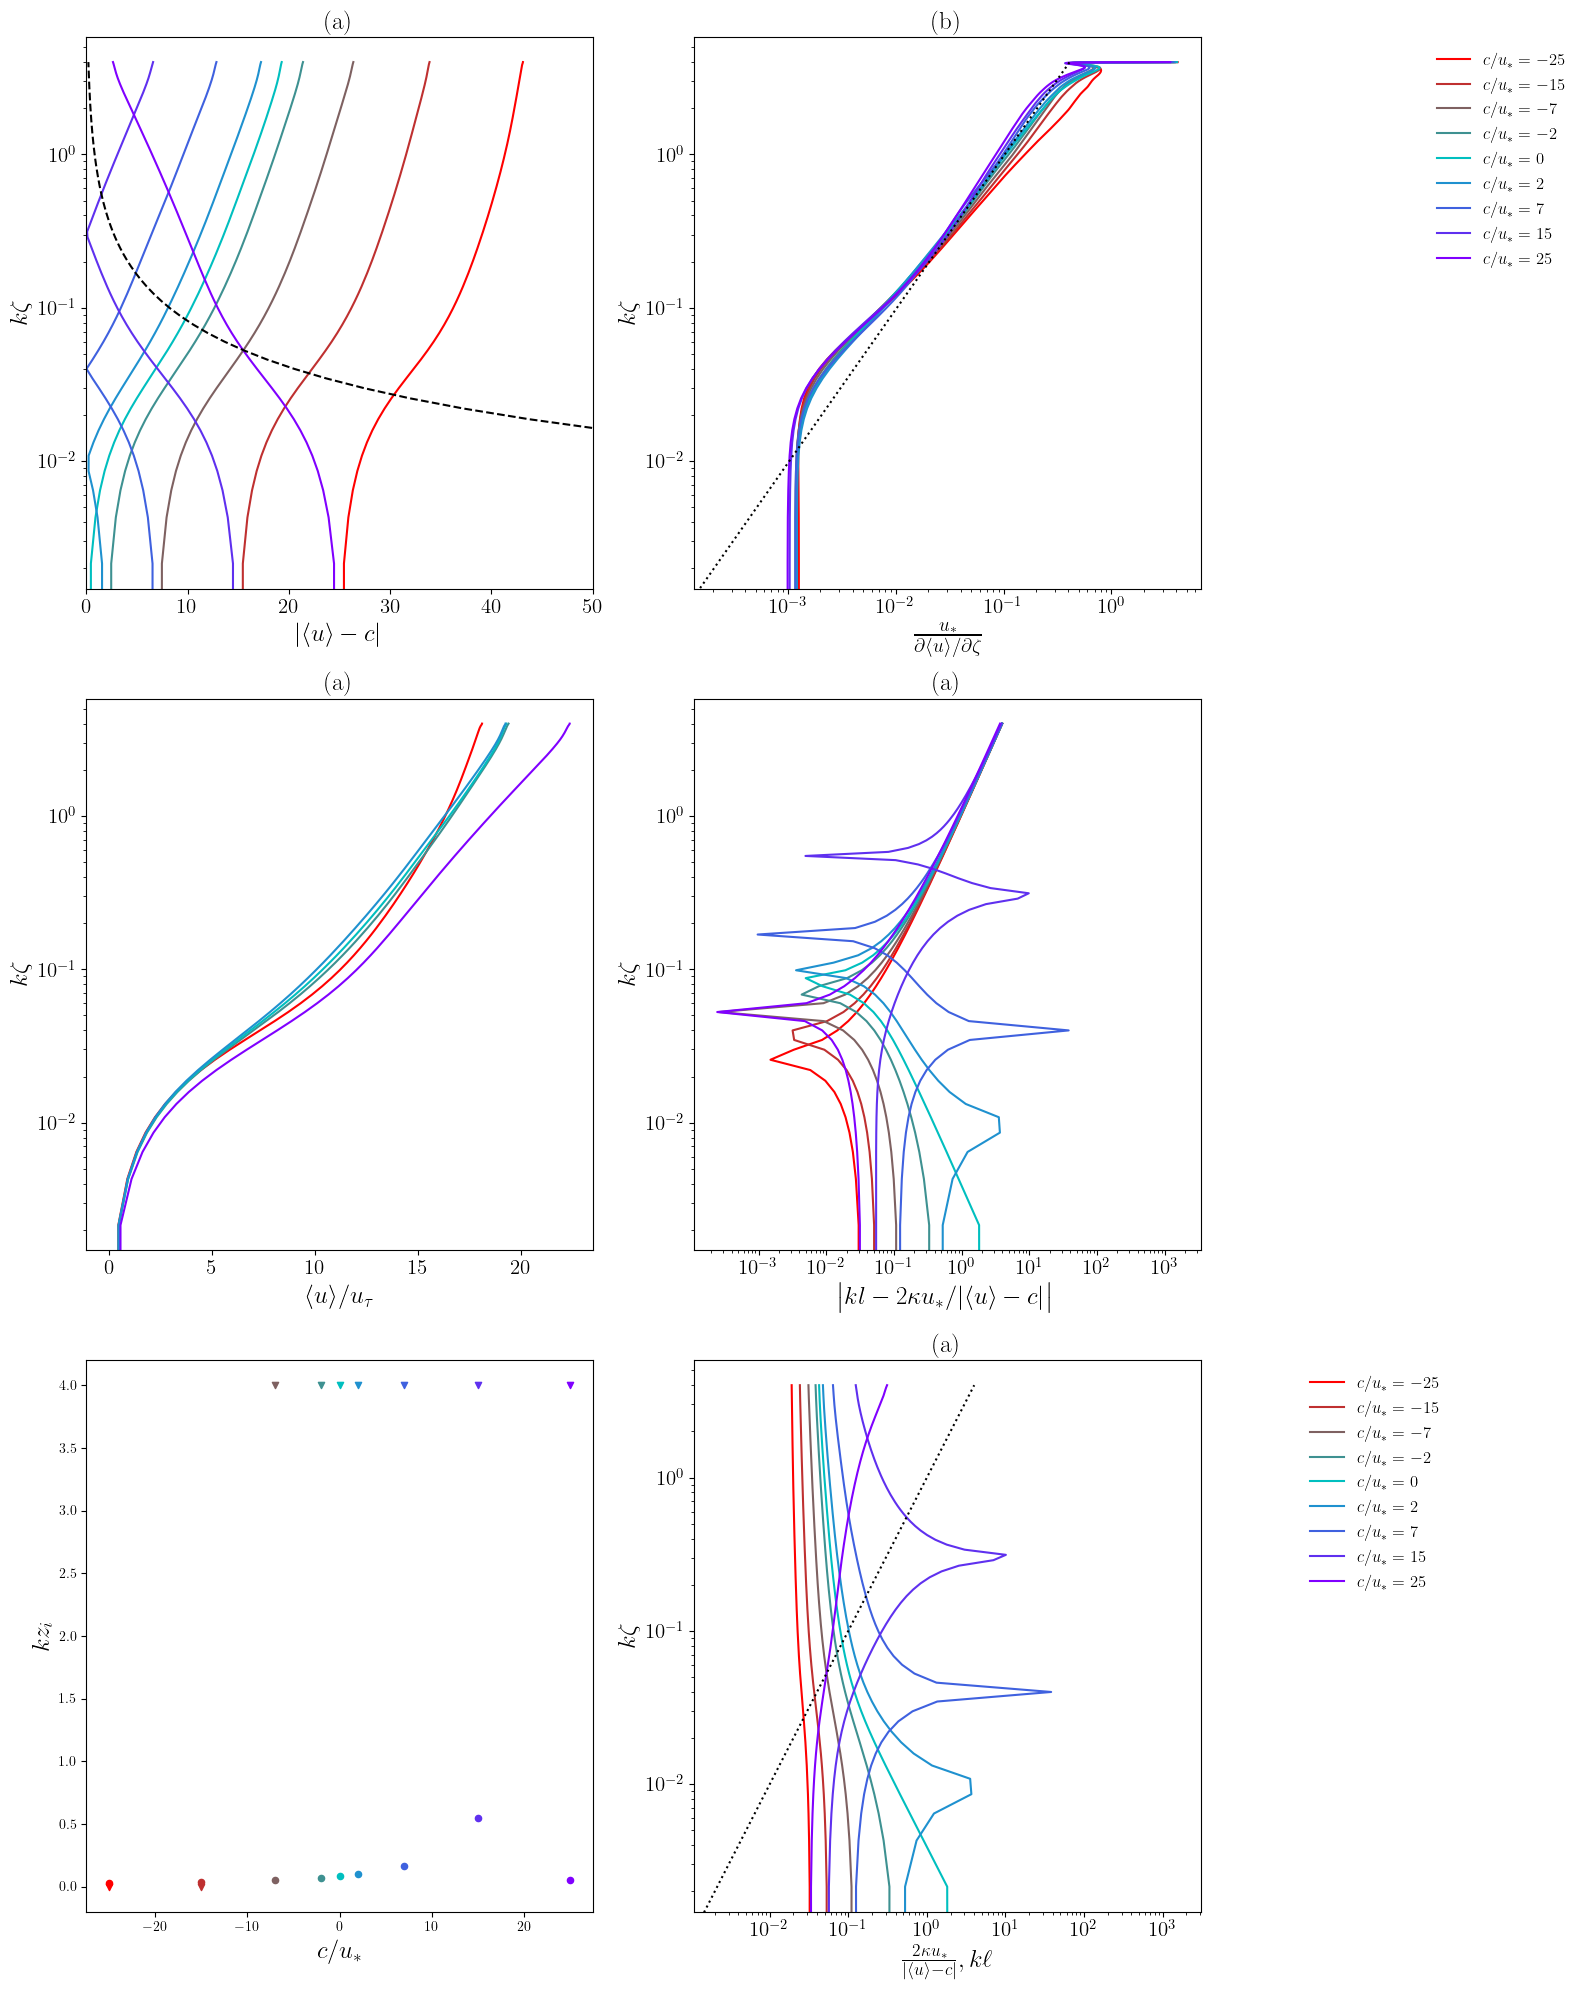

In [12]:
#Velocity plot
plt.figure(18,figsize=(16,20))
legend_name=['$c/u_*=-25$','$c/u_*=-15$','$c/u_*=-7$','$c/u_*=-2$','$c/u_*=0$','$c/u_*=2$','$c/u_*=7$','$c/u_*=15$','$c/u_*=25$']
ax1=plt.subplot(321)
for n in range(num_data-1):
#for n in range(5):
    z_data = np.asarray(LES_data[n].zw).flatten()
    u_data = np.asarray(LES_data[n].u_mean).flatten()
    U_data = np.asarray(LES_data[n].U_mean).flatten()
    
    ax1.semilogy(np.abs(u_data-c_array[n]),k_wavno*z_data,color=color_array[n])
    #ax1.semilogy(np.array([0, 50]),np.array([inner_layer_depth[n],inner_layer_depth[n]]),color=color_array[n])
ax1.semilogy(2*0.41/(k_wavno*z_data),k_wavno*z_data,'k--')
plt.xlim(0,50)
#ax1.legend(bbox_to_anchor=(1.2, 1))
ax1.set_title('(a)', fontsize=18)
ax1.set_ylabel(r'$k\zeta$',fontsize=18)
ax1.set_xlabel(r'$|\langle u \rangle-c|$',fontsize=18)
#ax1.set_xticks([0,.5,1.0])
#ax1.set_yticks([0.5,1])
#ax1.tick_params(labelsize=18)
#ax1.set_xlim(0.,1.2)
#ax1.set_ylim(0,1)
ax1.tick_params(labelsize=15)
ax1.legend(fontsize=18,frameon=False)

ax1=plt.subplot(322)
for n in range(num_data-1):
    z_data = np.asarray(LES_data[n].zw).flatten()
    u_data = np.asarray(LES_data[n].u_mean).flatten()
    U_data = np.asarray(LES_data[n].U_mean).flatten()
    dUdz_data=np.gradient(U_data,z_data,edge_order=2)
    #ax1.semilogy(dUdz_data*(kappa*z_data/ustar),k_wavno*z_data,color=color_array[n],label=legend_name[n])
    ax1.loglog(1/dUdz_data,k_wavno*z_data,color=color_array[n],label=legend_name[n])
ax1.loglog(0.41*z_data,k_wavno*z_data,'k:')
    
    
#ax1.legend(bbox_to_anchor=(1.2, 1))
ax1.set_title('(b)', fontsize=18)
ax1.set_ylabel(r'$k\zeta$',fontsize=18)

#ax1.set_xlabel(r'$\frac{\partial\langle u \rangle}{\partial \zeta}\frac{\kappa \zeta}{u_\tau}$',fontsize=20)
ax1.set_xlabel(r'$\frac{u_*}{\partial\langle u \rangle/\partial \zeta}$',fontsize=20)

#ax1.set_xticks([0,.5,1.0])
#ax1.set_yticks([0.5,1])
#ax1.tick_params(labelsize=18)
#ax1.set_xlim(0.,1.2)
#ax1.set_ylim(0,1)
ax1.tick_params(labelsize=15)
ax1.legend(bbox_to_anchor=(1.75, 1),fontsize=12,frameon=False)


ax1=plt.subplot(323)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    u_data = np.asarray(LES_data[n].u_mean).flatten()
    U_data = np.asarray(LES_data[n].U_mean).flatten()
    
    ax1.semilogy(u_data,k_wavno*z_data,color=limited_color_array[counter])
    counter=counter+1
#ax1.legend(bbox_to_anchor=(1.2, 1))
ax1.set_title('(a)', fontsize=18)
ax1.set_ylabel(r'$k\zeta$',fontsize=18)
ax1.set_xlabel(r'$\langle u \rangle/u_\tau$',fontsize=18)
#ax1.set_xticks([0,.5,1.0])
#ax1.set_yticks([0.5,1])
#ax1.tick_params(labelsize=18)
#ax1.set_xlim(0.,1.2)
#ax1.set_ylim(0,1)
ax1.tick_params(labelsize=15)
ax1.legend(fontsize=18,frameon=False)

ax1=plt.subplot(324)
counter=0
inner_layer_depth   = np.zeros((num_data,),dtype='float')
inner_layer_depth_2 = np.zeros((num_data,),dtype='float')
critical_layer_depth= np.zeros((num_data,),dtype='float')
outer_layer_depth   = np.zeros((num_data,),dtype='float')

for n in range(num_data-1):
    z_data = np.asarray(LES_data[n].zw).flatten()
    
    ax1.loglog(np.abs(k_wavno*z_data-2*0.41/(np.abs(np.asarray(LES_data[n].u_w_t_avg_mean).flatten()-c_array[n]))),k_wavno*z_data,color=color_array[counter])
    arr=np.abs(k_wavno*z_data-2*0.41/(np.abs(np.asarray(LES_data[n].u_w_t_avg_mean).flatten()-c_array[n])))
    min_index = np.argmin(arr)
    inner_layer_depth[n]=k_wavno*z_data[min_index]

    arr=np.abs(np.asarray(LES_data[n].u_w_t_avg_mean).flatten()-c_array[n])
    min_index = np.argmin(arr)
    critical_layer_depth[n]=k_wavno*z_data[min_index]

    arr=(ustar/0.41/np.asarray(LES_data[n].u_w_t_avg_mean).flatten())**(1/2)-k_wavno*z_data
    min_index = np.argmin(arr)
    outer_layer_depth[n]=k_wavno*z_data[min_index]

  
    counter=counter+1
#ax1.loglog(k_wavno*z_data,k_wavno*z_data,'k:')

#ax1.legend(bbox_to_anchor=(1.2, 1))
ax1.set_title('(a)', fontsize=18)
ax1.set_ylabel(r'$k\zeta$',fontsize=18)
ax1.set_xlabel(r'$\biggl|kl-2\kappa{u_*}/{|\langle u \rangle-c|}\biggr|$',fontsize=18)
#ax1.set_xticks([0,.5,1.0])
#ax1.set_yticks([0.5,1])
#ax1.tick_params(labelsize=18)
#ax1.set_xlim(0.,1.2)
#ax1.set_ylim(0,1)
ax1.tick_params(labelsize=15)
ax1.legend(fontsize=18,frameon=False)

ax1=plt.subplot(325)
for n in range(num_data-1):
    plt.scatter(c_array[n],inner_layer_depth[n],color=color_array[n],marker='o',s=20)
    plt.scatter(c_array[n],outer_layer_depth[n],color=color_array[n],marker='v',s=20)
ax1.set_xlabel(r'$c/u_*$',fontsize=18)
ax1.set_ylabel(r'$k z_i$',fontsize=18)


ax1=plt.subplot(326)
counter=0
z_array=np.linspace(1e-2,10,1000)
for n in range(num_data-1):
    z_data = np.asarray(LES_data[n].zw).flatten()
    ax1.loglog(2*kappa*1/np.abs(np.asarray(LES_data[n].u_w_t_avg_mean).flatten()-c_array[n]),k_wavno*z_data,color=color_array[counter],label=legend_name[n])
    counter=counter+1
ax1.semilogy(k_wavno*z_data,k_wavno*z_data,'k:')

#ax1.legend(bbox_to_anchor=(1.2, 1))
ax1.set_title('(a)', fontsize=18)
ax1.set_ylabel(r'$k\zeta$',fontsize=18)
ax1.set_xlabel(r'$\frac{2\kappa u_*}{|\langle u \rangle-c|},k\ell$',fontsize=18)
#ax1.set_xticks([0,.5,1.0])
#ax1.set_yticks([0.5,1])
#ax1.tick_params(labelsize=18)
#ax1.set_xlim(0.,1.2)
#ax1.set_ylim(0,1)
ax1.tick_params(labelsize=15)
ax1.legend(bbox_to_anchor=(1.5, 1),fontsize=12,frameon=False)

plt.savefig('U_dUdz_plot.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()

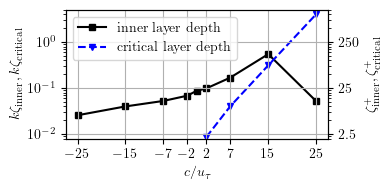

In [13]:
plt.figure(18, figsize=(4, 2))
font_size = 10
ax1 = plt.subplot(111)

# Line plots with markers
#plt.semilogy(c_array[0:-1], outer_layer_depth[0:-1], linestyle='--', color='k', 
#             label='outer layer depth', marker='o', markersize=5, zorder=1)

plt.semilogy(c_array[0:-1], inner_layer_depth[0:-1], linestyle='-', color='k', 
             label='inner layer depth', marker='s', markersize=5, zorder=1)
plt.semilogy(c_array[5:-1], critical_layer_depth[5:-1], linestyle='--', color='b', 
             label='critical layer depth', marker='v', markersize=5, zorder=1)

# Scatter plots with higher z-order to ensure they overlay the line plots
# for n in range(num_data - 1):
#     plt.scatter(c_array[n], inner_layer_depth[n], marker='s', color=color_array[n], 
#                 s=50, edgecolors='k', linewidth=0.5, zorder=2)
#     plt.scatter(c_array[n], critical_layer_depth[n], marker='v', color=color_array[n], 
#                 s=50, edgecolors='k', linewidth=0.5, zorder=2)

plt.yscale('log')
plt.xticks([-25, -15, -7, -2,  2, 7, 15, 25], fontsize=font_size)
plt.yticks([1e-2,1e-1,1],fontsize=font_size)

plt.legend(fontsize=font_size)
ax1.set_ylim(8e-3, 5)
plt.grid()

plt.xlabel(r'$c/u_\tau$', fontsize=font_size)
plt.ylabel(r'$k\zeta_{\mathrm{inner}},k\zeta_{\mathrm{critical}}$', fontsize=font_size)

# Create the twin Axes object for the right y-axis
ax2 = ax1.twinx()  # Share the x-axis

# Set the right y-axis limits (you can adjust these)
ax2.set_ylim(8e-3, 5)
ax2.set_yscale('log')
# Set the tick positions and labels for the right y-axis
ax2.set_yticks([1e-2,1e-1,1])
ax2.set_yticklabels([r'$2.5$', r'$25$', r'$250$'], fontsize=font_size)
ax2.set_ylabel(r'$\zeta_{\mathrm{inner}}^+,\zeta_{\mathrm{critical}}^+$', rotation=90, labelpad=4, fontsize=font_size)

# Save figure
plt.savefig('inner_critical_depth.png', format='png', dpi=600, bbox_inches='tight',
            transparent=False, pad_inches=0.01)

plt.show()


/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2157605838.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=font_size,frameon=False)
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2157605838.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=font_size,frameon=False)
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2157605838.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=font_size,frameon=False)
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2157605838.py:74: UserWarning: No a

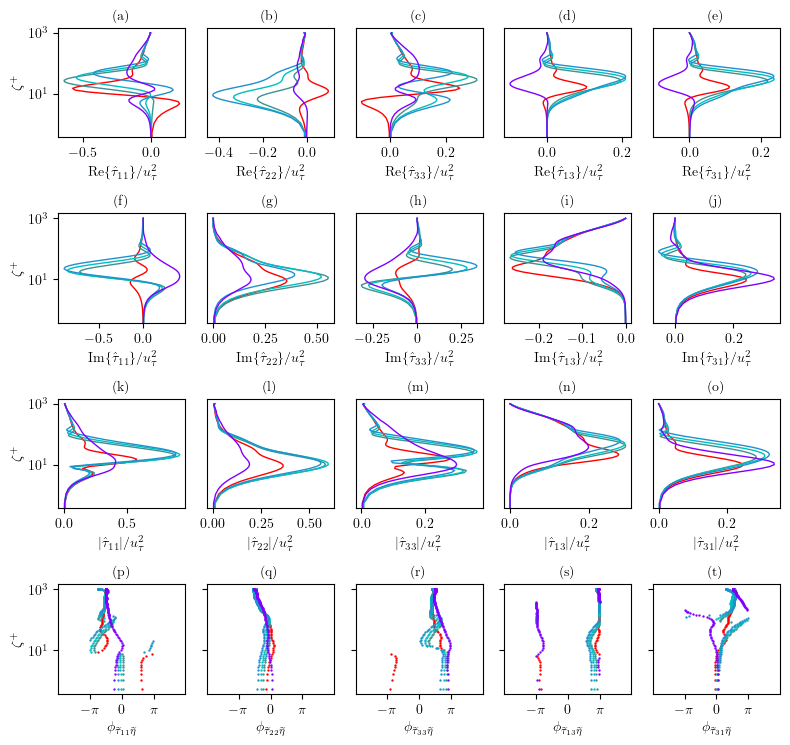

In [14]:
#Wave-induced stress plot
plt.figure(18,figsize=(8,9))

font_size=10;
ax1=plt.subplot(551)
counter=0;
for n in limited_c_array_index:#[1,2,4,6,7]:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau11_hat_LES = np.fft.fft(LES_data[n].tau11+LES_data[n].tau11_SGS,axis=0,norm='forward')  
    tau11_hat_LES = np.fft.fft(LES_data[n].tau11_d+LES_data[n].tau11_d_SGS,axis=0,norm='forward')  
    
    ax1.semilogy(tau11_hat_LES[16,:].real,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
#ax1.text(0.85, 0.125, '(a)', transform=ax1.transAxes, fontsize=font_size, 
#         verticalalignment='top', horizontalalignment='left')
ax1.set_title('(a)', fontsize=font_size, loc='center')
ax1.set_ylabel(r'$\zeta^+$',fontsize=font_size)
ax1.set_xlabel(r'Re$\{\hat{\tau}_{11}\}/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,6)
counter=0;
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau11_hat_LES = np.fft.fft(LES_data[n].tau11+LES_data[n].tau11_SGS,axis=0,norm='forward')  
    tau11_hat_LES = np.fft.fft(LES_data[n].tau11_d+LES_data[n].tau11_d_SGS,axis=0,norm='forward')  
    
    ax1.semilogy(tau11_hat_LES[16,:].imag,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)
    counter=counter+1
    ax1.set_ylabel(r'$\zeta^+$',fontsize=font_size)
ax1.set_title('(f)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'Im$\{\hat{\tau}_{11}\}/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,11)
counter=0;
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau11_hat_LES = np.fft.fft(LES_data[n].tau11+LES_data[n].tau11_SGS,axis=0,norm='forward')  
    tau11_hat_LES = np.fft.fft(LES_data[n].tau11_d+LES_data[n].tau11_d_SGS,axis=0,norm='forward')  
    
    ax1.semilogy(np.abs(tau11_hat_LES[16,:]),k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)
    counter=counter+1
    ax1.set_ylabel(r'$\zeta^+$',fontsize=font_size)
ax1.set_title('(k)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'$|\hat{\tau}_{11}|/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,16)
counter=0
ax1.tick_params(labelsize=font_size)
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau11_hat_LES = np.fft.fft(LES_data[n].tau11_d+LES_data[n].tau11_d_SGS,axis=0,norm='forward')    
    #ax1.semilogy( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2]))*180/np.pi,k_wavno*z_data[0:-2],color=limited_color_array[counter],marker='o',markerfacecolor='none',linestyle='none')
    ax1.scatter( np.arctan2(np.real(tau11_hat_LES[16,0:-2]), np.imag(tau11_hat_LES[16,0:-2])),k_wavno**0*z_data[0:-2]*Retau,color=limited_color_array[counter],marker='o',s=0.5)
 
    counter=counter+1
plt.yscale('log')

ax1.set_title('(p)', fontsize=font_size, loc='center')
ax1.set_ylabel(r'$\zeta^+$',fontsize=font_size)
ax1.set_xlabel(r'$\phi_{\widetilde{\tau}_{11}\widetilde{\eta}}$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
tick_locations = np.radians([-180,0,180])
tick_labels = [r'$-\pi$',r'$0$',  r'$\pi$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks(tick_locations)
ax1.legend(fontsize=font_size,frameon=False)

########################################################################################################################################################
#tau22
ax1=plt.subplot(5,5,5-3)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau22_hat_LES = np.fft.fft(LES_data[n].tau22+LES_data[n].tau22_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau22_hat_LES[16,:].real,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(b)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'Re$\{\hat{\tau}_{22}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,10-3)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau22_hat_LES = np.fft.fft(LES_data[n].tau22+LES_data[n].tau22_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau22_hat_LES[16,:].imag,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(g)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'Im$\{\hat{\tau}_{22}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,15-3)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau22_hat_LES = np.fft.fft(LES_data[n].tau22+LES_data[n].tau22_SGS,axis=0,norm='forward')    
    ax1.semilogy(np.abs(tau22_hat_LES[16,:]),k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(l)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$|\hat{\tau}_{22}|/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,20-3)
counter=0
ax1.tick_params(labelsize=font_size)
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau22_hat_LES = np.fft.fft(LES_data[n].tau22+LES_data[n].tau22_SGS,axis=0,norm='forward')    
    #ax1.semilogy( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2]))*180/np.pi,k_wavno*z_data[0:-2],color=limited_color_array[counter],marker='o',markerfacecolor='none',linestyle='none')
    c_value=c_array[n]
    ax1.scatter( np.arctan2(np.real(tau22_hat_LES[16,0:-2]), np.imag(tau22_hat_LES[16,0:-2])),k_wavno**0*z_data[0:-2]*Retau,color=limited_color_array[counter],marker='o',s=0.5,label=r'$c^+=%0.0f$' % c_value)
 
    counter=counter+1
plt.yscale('log')

ax1.set_title('(q)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$\phi_{\widetilde{\tau}_{22}\widetilde{\eta}}$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
#plt.legend(fontsize=2)
tick_locations = np.radians([-180,0,180])
tick_labels = [r'$-\pi$',r'$0$',  r'$\pi$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks(tick_locations)
ax1.set_yticklabels('')

#########################################################################################################################################################################################################################
#tau33
ax1=plt.subplot(5,5,2+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau33_hat_LES = np.fft.fft(LES_data[n].tau33+LES_data[n].tau33_SGS,axis=0,norm='forward')    
    tau33_hat_LES = np.fft.fft(LES_data[n].tau33_d+LES_data[n].tau33_d_SGS,axis=0,norm='forward')    
    
    ax1.semilogy(tau33_hat_LES[16,:].real,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(c)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'Re$\{\hat{\tau}_{33}\}/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.set_yticks([])
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,7+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau33_hat_LES = np.fft.fft(LES_data[n].tau33+LES_data[n].tau33_SGS,axis=0,norm='forward')    
    tau33_hat_LES = np.fft.fft(LES_data[n].tau33_d+LES_data[n].tau33_d_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau33_hat_LES[16,:].imag,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)

    counter=counter+1
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_title('(h)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'Im$\{\hat{\tau}_{33}\}/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.set_yticks([])
tick_locations = np.array([-0.25,0,0.25])
tick_labels = [r'$-0.25$', r'$0$', r'$0.25$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)  # Adjust fontsize as necessary
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,12+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    #tau33_hat_LES = np.fft.fft(LES_data[n].tau33+LES_data[n].tau33_SGS,axis=0,norm='forward')    
    tau33_hat_LES = np.fft.fft(LES_data[n].tau33_d+LES_data[n].tau33_d_SGS,axis=0,norm='forward')    
    ax1.semilogy(np.abs(tau33_hat_LES[16,:]),k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)

    counter=counter+1
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_title('(m)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'$|\hat{\tau}_{33}|/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.set_yticks([])
ax1.legend(fontsize=font_size,frameon=False)



ax1=plt.subplot(5,5,17+1)
counter=0
ax1.tick_params(labelsize=font_size)
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau33_hat_LES = np.fft.fft(LES_data[n].tau33_d+LES_data[n].tau33_d_SGS,axis=0,norm='forward')    
    #ax1.semilogy( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2]))*180/np.pi,k_wavno*z_data[0:-2],color=limited_color_array[counter],marker='o',markerfacecolor='none',linestyle='none')
    ax1.scatter( np.arctan2(np.real(tau33_hat_LES[16,0:-2]), np.imag(tau33_hat_LES[16,0:-2])),k_wavno**0*z_data[0:-2]*Retau,color=limited_color_array[counter],marker='o',s=0.5)
 
    counter=counter+1
plt.yscale('log')

ax1.set_title('(r)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$\phi_{\widetilde{\tau}_{33}\widetilde{\eta}}$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
tick_locations = np.radians([-180,0,180])
tick_labels = [r'$-\pi$',r'$0$',  r'$\pi$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks(tick_locations)
ax1.set_yticklabels('')
ax1.legend(fontsize=font_size,frameon=False)


########################################################################################################################################################

ax1=plt.subplot(5,5,3+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau13_hat_LES = np.fft.fft(LES_data[n].tau13+LES_data[n].tau13_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau13_hat_LES[16,:].real,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(d)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'Re$\{\hat{\tau}_{13}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,8+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau13_hat_LES = np.fft.fft(LES_data[n].tau13+LES_data[n].tau13_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau13_hat_LES[16,:].imag,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)

    counter=counter+1
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_title('(i)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'Im$\{\hat{\tau}_{13}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,13+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau13_hat_LES = np.fft.fft(LES_data[n].tau13+LES_data[n].tau13_SGS,axis=0,norm='forward')    
    ax1.semilogy(np.abs(tau13_hat_LES[16,:]),k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)
    counter=counter+1
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_title('(n)', fontsize=font_size, loc='center')
ax1.set_yticks([])
ax1.set_xlabel(r'$|\hat{\tau}_{13}|/u_\tau^2$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,18+1)
counter=0
ax1.tick_params(labelsize=font_size)
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau13_hat_LES = np.fft.fft(LES_data[n].tau13+LES_data[n].tau13_SGS,axis=0,norm='forward')    
    #ax1.semilogy( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2]))*180/np.pi,k_wavno*z_data[0:-2],color=limited_color_array[counter],marker='o',markerfacecolor='none',linestyle='none')
    ax1.scatter( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2])),k_wavno**0*z_data[0:-2]*Retau,color=limited_color_array[counter],marker='o',s=0.5)
 
    counter=counter+1
plt.yscale('log')

ax1.set_title('(s)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$\phi_{\widetilde{\tau}_{13}\widetilde{\eta}}$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
tick_locations = np.radians([-180,0,180])
tick_labels = [r'$-\pi$',r'$0$',  r'$\pi$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks(tick_locations)
ax1.set_yticklabels('')
ax1.legend(fontsize=font_size,frameon=False)

########################################################################################################################################################


ax1=plt.subplot(5,5,4+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau31_hat_LES = np.fft.fft(LES_data[n].tau31+LES_data[n].tau31_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau31_hat_LES[16,:].real,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(e)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'Re$\{\hat{\tau}_{31}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)

ax1=plt.subplot(5,5,9+1)
counter=0;
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau31_hat_LES = np.fft.fft(LES_data[n].tau31+LES_data[n].tau31_SGS,axis=0,norm='forward')    
    ax1.semilogy(tau31_hat_LES[16,:].imag,k_wavno**0*z_data*Retau,color=limited_color_array[counter],linestyle='-',linewidth=1)
    counter=counter+1;
#ax1.set_ylabel(r'$\zeta$',fontsize=font_size)
ax1.set_title('(j)', fontsize=font_size, loc='center')
ax1.set_xlabel(r'Im$\{\hat{\tau}_{31}\}/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)


ax1=plt.subplot(5,5,14+1)
counter=0
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau31_hat_LES = np.fft.fft(LES_data[n].tau31+LES_data[n].tau31_SGS,axis=0,norm='forward')    
    ax1.semilogy(np.abs(tau31_hat_LES[16,:]),k_wavno**0*z_data*Retau,color=limited_color_array[counter],linewidth=1)
    counter=counter+1
ax1.set_title('(o)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$|\hat{\tau}_{31}|/u_\tau^2$',fontsize=font_size)
ax1.set_yticks([])
ax1.tick_params(labelsize=font_size)
ax1.legend(fontsize=font_size,frameon=False)


ax1=plt.subplot(5,5,19+1)
counter=0
ax1.tick_params(labelsize=font_size)
for n in limited_c_array_index:
    z_data = np.asarray(LES_data[n].zw).flatten()
    tau31_hat_LES = np.fft.fft(LES_data[n].tau31+LES_data[n].tau31_SGS,axis=0,norm='forward')    
    #ax1.semilogy( np.arctan2(np.real(tau13_hat_LES[16,0:-2]), np.imag(tau13_hat_LES[16,0:-2]))*180/np.pi,k_wavno*z_data[0:-2],color=limited_color_array[counter],marker='o',markerfacecolor='none',linestyle='none')
    c_value=c_array[n]
    ax1.scatter( np.arctan2(np.real(tau31_hat_LES[16,0:-2]), np.imag(tau31_hat_LES[16,0:-2])),k_wavno**0*z_data[0:-2]*Retau,color=limited_color_array[counter],marker='o',s=0.5,label=r'$c^+=%0.0f$' % c_value)
 
    counter=counter+1
plt.yscale('log')

ax1.set_title('(t)', fontsize=font_size, loc='center')
#ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_xlabel(r'$\phi_{\widetilde{\tau}_{31}\widetilde{\eta}}$',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
#plt.legend(fontsize=2)
tick_locations = np.radians([-180,0,180])
tick_labels = [r'$-\pi$',r'$0$',  r'$\pi$']
ax1.set_xticks(tick_locations)
ax1.set_xticklabels(tick_labels, fontsize=font_size)
ax1.set_xlim(-2*np.pi,2*np.pi)
ax1.set_xticks(tick_locations)
ax1.set_yticklabels('')
#ax1.legend(fontsize=font_size,frameon=False)


########################################################################################################################################################

plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.08, right=0.98)
plt.savefig('tau_ij_plot_LES_phase_mag_limited_enlarged.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)


plt.show()

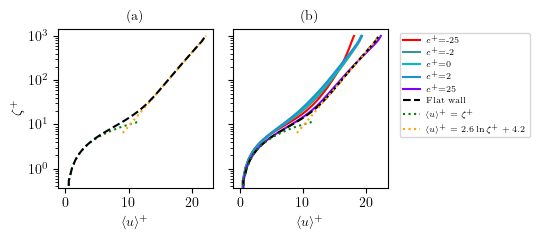

In [17]:
#Mean velocity plot
plt.figure(18,figsize=(5.5,2.5))
font_size=10
ax1=plt.subplot(1,2,1)
num_data_select=0
plt.semilogy(LES_data[num_data_select].zw[0:15]*Retau,LES_data[num_data_select].zw[0:15]*Retau,'g',linestyle=':',label=r'$\langle u\rangle^+=\zeta^+$')
plt.semilogy(2.6*np.log(LES_data[num_data_select].zw[10:]*Retau)+4.2,LES_data[num_data_select].zw[10:]*Retau,color='orange',linestyle=':',label=r'$\langle u\rangle^+=2.6\ln\zeta^+ + 4.2$')
plt.semilogy(LES_data[9].u_mean,LES_data[num_data_select].zw*Retau,'k',linestyle='--',label='Flat wall')

#plt.legend(fontsize=6)
ax1.set_title('(a)',fontsize=font_size)
plt.ylabel(r'$\zeta^+$',fontsize=font_size)
plt.xlabel(r'$\langle u \rangle^+$',fontsize=font_size)
#plt.grid()
ax1=plt.subplot(1,2,2)

for num_data_select in [0,3,4,5,8,9]:
    upup = LES_data[num_data_select].upup_phase_avg 
    upup_mean = np.mean(upup,axis=0)
    if num_data_select<9:
       plt.plot(LES_data[num_data_select].u_mean,LES_data[num_data_select].zw*Retau,color=color_array[num_data_select],label=f'$c^+$={c_array[num_data_select]}')

    else:
       plt.plot(LES_data[9].u_mean,LES_data[num_data_select].zw*Retau,'k',linestyle='--',label='Flat wall')
plt.semilogy(LES_data[num_data_select].zw[0:15]*Retau,LES_data[num_data_select].zw[0:15]*Retau,'g',linestyle=':',label=r'$\langle u\rangle^+=\zeta^+$')
plt.semilogy(2.6*np.log(LES_data[num_data_select].zw[10:]*Retau)+4.2,LES_data[num_data_select].zw[10:]*Retau,color='orange',linestyle=':',label=r'$\langle u\rangle^+=2.6\ln\zeta^+ + 4.2$')
plt.yscale('log')
#plt.xlim(10,22)
#plt.legend(fontsize=5)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=6)
ax1.tick_params(labelsize=font_size, labelleft=False)
ax1.set_title('(b)',fontsize=font_size)
#ax1.set_xlim(-1,20)
#plt.ylabel(r'$\zeta^+$',fontsize=font_size)
plt.xlabel(r'$\langle u \rangle^+$',fontsize=font_size)
#plt.grid()
plt.savefig('mean_velocity_profiles.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

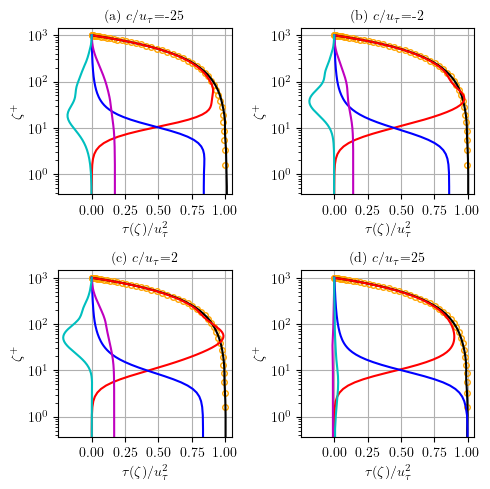

In [18]:
#Mean momentum balance
plt.figure(18,figsize=(5.0,5.0))
counter=1
font_size=10
for num_data_select in [0,3,5,8]:
    ax1=plt.subplot(2,2,counter)
    plt.semilogy(1-LES_data[num_data_select].zw[0:-1:3],k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw[0:-1:3],color='orange',linestyle='none',marker='o',markersize=4,markerfacecolor='none')
    
    plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*1+LES_data[num_data_select].taup_13_mean*1+LES_data[num_data_select].tau13_mean*1+LES_data[num_data_select].tau13_wave_mean*1+1*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='k',linestyle='-')#tau_tot
    plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*0+LES_data[num_data_select].taup_13_mean*0+LES_data[num_data_select].tau13_mean*1+LES_data[num_data_select].tau13_wave_mean*0+1*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='r',linestyle='-')#tau_turb
    #plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*0+LES_data[num_data_select].taup_13_mean*0+LES_data[num_data_select].tau13_mean*0+LES_data[num_data_select].tau13_wave_mean*0+1*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='g',linestyle='-')#tau_SGS
    plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*1+LES_data[num_data_select].taup_13_mean*0+LES_data[num_data_select].tau13_mean*0+LES_data[num_data_select].tau13_wave_mean*0+0*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='b',linestyle='-')#tau_visc
    plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*0+LES_data[num_data_select].taup_13_mean*1+LES_data[num_data_select].tau13_mean*0+LES_data[num_data_select].tau13_wave_mean*0+0*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='m',linestyle='-')#tau_p
    plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*0+LES_data[num_data_select].taup_13_mean*0+LES_data[num_data_select].tau13_mean*0+LES_data[num_data_select].tau13_wave_mean*1+0*LES_data[num_data_select].tau13_SGS_mean),k_wavno**0*(ustar/nu)*LES_data[num_data_select].zw,color='c',linestyle='-')#tau_wave
    #plt.semilogy(-(LES_data[num_data_select].tau13_nu_mean*0+LES_data[num_data_select].taup_13_mean*1+LES_data[num_data_select].tau13_mean*0+LES_data[num_data_select].tau13_wave_mean*1+0*LES_data[num_data_select].tau13_SGS_mean),k_wavno*LES_data[num_data_select].zw,color='c',linestyle='--')#tau_wave
    ax1.set_xlabel(r'$\tau(\zeta)/u_\tau^2$',fontsize=font_size)
    ax1.set_title(f'({chr(97 + counter-1)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    ax1.set_ylabel(r'$\zeta^+$',fontsize=font_size)
    ax1.tick_params(labelsize=font_size)
    plt.xlim(-0.25,1.05)
    plt.xticks([0,0.25,0.5,0.75,1])
    #plt.ylim(1e-3,5)
    #plt.yticks([1e-3,1e-2,1e-1,1,5])
    plt.grid()
    counter+=1
plt.savefig('stress_balance_2x2.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

In [19]:
select_all_model=0
if select_all_model==1:
        n_num_array_index  =[0,1,2,3,4]
        color_array_plot   =['b-','r--','y-.','y:','b--','m--'];
        color_array_plot_Re=['b-','r--','y-.','y:','b--','m--'];
        color_array_plot_Im=['b-','r--','y-.','y:','b--','m--'];
else:
        n_num_array_index  =[0,1]
        color_array_plot   =['b-','r--','g-.','m:','c--'];
        color_array_plot_Re=['b-','r--','g-.','m:','c--'];
        color_array_plot_Im=['b-','r--','g-.','m:','c--'];

\begin{align}
\nu_T=c_1\kappa\zeta\left(1-\exp\left[-\frac{\zeta}{H}\frac{Re_\tau}{25}\right]\right)\left(1-\frac{\zeta}{H}\right)^{c_2}
\end{align}

/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/1881958091.py:35: UserWarning: Ignoring specified arguments in this call because figure with num: 11 already exists
  plt.figure(11,figsize=(8,4))


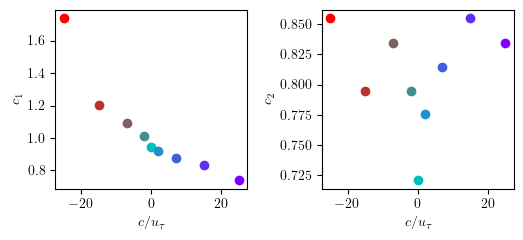

In [20]:
#Finding fitting constants c_1 and c_2
plt.figure(11,figsize=(8,2.5))

c1_fit = np.logspace(np.log10(0.001),np.log10(200),500);
c2_fit = np.logspace(np.log10(0.001),np.log10(200),500);
[C1_FIT,C2_FIT]=np.meshgrid(c1_fit,c2_fit)
c_error = np.zeros((np.size(c1_fit),np.size(c2_fit),num_data-1),dtype=float)
c1_fit_const = np.zeros((num_data-1,),dtype=float)
c2_fit_const = np.zeros((num_data-1,),dtype=float)
for num_data_select in range(num_data-1):
    z_data = LES_data[num_data_select].zw.flatten()
    U_data = LES_data[num_data_select].u_mean.flatten()
    U_prime_LES = np.gradient(U_data[0:-1],z_data[0:-1],edge_order=2)
    tau13  = LES_data[num_data_select].tau13_mean + LES_data[num_data_select].tau31_SGS_mean
    nuT_LES    = -tau13[0:-1]/U_prime_LES
    
    counter1=0
    for const1 in c1_fit:
        counter2=0
        for const2 in c2_fit:
            nuT_model  =  const1*0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25/zi))*(1-z_data[0:-1]/zi)**(const2)
            
            c_error[counter1,counter2,num_data_select] = np.mean(np.abs(nuT_LES-nuT_model))#mape(nuT_LES, nuT_model)
            counter2+=1
        counter1+=1
    # Get the index of the minimum value
    min_index_flat = np.argmin(c_error[:,:,num_data_select])  # Flattened index
    
    # Convert to (row, col) index
    min_index = np.unravel_index(min_index_flat, c_error[:,:,num_data_select].shape)    
    c1_fit_const[num_data_select] = C1_FIT[min_index[1],min_index[0]] 
    c2_fit_const[num_data_select] = C2_FIT[min_index[1],min_index[0]]


plt.figure(11,figsize=(8,4))
ax1=plt.subplot(1,3,1)
for num_data_select in range(num_data-1):
    #plt.loglog(c_fit,c_error[:,num_data_select],color=color_array[num_data_select])
    plt.scatter(c_array[num_data_select],c1_fit_const[num_data_select],color=color_array[num_data_select]) 
plt.xlabel(r'$c/u_\tau$')
plt.ylabel(r'$c_1$')

ax1=plt.subplot(1,3,2)
for num_data_select in range(num_data-1):
    plt.scatter(c_array[num_data_select],c2_fit_const[num_data_select],color=color_array[num_data_select]) 
plt.xlabel(r'$c/u_\tau$')
plt.ylabel(r'$c_2$')

plt.show()

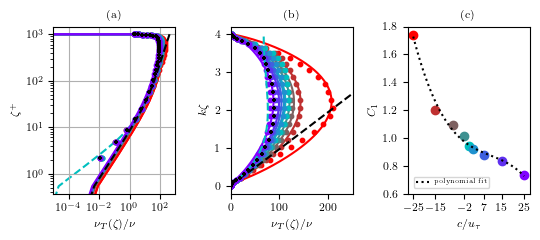

In [21]:
#Mean flow-based eddy viscosity
plt.figure(11,figsize=(5.5,2.5))
font_size=8
c2_const = 0.8# np.mean(c2_fit_const)
ax1=plt.subplot(1,3,1)
plt.tick_params(axis='both', labelsize=font_size) 
for num_data_select in range(9):
    z_data = LES_data[num_data_select].zw.flatten()
    U_data = LES_data[num_data_select].u_mean.flatten()
    U_prime_LES = np.gradient(U_data[0:-1],z_data[0:-1],edge_order=2)
    tau13  = LES_data[num_data_select].tau13_mean + LES_data[num_data_select].tau31_SGS_mean
    nuT_LES    = -tau13[0:-1]/U_prime_LES

    nuT_model  =  c1_fit_const[num_data_select]*0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))*(1-z_data[0:-1])**(c2_const)
    #nuT_model  =  0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))*np.exp(-c_fit_const[num_data_select]*z_data[0:-1])
    plt.scatter(nuT_LES[0:Nz:4]/nu, (ustar/nu) * z_data[0:Nz:4], marker='o',s=10,color=color_array[num_data_select],label=fr'$c/u_\tau={c_array[num_data_select]}$',zorder=2)
    plt.semilogy(nuT_model/nu,(ustar/nu) * z_data[0:-1],color=color_array[num_data_select],zorder=2)
       

plt.semilogy(0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))/nu,(ustar/nu)*z_data[0:-1],'k--',label=r'$\nu_{T,\mathrm{I}}$')
eta_Cess = z_data[0:-1]-1
    
nuT_linear_3        = (nu/2)*(1+(0.41**2*Retau**2/9)*(1-eta_Cess**2)**2*(1+2*eta_Cess**2)**2
                                *(1-np.exp((np.abs(eta_Cess)-1)*Retau/25))**2)**(1/2)-nu/2



num_data_select = 0
nuT_model  =  c1_fit_const[num_data_select]*0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))*(1-z_data[0:-1])**(c2_fit_const[num_data_select])
plt.semilogy(nuT_model/nu,(ustar/nu)*z_data[0:-1],'r-',label=r'$\nu_{T,\mathrm{II}}$',zorder=1)

plt.semilogy(nuT_linear_3/nu,(ustar/nu)*z_data[0:-1],'c--',label=r'$\nu_{T,\mathrm{III}}$',zorder=1)
#Flat wall
z_data = LES_data[9].zw.flatten()
U_data = LES_data[9].u_mean.flatten()
U_prime_LES = np.gradient(U_data[0:-1],z_data[0:-1],edge_order=2)
tau13  = LES_data[9].tau13_mean + LES_data[9].tau31_SGS_mean
nuT_LES    = -tau13[0:-1]/U_prime_LES
plt.scatter(nuT_LES[0:Nz:4]/nu, (ustar/nu) * z_data[0:Nz:4], marker='+',s=10,color='k',label=fr'Flat wall',zorder=2)

plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-5,1e3)
plt.xticks([1e-4,1e-2,1,100])

#plt.xlabel(r'$\nu_T(\zeta)=\frac{\langle\tau_{13}\rangle}{(\partial\langle u\rangle/\partial\zeta)}$',fontsize=font_size)    
plt.xlabel(r'$\nu_T(\zeta)/\nu$',fontsize=font_size)    
plt.ylabel(r'$\zeta^+$',fontsize=font_size) 
#plt.legend(bbox_to_anchor=(0.01, 0.65), loc='center left', borderaxespad=1.,fontsize=3.7)
ax1.set_title('(a)',fontsize=font_size)
plt.grid()

ax1=plt.subplot(1,3,2)
plt.tick_params(axis='both', labelsize=font_size) 
for num_data_select in range(9):
    z_data = LES_data[num_data_select].zw.flatten()
    U_data = LES_data[num_data_select].u_mean.flatten()
    U_prime_LES = np.gradient(U_data[0:-1],z_data[0:-1],edge_order=2)
    tau13  = LES_data[num_data_select].tau13_mean + LES_data[num_data_select].tau31_SGS_mean
    nuT_LES    = -tau13[0:-1]/U_prime_LES

    nuT_model  =  c1_fit_const[num_data_select]*0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))*(1-z_data[0:-1])**(c2_const)
    #nuT_model  =  0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))*np.exp(-c_fit_const[num_data_select]*z_data[0:-1])
    
    plt.scatter(nuT_LES[0:Nz:4]/nu, k_wavno * z_data[0:Nz:4], marker='o',s=10,color=color_array[num_data_select],label=fr'$c/u_\tau={c_array[num_data_select]}$',zorder=1)
    plt.plot(nuT_model/nu,k_wavno*z_data[0:-1],color=color_array[num_data_select],zorder=1)

eta_Cess = z_data[0:-1]-1
    
nuT_linear_3        = (nu/2)*(1+(0.41**2*Retau**2/9)*(1-eta_Cess**2)**2*(1+2*eta_Cess**2)**2
                                *(1-np.exp((np.abs(eta_Cess)-1)*Retau/25))**2)**(1/2)-nu/2

plt.semilogy(0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*1000/25))/nu,k_wavno*z_data[0:-1],'k--',label=r'$\nu_{T,\mathrm{I}}$',zorder=1)
plt.semilogy(nuT_linear_3/nu,k_wavno*z_data[0:-1],'c--',label=r'$\nu_{T,\mathrm{III}}$',zorder=1)
plt.yscale('linear')

#Flat wall
z_data = LES_data[9].zw.flatten()
U_data = LES_data[9].u_mean.flatten()
U_prime_LES = np.gradient(U_data[0:-1],z_data[0:-1],edge_order=2)
tau13  = LES_data[9].tau13_mean + LES_data[9].tau31_SGS_mean
nuT_LES    = -tau13[0:-1]/U_prime_LES
plt.scatter(nuT_LES[0:Nz:4]/nu, k_wavno* z_data[0:Nz:4], marker='+',s=10,color='k',label=fr'Flat wall',zorder=1)

#plt.legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=1.,fontsize=8)
#plt.xlabel(r'$\nu_T(\zeta)=\frac{\langle\tau_{13}\rangle}{(\partial\langle u\rangle/\partial\zeta)}$',fontsize=font_size)    
plt.xlabel(r'$\nu_T(\zeta)/\nu$',fontsize=font_size)    
plt.ylabel(r'$k\zeta$',fontsize=font_size) 
ax1.set_xlim(0,250)
plt.xticks([0,100,200])
ax1.set_title('(b)',fontsize=font_size)


ax1=plt.subplot(1,3,3)
plt.tick_params(axis='both', labelsize=font_size) 
for num_data_select in range(num_data-1):
    plt.scatter(c_array[num_data_select],c1_fit_const[num_data_select],color=color_array[num_data_select]) 

degree = 3
coeffs = np.polyfit(c_array[0:-1], c1_fit_const[0:9], degree)
coeffs = np.round(coeffs,6)
poly_func = np.poly1d(coeffs)
c_array_fit=np.linspace(-25,25,100)
plt.plot(c_array_fit,poly_func(c_array_fit),'k',linestyle=':',label='polynomial fit')
plt.legend(loc='lower left', borderaxespad=1.,fontsize=4.5)
plt.xticks([-25,-15,-2,7,15,25])
ax1.set_ylim(0.6,1.8)
plt.yticks(np.linspace(0.6,1.8,7))

plt.ylabel(r'$C_1$',fontsize=font_size)
plt.xlabel(r'$c/u_\tau$',fontsize=font_size)
ax1.set_title('(c)',fontsize=font_size)

# ax1=plt.subplot(2,2,4)
# plt.tick_params(axis='both', labelsize=font_size) 
# for num_data_select in range(num_data-1):
#     plt.scatter(c_array[num_data_select],c2_fit_const[num_data_select],color=color_array[num_data_select]) 
# plt.xticks([-25,-15,-7,-2,2,7,15,25])
# plt.xlabel(r'$c_2$',fontsize=font_size)
# plt.ylabel(r'$k\zeta$',fontsize=font_size)
# ax1.set_ylim(0,1)

plt.savefig('nuT_mean_flow.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()

0
0 -25


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=4.97577e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.86585e-47): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=9.4315e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=7.7912e-46): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


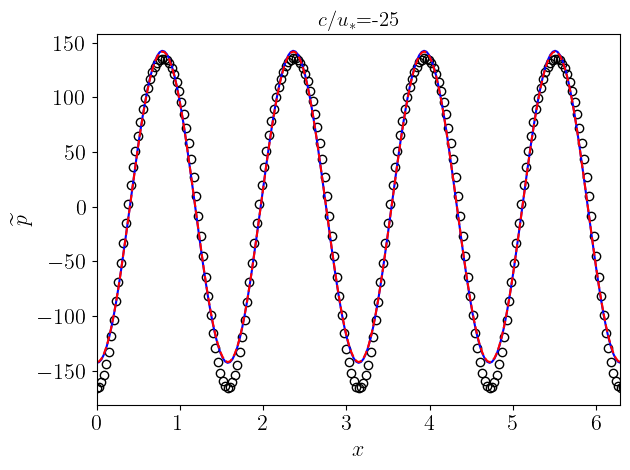

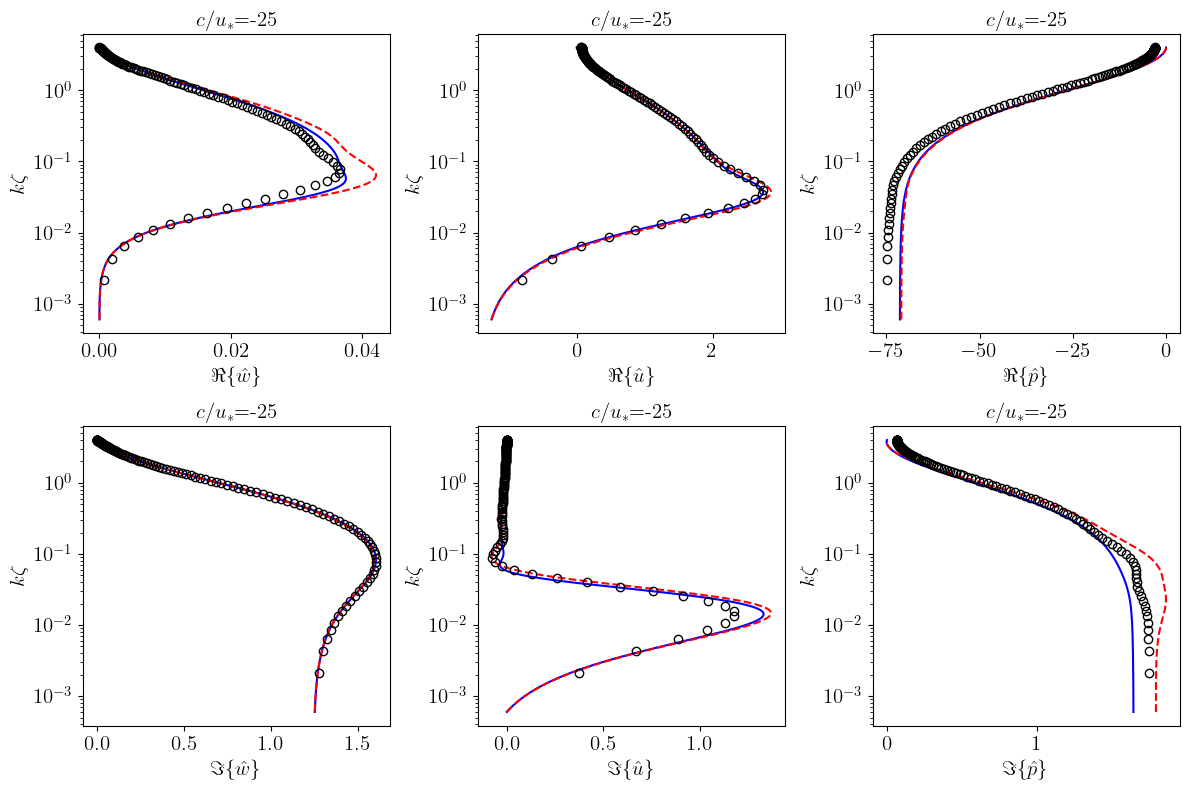

1
1 -15


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=4.71669e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.90437e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=6.49571e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=9.8534e-47): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


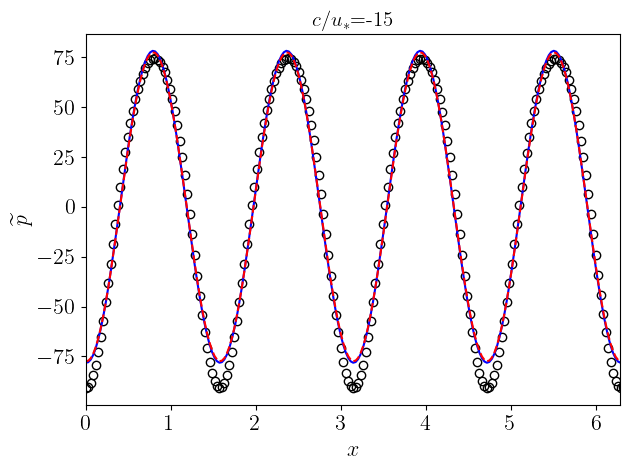

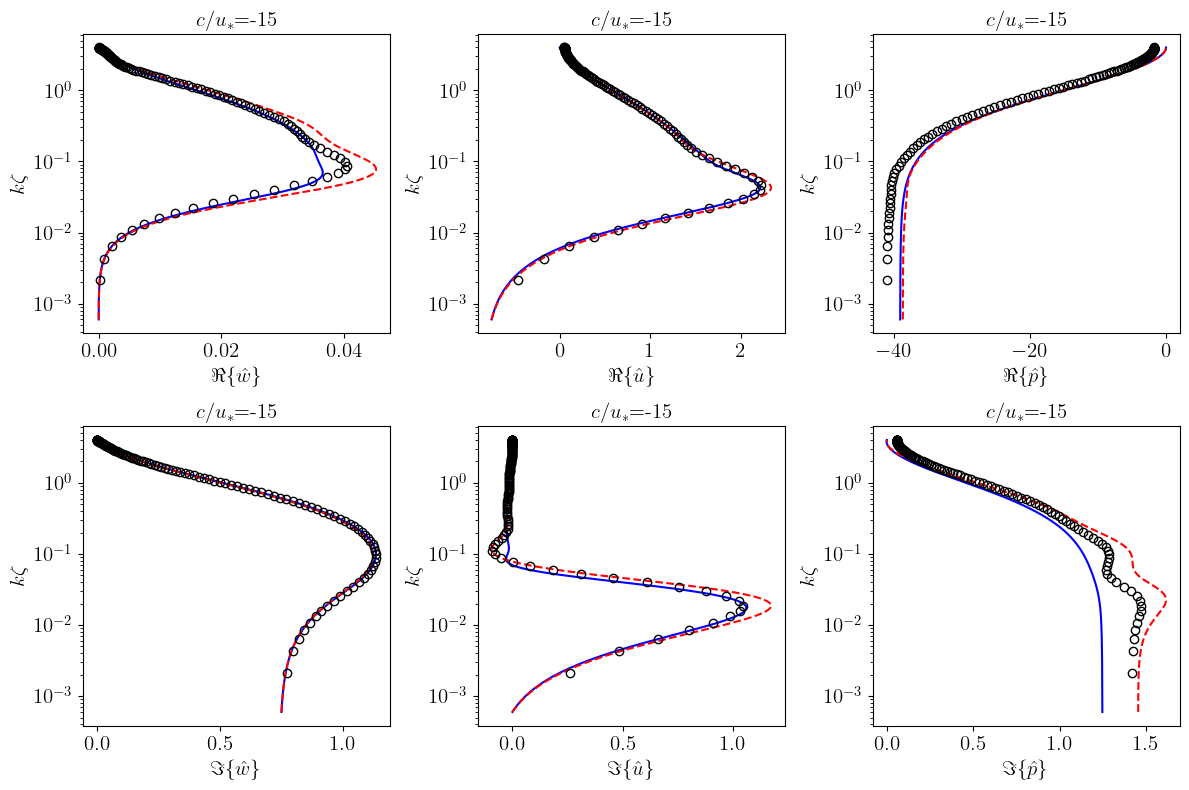

2
2 -7


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=6.7879e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.26945e-47): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=7.91636e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=8.65584e-47): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


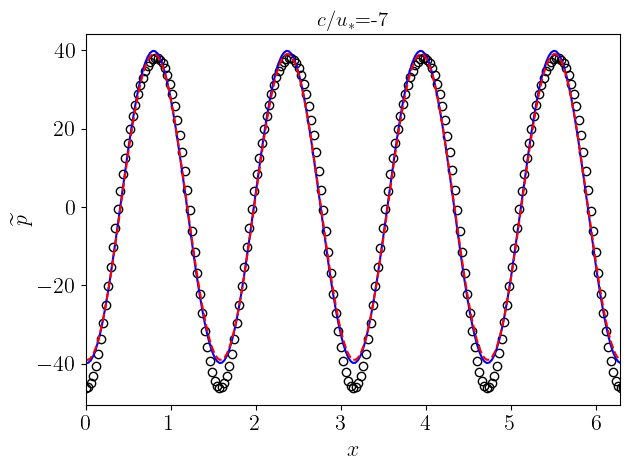

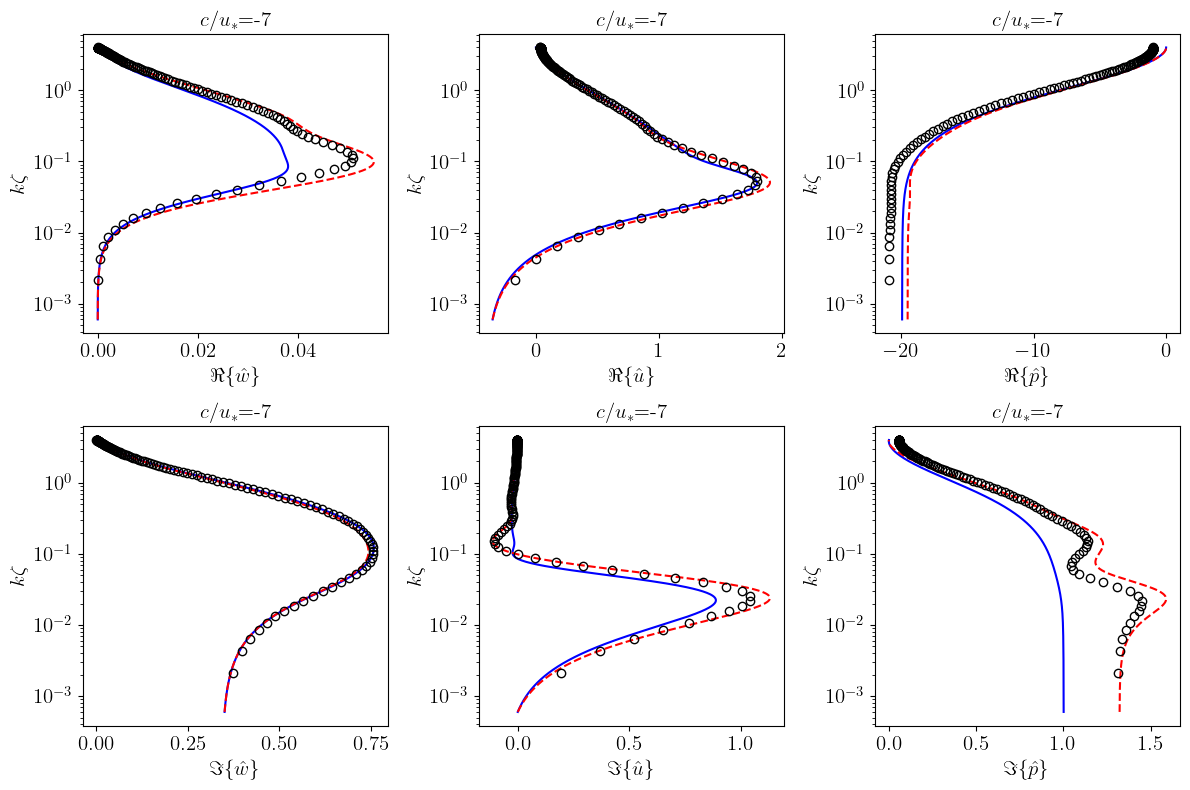

3
3 -2


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.62757e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.33592e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=6.94815e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.17684e-46): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


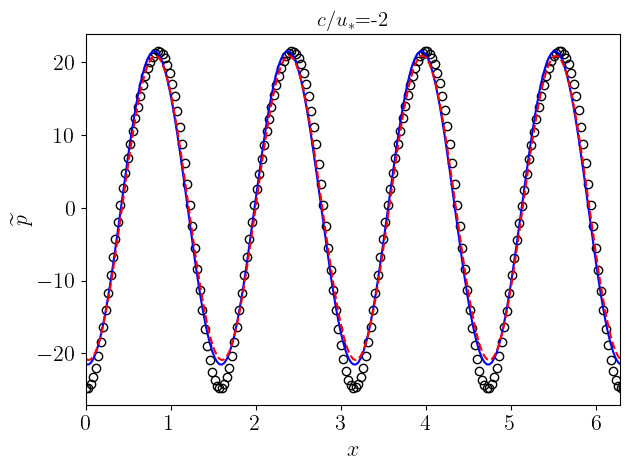

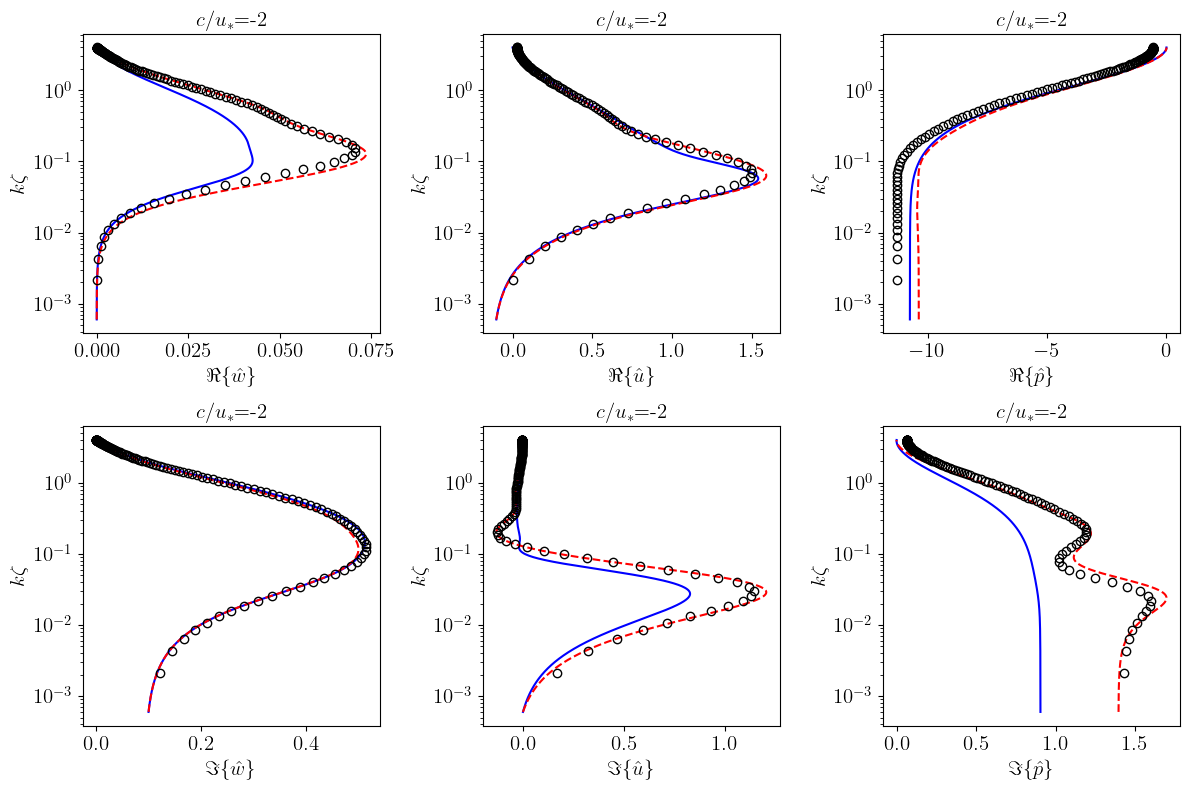

4
4 0


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.80265e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.45365e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=6.01007e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.35132e-46): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


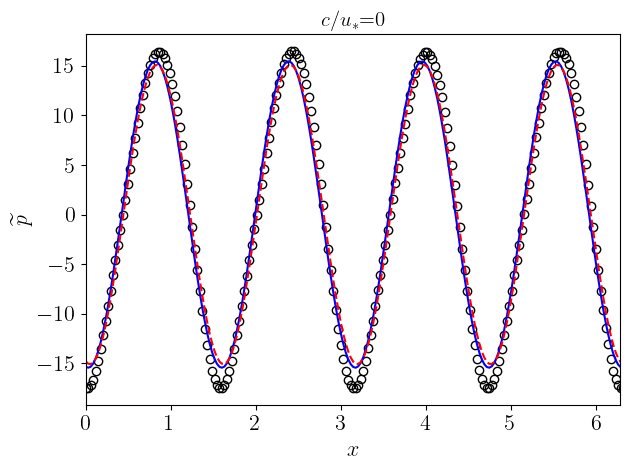

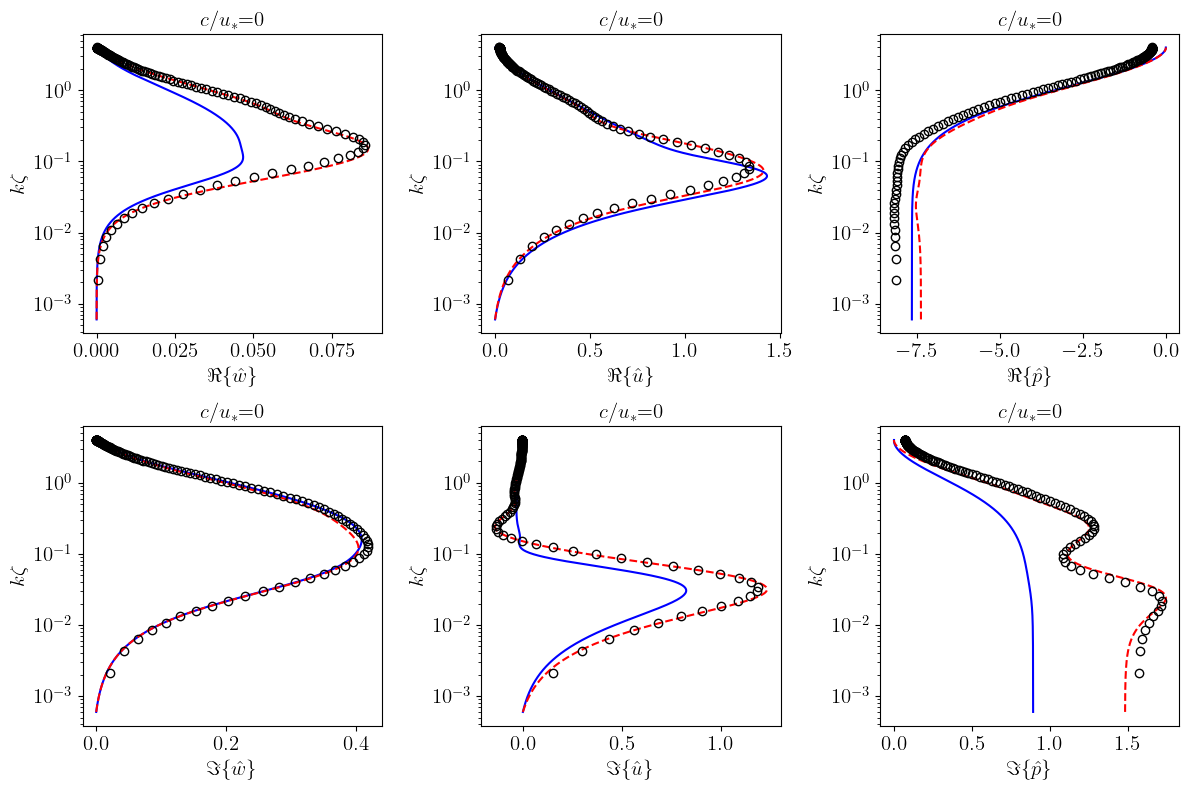

5
5 2


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.13695e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=4.12893e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.488e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.24299e-46): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


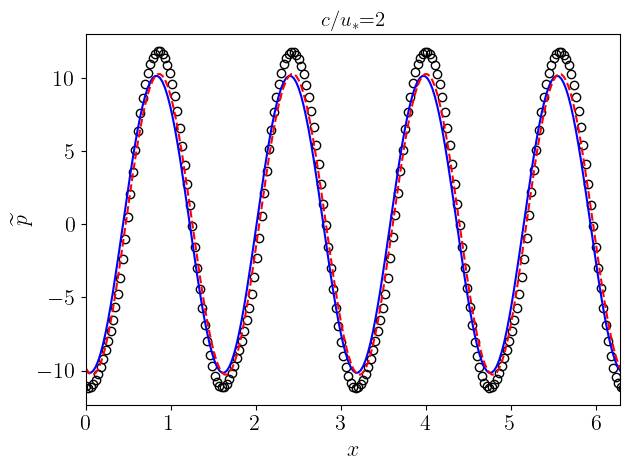

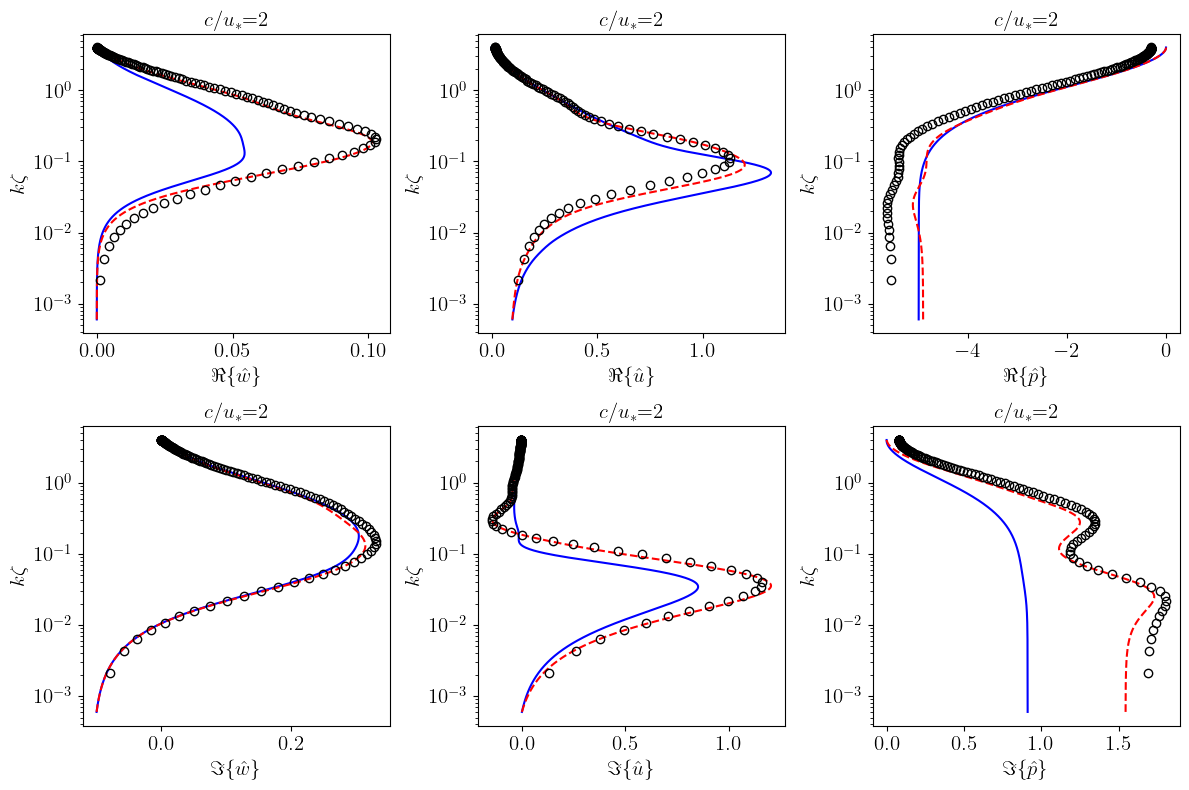

6
6 7


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=6.80608e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.95738e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.49001e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.8059e-47): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


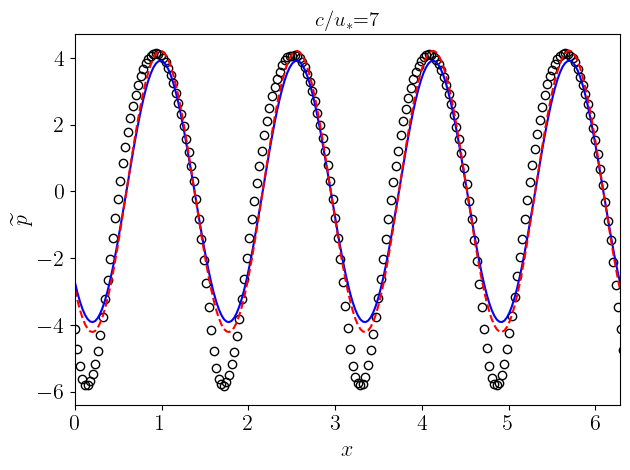

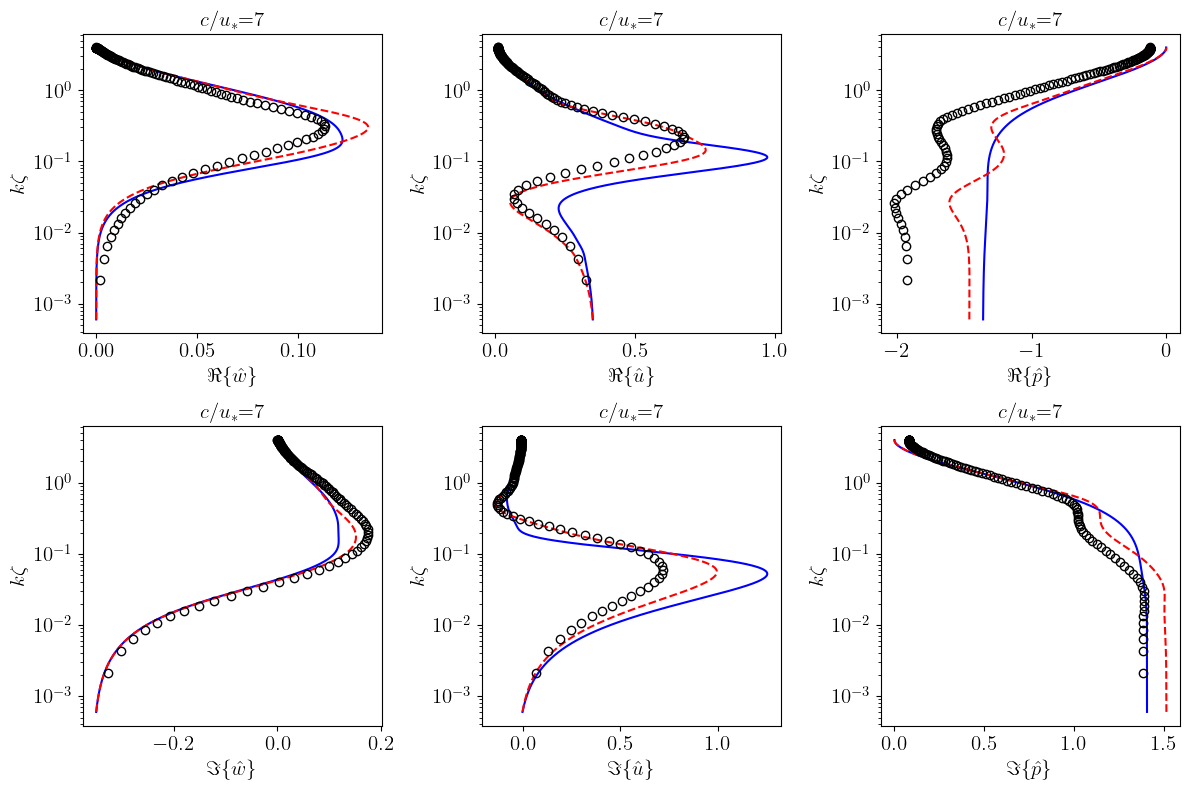

7
7 15


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.7787e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.90516e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.91915e-43): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=2.11977e-46): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


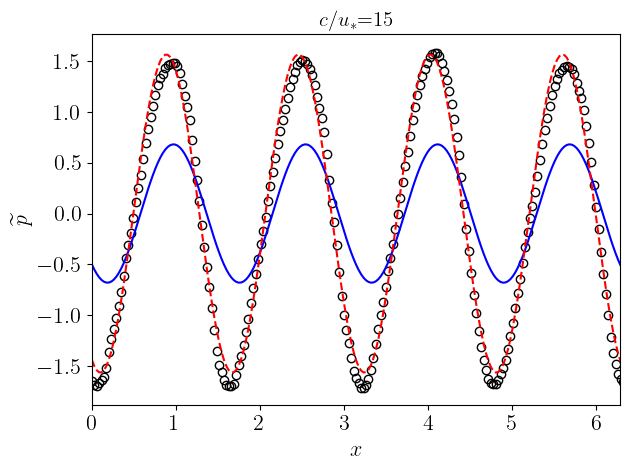

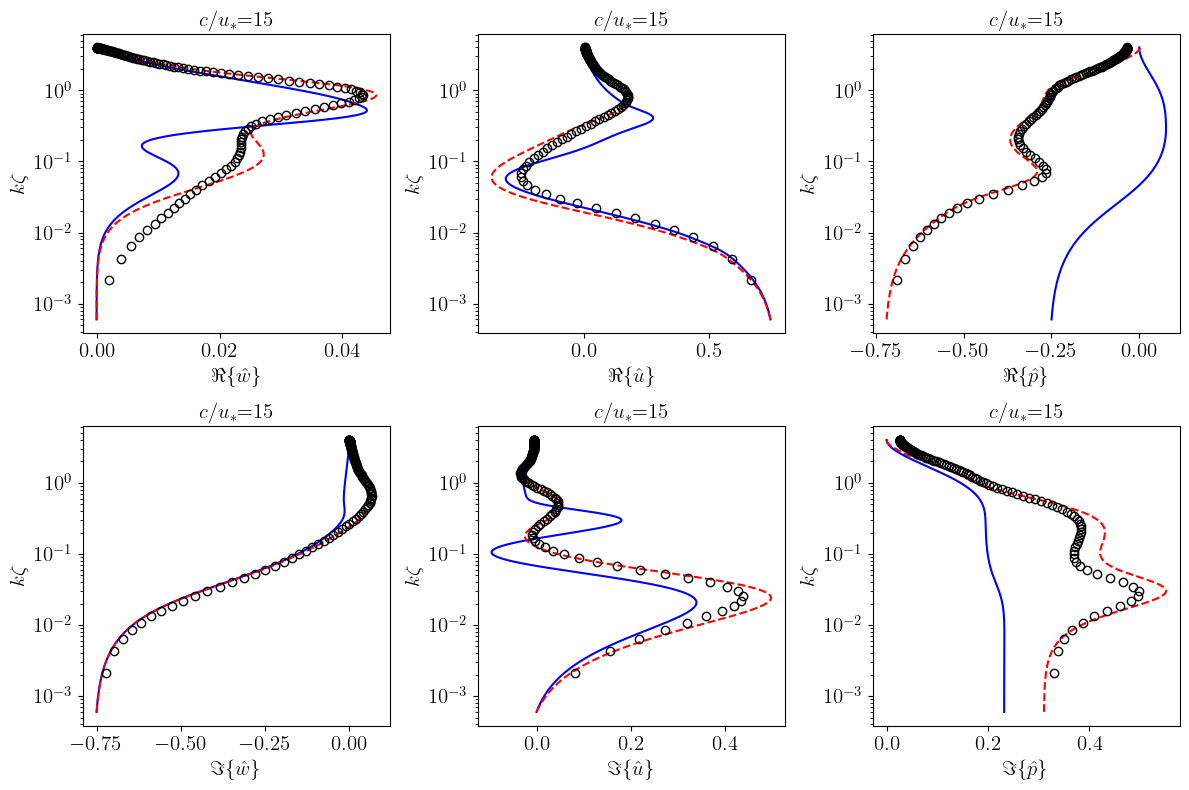

8
8 25


/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.95029e-44): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=1.28769e-48): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=4.37697e-45): result may not be accurate.
  w = la.solve(A, b)
/Users/ghaneshnarasimhan/Desktop/UMN/Bounday-Fitted-Code/WOW_visc-curv-model/TurbCurv-main/Github/TurbCurv/TurbCurv.py:214: LinAlgWarning: Ill-conditioned matrix (rcond=3.77117e-48): result may not be accurate.
  w = la.solve(A, b)


n,N 0 2048
n,N 1 2048
n,N 2 2048
n,N 3 2048
n,N 4 2048


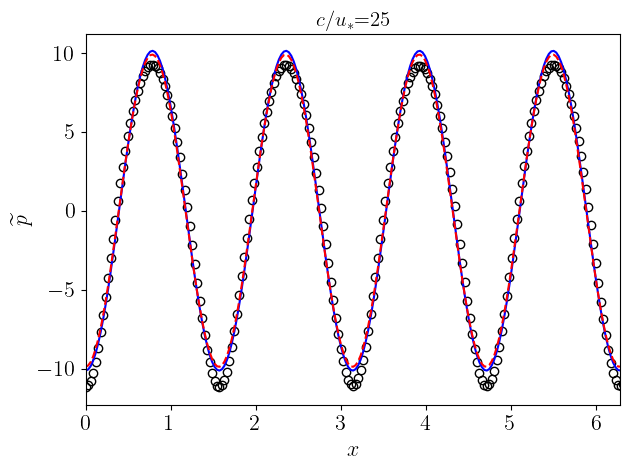

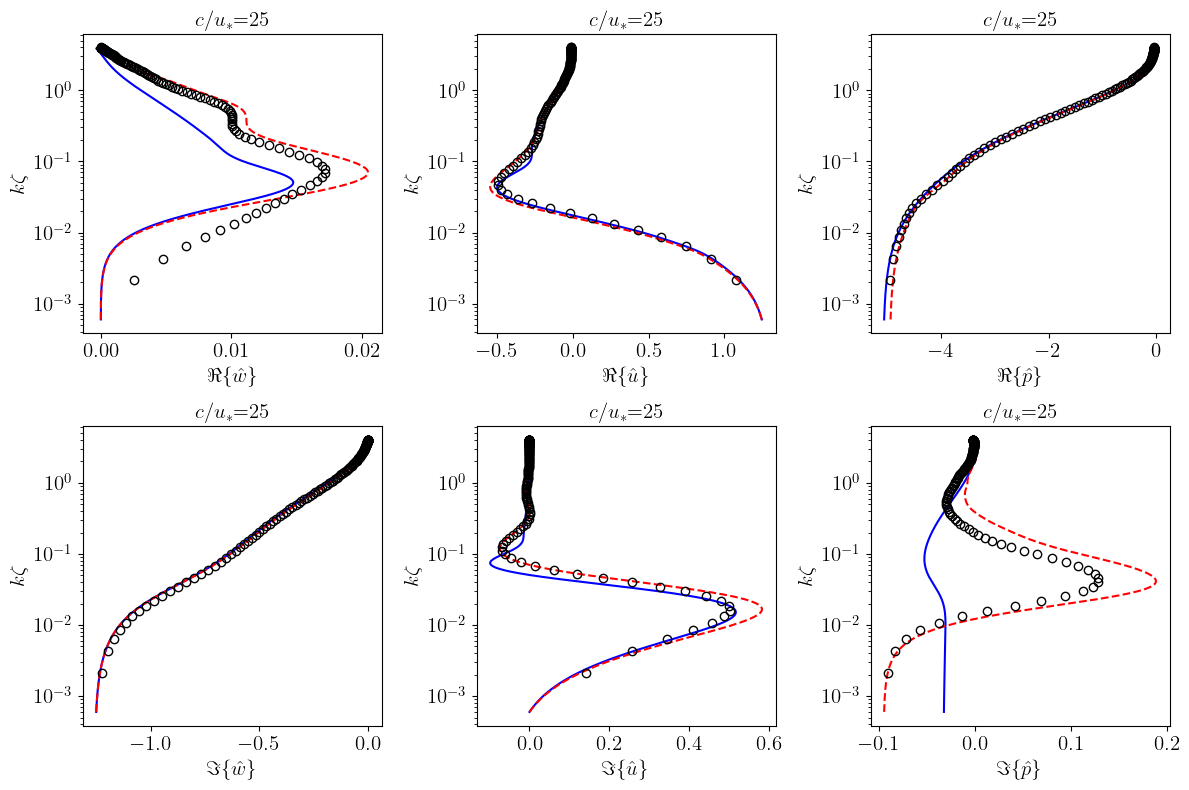

In [45]:
#Turb Curv Model
n_num = 5;
w     = np.zeros((N,n_num,9),dtype=complex)
Rew   = np.zeros((N,n_num,9),dtype=complex)
Imw   = np.zeros((N,n_num,9),dtype=complex)
DRew  = np.zeros((N,n_num,9),dtype=complex)
DImw  = np.zeros((N,n_num,9),dtype=complex)
D2Rew = np.zeros((N,n_num,9),dtype=complex)
D2Imw = np.zeros((N,n_num,9),dtype=complex)
Reu   = np.zeros((N,n_num,9),dtype=complex)
Imu   = np.zeros((N,n_num,9),dtype=complex)
U     = np.zeros((N,n_num,9),dtype=complex)
U_prime        = np.zeros((N,n_num,9),dtype=complex)
U_double_prime = np.zeros((N,n_num,9),dtype=complex)
U_triple_prime = np.zeros((N,n_num,9),dtype=complex)

nuT11_LES = np.zeros((Nz,9),dtype=complex)
nuT33_LES = np.zeros((Nz,9),dtype=complex)
nuT13_LES = np.zeros((Nz,9),dtype=complex)
nuT31_LES = np.zeros((Nz,9),dtype=complex)

nuT11_interp = np.zeros((N,9),dtype=complex)
nuT33_interp = np.zeros((N,9),dtype=complex)
nuT13_interp = np.zeros((N,9),dtype=complex)
nuT31_interp = np.zeros((N,9),dtype=complex)

x = np.linspace(0,Lx,Nx)
y = a*np.cos(k_wavno*x)

Rep = np.zeros((N,4,n_num,9),dtype=complex)
Imp = np.zeros((N,4,n_num,9),dtype=complex)


for num_data_select in range(9):
    print(num_data_select)
    c=c_array[num_data_select] # in meter per second
    print(num_data_select,c)
    filename_fig = [
        '01_SurfacePressure_ComparisonWithLES_case0.png',
        '01_SurfacePressure_ComparisonWithLES_case1.png',
        '01_SurfacePressure_ComparisonWithLES_case2.png',
        '01_SurfacePressure_ComparisonWithLES_case3.png',
        '01_SurfacePressure_ComparisonWithLES_case4.png',
        '01_SurfacePressure_ComparisonWithLES_case5.png',
        '01_SurfacePressure_ComparisonWithLES_case6.png',
        '01_SurfacePressure_ComparisonWithLES_case7.png',
        '01_SurfacePressure_ComparisonWithLES_case8.png'
    ]
        
    #Grid for turb curv model
    if use_non_uniform_grid:
        z0=1.5e-4        
        #Tanh-stretched grid
        z_min = z0  # Minimum value in the physical domain
        z_max = 1.0  # Maximum value in the physical domain
        alpha = 8.0  # Stretching factor (adjust for more/less stretching)

        # Create a linearly spaced grid in the range [0, 1]
        eta = np.linspace(-1, 1, N)

        # Apply the tanh stretching
        z_stretched = 0.5 * (np.tanh(alpha * eta) + 1)

        # Map the stretched grid to the desired physical domain
        z_non_uniform = z_min + z_stretched * (z_max - z_min)

        #z_non_uniform = np.logspace(np.log10(z0),np.log10(zi), N)
        z = z_non_uniform #np.logspace(np.log10(z0),np.log10(zi), N)
    else:
        z_uniform = np.linspace(z0,zi, N)
        z = z_uniform     #np.linspace(z0,zi, N)
    ###########################################################################################################################################################
    
    #Mean velocity and gradients from LES data
    z_data = np.asarray(LES_data[num_data_select].zw).flatten()
    U_data = np.asarray(LES_data[num_data_select].u_mean).flatten()
    
    
    U_spline = CubicSpline(z_data[0:-1],U_data[0:-1])
    U_visc = U_spline(z)
    
    U_prime_LES    = U_spline.derivative(nu=1)(z_data[0:-1])#np.gradient(U,z,edge_order=2)
    U_prime_spline = CubicSpline(z_data[0:-1],U_prime_LES)
    U_prime_visc   = U_prime_spline(z)
    
    
    U_double_prime_LES    = U_spline.derivative(nu=2)(z_data[0:-1])#np.gradient(U,z,edge_order=2)
    U_double_prime_spline = CubicSpline(z_data[0:-1],U_double_prime_LES)
    U_double_prime_visc   = U_double_prime_spline(z)
    
    U_triple_prime_LES    = U_spline.derivative(nu=3)(z_data[0:-1])#np.gradient(U,z,edge_order=2)
    U_triple_prime_spline = CubicSpline(z_data[0:-1],U_triple_prime_LES)
    U_triple_prime_visc   = U_triple_prime_spline(z)
    
    for n in range(n_num):
        U[:,n,num_data_select]       = U_visc
        U_prime[:,n,num_data_select] = U_prime_visc
        U_double_prime[:,n,num_data_select] = U_double_prime_visc
        U_triple_prime[:,n,num_data_select] = U_triple_prime_visc

    ##########################################################################################################################################
    w_hat_LES = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    u_hat_LES = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    dudz_hat_LES = np.gradient(u_hat_LES[16,0:-1],z_data[0:-1],edge_order=2)
    dwdz_hat_LES = np.gradient(w_hat_LES[16,0:-1],z_data[0:-1],edge_order=2)
    #tau13_mean_tot_LES = (LES_data[num_data_select].tau13_wave_mean[0:-1]*0+LES_data[num_data_select].tau13_mean[0:-1]+LES_data[num_data_select].tau13_SGS_mean[0:-1]).flatten()
    #tau31_mean_tot_LES = (LES_data[num_data_select].tau31_mean[0:-1]+LES_data[num_data_select].tau31_SGS_mean[0:-1]).flatten()

    ##########################################################################################################################################
    #Viscous stress
    tau11_nu_hat_LES = np.fft.fft(LES_data[num_data_select].tau11_nu[:,0:-1],norm='forward')
    tau13_nu_hat_LES = np.fft.fft(LES_data[num_data_select].tau13_nu[:,0:-1],norm='forward')
    tau31_nu_hat_LES = np.fft.fft(LES_data[num_data_select].tau31_nu[:,0:-1],norm='forward')
    tau33_nu_hat_LES = np.fft.fft(LES_data[num_data_select].tau33_nu[:,0:-1],norm='forward')
    
    tau11_nu_hat_LES_spline = CubicSpline(z_data[0:-1],tau11_nu_hat_LES[16,:])
    tau13_nu_hat_LES_spline = CubicSpline(z_data[0:-1],tau13_nu_hat_LES[16,:])
    tau31_nu_hat_LES_spline = CubicSpline(z_data[0:-1],tau31_nu_hat_LES[16,:])
    tau33_nu_hat_LES_spline = CubicSpline(z_data[0:-1],tau33_nu_hat_LES[16,:])
    
    dtau11_nu_hat_dz_LES_interp   = tau11_nu_hat_LES_spline.derivative(nu=1)(z)
    d2tau13_nu_hat_dz2_LES_interp = tau13_nu_hat_LES_spline.derivative(nu=2)(z)
    tau31_nu_hat_LES_interp       = tau31_nu_hat_LES_spline(z)
    dtau33_nu_hat_dz_LES_interp   = tau33_nu_hat_LES_spline.derivative(nu=1)(z)
    ##########################################################################################################################################
    #nu_T,I
    nuT_linear = ustar*kappa*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*Retau/25/zi))
    nuT_linear_1_interp  = np.interp(z,z_data[0:-1],nuT_linear)
    nuT_prime_1          = np.gradient(nuT_linear,z_data[0:-1])
    nuT_prime_1_interp   = np.interp(z,z_data[0:-1],nuT_prime_1)
    nuT_double_prime_1   = np.gradient(nuT_prime_1,z_data[0:-1])    
    nuT_double_prime_1_interp   = np.interp(z,z_data[0:-1],nuT_double_prime_1)
    
    tau11_hat_model = 2*nuT_linear*dwdz_hat_LES
    tau13_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) - nuT_linear*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) 
    tau33_hat_model =   nuT_linear*(1j*k_wavno*u_hat_LES[16,0:-1]-dwdz_hat_LES)

    tau11_hat_model_spline = CubicSpline(z_data[0:-1],tau11_hat_model)
    tau13_hat_model_spline = CubicSpline(z_data[0:-1],tau13_hat_model)
    tau31_hat_model_spline = CubicSpline(z_data[0:-1],tau31_hat_model)
    tau33_hat_model_spline = CubicSpline(z_data[0:-1],tau33_hat_model)
    dtau11_hat_dz_model_interp   = tau11_hat_model_spline.derivative(nu=1)(z)
    d2tau13_hat_dz2_model_interp = tau13_hat_model_spline.derivative(nu=2)(z)
    tau31_hat_model_interp     = tau31_hat_model_spline(z)
    dtau33_hat_dz_model_interp = tau33_hat_model_spline.derivative(nu=1)(z)

    ##########################################################################################################################################
    #nu_T,II
    nuT_linear_2 = c1_fit_const[num_data_select]*0.41*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*Retau/25))*(1-z_data[0:-1])**(c2_const)#ustar*kappa*z_data[0:-1]*(1-np.exp(-z_data[0:-1]*Retau/25))*np.exp(-0.5*k_wavno*z_data[0:-1]) # 1*0.41*z_data[0:-1]
    nuT_linear_2_interp  = np.interp(z,z_data[0:-1],nuT_linear_2)
    nuT_prime_2  = np.gradient(nuT_linear_2,z_data[0:-1])
    nuT_prime_2_interp  = np.interp(z,z_data[0:-1],nuT_prime_2)
    nuT_double_prime_2  = np.gradient(nuT_prime_2,z_data[0:-1])    
    nuT_double_prime_2_interp   = np.interp(z,z_data[0:-1],nuT_double_prime_2)
    
    
    tau11_hat_model_2 = 2*nuT_linear_2*dwdz_hat_LES
    tau13_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) - nuT_linear_2*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) 
    tau33_hat_model_2 =   nuT_linear_2*(1j*k_wavno*u_hat_LES[16,0:-1]-dwdz_hat_LES)

    tau11_hat_model_2_spline = CubicSpline(z_data[0:-1],tau11_hat_model_2)
    tau13_hat_model_2_spline = CubicSpline(z_data[0:-1],tau13_hat_model_2)
    tau31_hat_model_2_spline = CubicSpline(z_data[0:-1],tau31_hat_model_2)
    tau33_hat_model_2_spline = CubicSpline(z_data[0:-1],tau33_hat_model_2)
    dtau11_hat_dz_model_2_interp   = tau11_hat_model_2_spline.derivative(nu=1)(z)
    d2tau13_hat_dz2_model_2_interp = tau13_hat_model_2_spline.derivative(nu=2)(z)
    tau31_hat_model_2_interp = tau31_hat_model_2_spline(z)
    dtau33_hat_dz_model_2_interp = tau33_hat_model_2_spline.derivative(nu=1)(z)

    ##########################################################################################################################################
    #nu_T,III (Cess profile)
    eta_Cess = z_data[0:-1]-1
    
    nuT_linear_3        = (nu/2)*(1+(0.41**2*Retau**2/9)*(1-eta_Cess**2)**2*(1+2*eta_Cess**2)**2
                                *(1-np.exp((np.abs(eta_Cess)-1)*Retau/25))**2)**(1/2)-nu/2
    nuT_linear_3_interp = np.interp(z,z_data[0:-1],nuT_linear_3)
    nuT_prime_3         = np.gradient(nuT_linear_3,z_data[0:-1])
    nuT_prime_3_interp  = np.interp(z,z_data[0:-1],nuT_prime_3)
    nuT_double_prime_3  = np.gradient(nuT_prime_3,z_data[0:-1])    
    nuT_double_prime_3_interp   = np.interp(z,z_data[0:-1],nuT_double_prime_3)
    
    tau11_hat_model_3 = 2*nuT_linear_3*dwdz_hat_LES
    tau13_hat_model_3 =  -nuT_linear_3*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) - nuT_linear_3*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model_3 =  -nuT_linear_3*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) 
    tau33_hat_model_3 =   nuT_linear_3*(1j*k_wavno*u_hat_LES[16,0:-1]-dwdz_hat_LES)

    tau11_hat_model_3_spline = CubicSpline(z_data[0:-1],tau11_hat_model_3)
    tau13_hat_model_3_spline = CubicSpline(z_data[0:-1],tau13_hat_model_3)
    tau31_hat_model_3_spline = CubicSpline(z_data[0:-1],tau31_hat_model_3)
    tau33_hat_model_3_spline = CubicSpline(z_data[0:-1],tau33_hat_model_3)
    
    dtau11_hat_dz_model_3_interp   = tau11_hat_model_3_spline.derivative(nu=1)(z)
    d2tau13_hat_dz2_model_3_interp = tau13_hat_model_3_spline.derivative(nu=2)(z)
    tau31_hat_model_3_interp       = tau31_hat_model_3_spline(z)
    dtau33_hat_dz_model_3_interp   = tau33_hat_model_3_spline.derivative(nu=1)(z)
    ##########################################################################################################################################
    #Wave-induced turbulence stress terms from LES
    tau11_hat_LES = np.fft.fft(LES_data[num_data_select].tau11_d+LES_data[num_data_select].tau11_d_SGS,axis=0,norm='forward')
    tau13_hat_LES = np.fft.fft(LES_data[num_data_select].tau13  +LES_data[num_data_select].tau13_SGS,axis=0,norm='forward')
    tau31_hat_LES = np.fft.fft(LES_data[num_data_select].tau31  +LES_data[num_data_select].tau31_SGS,axis=0,norm='forward')
    tau33_hat_LES = np.fft.fft(LES_data[num_data_select].tau33_d+LES_data[num_data_select].tau33_d_SGS,axis=0,norm='forward')
    
    tau11_hat_spline = CubicSpline(z_data[0:-1],tau11_hat_LES[16,0:-1])
    tau13_hat_spline = CubicSpline(z_data[0:-1],tau13_hat_LES[16,0:-1])
    tau31_hat_spline = CubicSpline(z_data[0:-1],tau31_hat_LES[16,0:-1])
    tau33_hat_spline = CubicSpline(z_data[0:-1],tau33_hat_LES[16,0:-1])

    tau11_hat_interp = tau11_hat_spline(z)
    tau13_hat_interp = tau13_hat_spline(z)
    tau31_hat_interp = tau31_hat_spline(z)
    tau33_hat_interp = tau33_hat_spline(z)

    dtau11_hat_dz_interp      = tau11_hat_spline.derivative(nu=1)(z)
    dtau33_hat_dz_interp      = tau33_hat_spline.derivative(nu=1)(z)
    d2tau13_hat_dz2_interp    = tau13_hat_spline.derivative(nu=2)(z)

    ##########################################################################################################################################
    
    nuT11_LES[0:-1,num_data_select] = (tau11_hat_LES[16,0:-1]/(2*dwdz_hat_LES))
    nuT13_LES[0:-1,num_data_select] = (tau13_hat_LES[16,0:-1]/(-(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1]) -U_prime_LES*(1/zi)*(a/2)))
    nuT31_LES[0:-1,num_data_select] = (tau31_hat_LES[16,0:-1]/(-(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,0:-1])))
    nuT33_LES[0:-1,num_data_select] = (tau33_hat_LES[16,0:-1]/(1j*k_wavno*u_hat_LES[16,0:-1]-dwdz_hat_LES))
    
    nuT11_spline = CubicSpline(z_data[0:-1],nuT11_LES[0:-1,num_data_select], bc_type='not-a-knot')
    nuT13_spline = CubicSpline(z_data[0:-1],nuT13_LES[0:-1,num_data_select], bc_type='not-a-knot')
    nuT31_spline = CubicSpline(z_data[0:-1],nuT31_LES[0:-1,num_data_select], bc_type='not-a-knot')
    nuT33_spline = CubicSpline(z_data[0:-1],nuT33_LES[0:-1,num_data_select], bc_type='not-a-knot')
    
    nuT11_interp[:,num_data_select] = inner_layer_depth[num_data_select]/k_wavno*2*np.ones((N,),dtype=float)# nuT11_spline(z)
    nuT13_interp[:,num_data_select] = inner_layer_depth[num_data_select]/k_wavno*2*np.ones((N,),dtype=float)#nuT13_spline(z)
    nuT31_interp[:,num_data_select] = inner_layer_depth[num_data_select]/k_wavno*0.5*np.ones((N,),dtype=float)#nuT31_spline(z)
    nuT33_interp[:,num_data_select] = inner_layer_depth[num_data_select]/k_wavno*1*np.ones((N,),dtype=float)# nuT33_spline(z)
    
    #########################################################################################################################################
    #Wave-induced stress terms from LES
    tau11_wave_hat_LES= np.fft.fft(LES_data[num_data_select].tau11_wave,axis=0,norm='forward')
    tau13_wave_hat_LES= np.fft.fft(LES_data[num_data_select].tau13_wave,axis=0,norm='forward')
    tau31_wave_hat_LES= np.fft.fft(LES_data[num_data_select].tau31_wave,axis=0,norm='forward')
    tau33_wave_hat_LES= np.fft.fft(LES_data[num_data_select].tau33_wave,axis=0,norm='forward')
    
    tau11_wave_hat_spline = CubicSpline(z_data[0:-1],tau11_wave_hat_LES[16,0:-1])
    tau13_wave_hat_spline = CubicSpline(z_data[0:-1],tau13_wave_hat_LES[16,0:-1])
    tau31_wave_hat_spline = CubicSpline(z_data[0:-1],tau31_wave_hat_LES[16,0:-1])
    tau33_wave_hat_spline = CubicSpline(z_data[0:-1],tau33_wave_hat_LES[16,0:-1])
    
    
    tau11_wave_hat_interp = tau11_wave_hat_spline(z)
    tau13_wave_hat_interp = tau13_wave_hat_spline(z)
    tau31_wave_hat_interp = tau31_wave_hat_spline(z)
    tau33_wave_hat_interp = tau33_wave_hat_spline(z)

    dtau11_wave_hat_dz_interp = tau11_wave_hat_spline.derivative(nu=1)(z)
    dtau33_wave_hat_dz_interp = tau33_wave_hat_spline.derivative(nu=1)(z)
    d2tau13_wave_hat_dz2_interp = tau13_wave_hat_spline.derivative(nu=1)(z)
    #########################################################################################################################################
    
    # Inhomogeneous term
    
    #g = lambda z, zi: z/zi -1
    g = z/zi-1
    g_zeta = 1/zi
    f_RHS  = np.zeros((N,n_num),dtype=complex)

    #Forcing term for viscous curvilinear model
    f_RHS[:,0] =  nu*a/2*np.gradient(np.gradient(g*U_double_prime[:,0,num_data_select],z,edge_order=2),z,edge_order=2) 

    #Forcing term for turbulence curvilinear model
    f_RHS[:,1] =   nu*a/2*np.gradient(np.gradient(g*U_double_prime[:,0,num_data_select],z,edge_order=2),z,edge_order=2) \
                  +( 1*1j*k_wavno*dtau11_hat_dz_interp + 1*d2tau13_hat_dz2_interp )\
                  +( 1*k_wavno**2*tau31_hat_interp - 1*1j*k_wavno*dtau33_hat_dz_interp )
    
    #Forcing term for turbulence curvilinear model using nu_T,I eddy viscosity model
    f_RHS[:,2] =   (nu*1+nuT_linear_1_interp*1)*a/2*np.gradient(np.gradient(g*U_double_prime[:,0,num_data_select],z,edge_order=2),z,edge_order=2) \
                   +1*nuT_prime_1_interp*a/2*g*(2*U_triple_prime[:,0,num_data_select]-k_wavno**2*U_prime[:,0,num_data_select]) \
                   +1*nuT_prime_1_interp*a/2*g_zeta*2*U_double_prime[:,0,num_data_select] \
                   +1*nuT_double_prime_1_interp*g*a/2*U_double_prime[:,0,num_data_select]

    #Forcing term for turbulence curvilinear model using nu_T,II eddy viscosity model
    f_RHS[:,3] =   (nu*1+nuT_linear_2_interp*1)*a/2*np.gradient(np.gradient(g*U_double_prime[:,0,num_data_select],z,edge_order=2),z,edge_order=2) \
                   +1*nuT_prime_2_interp*a/2*g*(2*U_triple_prime[:,0,num_data_select]-k_wavno**2*U_prime[:,0,num_data_select]) \
                   +1*nuT_prime_2_interp*a/2*g_zeta*2*U_double_prime[:,0,num_data_select] \
                   +1*nuT_double_prime_2_interp*g*a/2*U_double_prime[:,0,num_data_select]


    #Forcing term for turbulence curvilinear model using nu_T,III (Cess-type) eddy viscosity model
    f_RHS[:,4] =   (nu*1+nuT_linear_3_interp*1)*a/2*np.gradient(np.gradient(g*U_double_prime[:,0,num_data_select],z,edge_order=2),z,edge_order=2) \
                   +1*nuT_prime_3_interp*a/2*g*(2*U_triple_prime[:,0,num_data_select]-k_wavno**2*U_prime[:,0,num_data_select]) \
                   +1*nuT_prime_3_interp*a/2*g_zeta*2*U_double_prime[:,0,num_data_select] \
                   +1*nuT_double_prime_3_interp*g*a/2*U_double_prime[:,0,num_data_select]
    
    plt.show()

    # Solve Orr-Sommerfeld equation
    
    if use_non_uniform_grid:
        ##Boundary conditions: [phi(-1), phi'(-1), phi(1), phi'(1)]
    
        w_s   = -1j*0.5*a*k_wavno*c

        dwdz_s= -1j*0.5*a*k_wavno**2*c-1j*0.5*a*k_wavno*(-1)*U_prime[0,0,num_data_select]

        z_bc  =  [w_s,dwdz_s,0.0, 0.0]

        w[:,0,num_data_select]    = orr_sommerfeld_non_uniform(N, z, nu*1, np.zeros((N,),dtype='float'), np.zeros((N,),dtype='float'), np.zeros((N,),dtype='float') , k_wavno, U[:,0,num_data_select], c, U_double_prime[:,0,num_data_select], f_RHS[:,0],z_bc)
    
        ######################################################################################################################################################################################
       
        w_s   = -1j*0.5*a*k_wavno*c
       
        dwdz_s= -1j*0.5*a*k_wavno**2*c-1j*0.5*a*k_wavno*(-1)*U_prime[0,1,num_data_select]

        z_bc  =  [w_s,dwdz_s,0.0, 0.0]
        
        w[:,1,num_data_select]    = orr_sommerfeld_non_uniform(N, z, nu*1, np.zeros((N,),dtype='float'), np.zeros((N,),dtype='float'), np.zeros((N,),dtype='float')  , k_wavno, U[:,1,num_data_select], c, U_double_prime[:,1,num_data_select], f_RHS[:,1],z_bc)
        
        ######################################################################################################################################################################################
       
        w_s   = -1j*0.5*a*k_wavno*c

        dwdz_s= -1j*0.5*a*k_wavno**2*c-1j*0.5*a*k_wavno*(-1)*U_prime[0,2,num_data_select]

        z_bc  =  [w_s,dwdz_s,0.0, 0.0]
        
        w[:,2,num_data_select]    = orr_sommerfeld_non_uniform(N, z, nu*1, nuT_linear_1_interp*1, nuT_prime_1_interp*1, nuT_double_prime_1_interp*1  , k_wavno, U[:,2,num_data_select], c, U_double_prime[:,2,num_data_select], f_RHS[:,2],z_bc)

    ######################################################################################################################################################################################
       
        w_s   = -1j*0.5*a*k_wavno*c

        dwdz_s= -1j*0.5*a*k_wavno**2*c-1j*0.5*a*k_wavno*(-1)*U_prime[0,3,num_data_select]

        z_bc  =  [w_s,dwdz_s,0.0, 0.0]
        
        w[:,3,num_data_select]    = orr_sommerfeld_non_uniform(N, z, nu*1, nuT_linear_2_interp*1, nuT_prime_2_interp*1, nuT_double_prime_2_interp*1  , k_wavno, U[:,3,num_data_select], c, U_double_prime[:,3,num_data_select], f_RHS[:,3],z_bc)

    ######################################################################################################################################################################################
       
        w_s   = -1j*0.5*a*k_wavno*c

        dwdz_s= -1j*0.5*a*k_wavno**2*c-1j*0.5*a*k_wavno*(-1)*U_prime[0,4,num_data_select]

        z_bc  =  [w_s,dwdz_s,0.0, 0.0]
        
        w[:,4,num_data_select]    = orr_sommerfeld_non_uniform(N, z, nu*1, nuT_linear_3_interp*1, nuT_prime_3_interp*1, nuT_double_prime_3_interp*1  , k_wavno, U[:,4,num_data_select], c, U_double_prime[:,4,num_data_select], f_RHS[:,4],z_bc)
    
   
    else:
        print("Use non uniform grid")
        
    
    # Calculate Real and Imaginary parts of w perturbation
    for n in range(n_num):
        Rew[:,n,num_data_select]  = np.real(w[:,n,num_data_select])
        Imw[:,n,num_data_select]  = np.imag(w[:,n,num_data_select])
        DRew[:,n,num_data_select] = np.gradient(np.real(w[:,n,num_data_select]),z,edge_order=2)
        DImw[:,n,num_data_select] = np.gradient(np.imag(w[:,n,num_data_select]),z,edge_order=2)
        D2Rew[:,n,num_data_select]= np.gradient(DRew[:,n,num_data_select],z,edge_order=2)
        D2Imw[:,n,num_data_select]= np.gradient(DImw[:,n,num_data_select],z,edge_order=2)
        Reu[:,n,num_data_select]  = -(1/k_wavno)*DImw[:,n,num_data_select]-0.5*a*(z/zi-1)*U_prime[:,n,num_data_select]
        Imu[:,n,num_data_select]  =  (1/k_wavno)*DRew[:,n,num_data_select]
         
    #### Compute pressure
    for n in range(n_num):
        print('n,N',n,N)
        for i in range(N):
            D2w_hat    =   D2Rew[i:,n,num_data_select]+1j*D2Imw[i:,n,num_data_select]
            p_hat_adv  =   np.trapz(1j*k_wavno*(U[i:,n,num_data_select]-c)*w[i:,n,num_data_select],z[i:])
            p_hat_visc =  -nu*np.trapz(-k_wavno**2*w[i:,n,num_data_select]+D2w_hat,z[i:])
            if n<2:
                p_hat_turb =  1j*k_wavno*np.trapz(tau31_hat_interp[i:],z[i:])+np.trapz(dtau33_hat_dz_interp[i:],z[i:])
            if n==2:
                p_hat_turb =  1j*k_wavno*np.trapz(tau31_hat_model_interp[i:],z[i:])+np.trapz(dtau33_hat_dz_model_interp[i:],z[i:])
            if n==3:
                p_hat_turb =  1j*k_wavno*np.trapz(tau31_hat_model_2_interp[i:],z[i:])+np.trapz(dtau33_hat_dz_model_2_interp[i:],z[i:])
            if n==4:
                p_hat_turb =  1j*k_wavno*np.trapz(tau31_hat_model_3_interp[i:],z[i:])+np.trapz(dtau33_hat_dz_model_3_interp[i:],z[i:])

            
            Rep[i,0,n,num_data_select] = p_hat_adv.real
            Rep[i,1,n,num_data_select] = p_hat_visc.real
            Rep[i,2,n,num_data_select] = p_hat_turb.real
            
            if n==0:
                Rep[i,3,n,num_data_select] = Rep[i,0,n,num_data_select]+Rep[i,1,n,num_data_select]*1+Rep[i,2,n,num_data_select]*0
            else:
                Rep[i,3,n,num_data_select] = Rep[i,0,n,num_data_select]+Rep[i,1,n,num_data_select]*1+Rep[i,2,n,num_data_select]
                
            Imp[i,0,n,num_data_select] =  p_hat_adv.imag
            Imp[i,1,n,num_data_select] =  p_hat_visc.imag
            Imp[i,2,n,num_data_select] =  p_hat_turb.imag
            
            if n==0:
                Imp[i,3,n,num_data_select]=  Imp[i,0,n,num_data_select]+Imp[i,1,n,num_data_select]*1+Imp[i,2,n,num_data_select]*0
            else:
                Imp[i,3,n,num_data_select]=  Imp[i,0,n,num_data_select]+Imp[i,1,n,num_data_select]*1+Imp[i,2,n,num_data_select]
    # plot it
    # f, (a0, a1, a2, a3) = plt.subplots(4, 1, gridspec_kw={'height_ratios': [10, 1, 10, 10]})
    fig, (a0) = plt.subplots(1, 1, gridspec_kw={'height_ratios': [5]})
        
    phase_diff=np.pi/2*0;
    a0.plot(x, LES_data[num_data_select].p_w_surf-np.mean(LES_data[num_data_select].p_w_surf),'ok',markerfacecolor='none',label='LES')
    
    for n in n_num_array_index:
        a0.plot(x, 2*Rep[0,3,n,num_data_select]*np.cos(k_wavno*x+phase_diff)*1-1*2*Imp[0,3,n,num_data_select]*np.sin(k_wavno*x+phase_diff),color_array_plot[n],label=r'$2Re\{\hat{p}\}\cos (k\xi)-2Im\{\hat{p}\}\sin (k\xi)$ (TurbCurv)')
    a0.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    a0.set_ylabel(r'$\widetilde{p}$',fontsize=16)
    a0.set_xlabel(r'$x$',fontsize=16)
    a0.tick_params(labelsize=16)
    a0.set_xlim(0,2*np.pi)
    #a0.legend(loc='upper left', bbox_to_anchor=(1, 1))
    #a0.set_ylim(-1,1)
    fig.tight_layout()
    #plt.savefig(filename_fig[num_data_select],format='png',dpi=100,bbox_inches='tight', 
    #               transparent=False,
    #               pad_inches=0.01)

    filename_fig = [
        '01_what_profile_ComparisonWithLES_case0.png',
        '01_what_profile_ComparisonWithLES_case1.png',
        '01_what_profile_ComparisonWithLES_case2.png',
        '01_what_profile_ComparisonWithLES_case3.png',
        '01_what_profile_ComparisonWithLES_case4.png',
        '01_what_profile_ComparisonWithLES_case5.png',
        '01_what_profile_ComparisonWithLES_case6.png',
        '01_what_profile_ComparisonWithLES_case7.png',
        '01_what_profile_ComparisonWithLES_case8.png'
    ]
    
    plt.figure(11,figsize=(12,8))
    
    ax1=plt.subplot(231)
    for n in n_num_array_index:
        plt.semilogy(Rew[:,n,num_data_select],k_wavno*z,color_array_plot_Re[n],label='$\Re\{\hat{w}\}$ (Model)')
        
    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    plt.semilogy(w_LES_data[16,:].real,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none',label='$\Re\{\hat{w}\}$ (LES)')
    
    
    ax1.set_xlabel(r'$\Re\{\hat{w}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)
    
    #ax1.legend(fontsize=11, frameon=False, loc='upper right', bbox_to_anchor=(2, 1))
    #plt.savefig(filename_fig[num_data_select],format='png',dpi=100,bbox_inches='tight', 
    #               transparent=False,
    #               pad_inches=0.01)
    #plt.close()


    ax1=plt.subplot(232)
    for n in n_num_array_index:
        plt.semilogy(Reu[:,n,num_data_select],k_wavno*z,color_array_plot_Re[n])
        #plt.semilogy(Imu[:,n],k*z,color_array_plot_Im[n])
    #plt.semilogy(np.sqrt(   Reuopposing[:]**2+Imuopposing[:]**2),k*z,'b--',label='$|\hat{u}|$ (Model)')
    #plt.semilogy(np.sqrt(Reuopposing_nu[:]**2+Imuopposing_nu[:]**2),k*z,'b-.',label='$|\hat{u}_\nu|$ (Model)')
    
    u_LES_data = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    plt.semilogy(u_LES_data[16,:].real,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    #plt.semilogy(u_LES_data[16,:].imag,k*LES_data[num_data_select].zw,'mo',markerfacecolor='none')
    #plt.semilogy(np.abs(u_LES_data[16,:]),k*LES_data[num_data_select].zw,'bv',markerfacecolor='none',label='$|\hat{u}|$ (LES)')
    
    ax1.set_xlabel(r'$\Re\{\hat{u}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)

    ax1=plt.subplot(233)
    for n in n_num_array_index:
        plt.semilogy(Rep[:,3,n,num_data_select],k_wavno*z,color_array_plot_Re[n])
        #plt.semilogy(Imp[:,3,n],k*z,color_array_plot_Im[n])
    #plt.semilogy(np.sqrt(   Rep_opposing[:]**2+Imp_opposing[:]**2),k*z,'b--',label='$|\hat{p}|$ (Model)')
    #plt.semilogy(np.sqrt(Rep_opposing_nu[:]**2+Imp_opposing_nu[:]**2),k*z,'b-.',label='$|\hat{p}_\nu|$ (Model)')
    
    p_LES_data = np.fft.fft(LES_data[num_data_select].p_w,axis=0,norm='forward')
    plt.semilogy(p_LES_data[16,:].real,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    #plt.semilogy(p_LES_data[16,:].imag,k*LES_data[num_data_select].zw,'mo',markerfacecolor='none')
    #plt.semilogy(np.abs(p_LES_data[16,:]),k*LES_data[num_data_select].zw,'bv',markerfacecolor='none',label='$|\hat{p}|$ (LES)')
    ax1.set_xlabel(r'$\Re\{\hat{p}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)


    ax1=plt.subplot(234)
    for n in n_num_array_index:
        #plt.semilogy(Rew[:,n],k*z,color_array_plot_Re[n],label='$\Re\{\hat{w}\}$ (Model)')
        plt.semilogy(Imw[:,n,num_data_select],k_wavno*z,color_array_plot_Im[n],label='$\Im\{\hat{w}\}$ (Model)')
    #plt.semilogy(np.sqrt(Rewopposing[:]**2+Imwopposing[:]**2),k*z,'b--',label='$|\hat{w}|$ (Model)')
    #plt.semilogy(np.sqrt(Rewopposing_nu[:]**2+Imwopposing_nu[:]**2),k*z,'b-.',label='$|\hat{w}_\nu|$ (Model)')
    
    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    #plt.semilogy(w_LES_data[16,:].real,k*LES_data[num_data_select].zw,'ko',markerfacecolor='none',label='$\Re\{\hat{w}\}$ (LES)')
    plt.semilogy(w_LES_data[16,:].imag,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none',label='$\Im\{\hat{w}\}$ (LES)')
    #plt.semilogy(np.abs(w_LES_data[16,:]),k*LES_data[num_data_select].zw,'bv',markerfacecolor='none',label='$|\hat{w}|$ (LES)')
    
    ax1.set_xlabel(r'$\Im\{\hat{w}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)
    
    ax1=plt.subplot(235)
    for n in n_num_array_index:
        #plt.semilogy(Reu[:,n],k*z,color_array_plot_Re[n])
        plt.semilogy(Imu[:,n,num_data_select],k_wavno*z,color_array_plot_Im[n])
    #plt.semilogy(np.sqrt(   Reuopposing[:]**2+Imuopposing[:]**2),k*z,'b--',label='$|\hat{u}|$ (Model)')
    #plt.semilogy(np.sqrt(Reuopposing_nu[:]**2+Imuopposing_nu[:]**2),k*z,'b-.',label='$|\hat{u}_\nu|$ (Model)')
    
    u_LES_data = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    #plt.semilogy(u_LES_data[16,:].real,k*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    plt.semilogy(u_LES_data[16,:].imag,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    #plt.semilogy(np.abs(u_LES_data[16,:]),k*LES_data[num_data_select].zw,'bv',markerfacecolor='none',label='$|\hat{u}|$ (LES)')
    
    ax1.set_xlabel(r'$\Im\{\hat{u}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)
    
    ax1=plt.subplot(236)
    for n in n_num_array_index:
        #plt.semilogy(Rep[:,3,n],k*z,color_array_plot_Re[n])
        plt.semilogy(Imp[:,3,n,num_data_select],k_wavno*z,color_array_plot_Im[n])
    #plt.semilogy(np.sqrt(   Rep_opposing[:]**2+Imp_opposing[:]**2),k*z,'b--',label='$|\hat{p}|$ (Model)')
    #plt.semilogy(np.sqrt(Rep_opposing_nu[:]**2+Imp_opposing_nu[:]**2),k*z,'b-.',label='$|\hat{p}_\nu|$ (Model)')
    
    p_LES_data = np.fft.fft(LES_data[num_data_select].p_w,axis=0,norm='forward')
    #plt.semilogy(p_LES_data[16,:].real,k*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    plt.semilogy(p_LES_data[16,:].imag,k_wavno*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    #plt.semilogy(np.abs(p_LES_data[16,:]),k*LES_data[num_data_select].zw,'bv',markerfacecolor='none',label='$|\hat{p}|$ (LES)')
    ax1.set_xlabel(r'$\Im\{\hat{p}\}$',fontsize=15)
    ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
    ax1.set_ylabel(r'$k\zeta$',fontsize=15)
    ax1.tick_params(labelsize=15)

    #plt.savefig(filename_fig[num_data_select],format='png',dpi=600,bbox_inches='tight',
    #            transparent=False,pad_inches=0.01)
    plt.show()

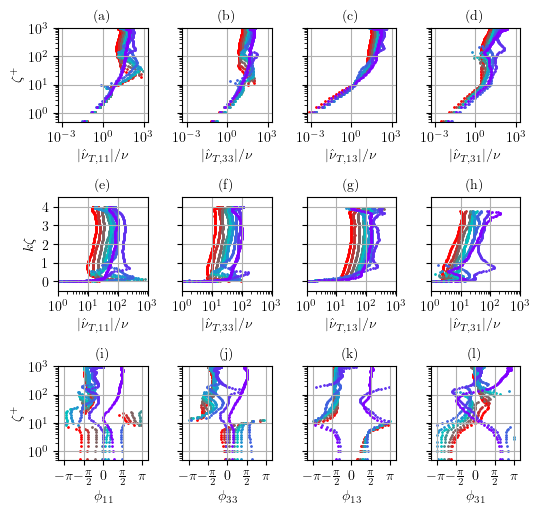

In [47]:
#Eddy viscosity based on wave-induced stress from LES
plt.figure(11,figsize=(5.5,6.5))
font_size=10
ax1=plt.subplot(4,4,1)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT11_LES[0:-1,num_data_select])/nu,(ustar/nu)*LES_data[num_data_select].zw[0:-1].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
    #plt.plot(np.array([5e-4, 2e3]), (ustar/nu) * np.array([inner_layer_depth[num_data_select]/k_wavno, inner_layer_depth[num_data_select]/k_wavno]), color=color_array[num_data_select],linestyle='--',zorder=1)

plt.xscale('log')
plt.yscale('log')
#plt.loglog((LES_data[num_data_select].zw[0:-1].flatten())**2,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(),'k:')
#plt.loglog((LES_data[num_data_select].zw[0:-1].flatten())**1,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(),'m:')
plt.xlabel(r'$|\hat{\nu}_{T,11}|/\nu$',fontsize=font_size)
plt.ylabel(r'$\zeta^+$',fontsize=font_size)
ax1.set_title('(a)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(5e-4,2e3)
plt.xticks([1e-3,1,1e3])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,2)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT33_LES[0:-1,num_data_select])/nu,(ustar/nu)*LES_data[num_data_select].zw[0:-1].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$|\hat{\nu}_{T,33}|/\nu$',fontsize=font_size)
plt.ylabel('')
ax1.set_yticklabels('')
ax1.set_title('(b)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(5e-4,2e3)
plt.xticks([1e-3,1,1e3])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,3)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT13_LES[0:-20,num_data_select])/nu,(ustar/nu)*LES_data[num_data_select].zw[0:-20].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$|\hat{\nu}_{T,13}|/\nu$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(c)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(5e-4,2e3)
plt.xticks([1e-3,1,1e3])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,4)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT31_LES[0:-30,num_data_select])/nu,(ustar/nu)*LES_data[num_data_select].zw[0:-30].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$|\hat{\nu}_{T,31}|/\nu$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(d)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(5e-4,2e3)
plt.xticks([1e-3,1,1e3])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   
# ################################################################################################################################################
ax1=plt.subplot(4,4,5)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT11_LES[0:-1,num_data_select])/nu,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('linear')
#plt.loglog((LES_data[num_data_select].zw[0:-1].flatten())**2,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(),'k:')
#plt.loglog((LES_data[num_data_select].zw[0:-1].flatten())**1,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(),'m:')
plt.xlabel(r'$|\hat{\nu}_{T,11}|/\nu$',fontsize=font_size)
plt.ylabel(r'$k\zeta$',fontsize=font_size)
ax1.set_title('(e)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(1,1e3)
plt.xticks([1,1e1,1e2,1e3])
plt.ylim(-0.5,4.5)
plt.yticks([0,1,2,3,4])
plt.grid()   

ax1=plt.subplot(4,4,6)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT33_LES[0:-1,num_data_select])/nu,k_wavno*LES_data[num_data_select].zw[0:-1].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r'$|\hat{\nu}_{T,33}|/\nu$',fontsize=font_size)
plt.ylabel('')
ax1.set_yticklabels('')
ax1.set_title('(f)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(1,1e3)
plt.xticks([1,1e1,1e2,1e3])
plt.ylim(-0.5,4.5)
plt.yticks([0,1,2,3,4])
plt.grid()   

ax1=plt.subplot(4,4,7)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT13_LES[0:-20,num_data_select])/nu,k_wavno*LES_data[num_data_select].zw[0:-20].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r'$|\hat{\nu}_{T,13}|/\nu$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(g)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(1,1e3)
plt.xticks([1,1e1,1e2,1e3])
plt.ylim(-0.5,4.5)
plt.yticks([0,1,2,3,4])
plt.grid()   

ax1=plt.subplot(4,4,8)
for num_data_select in range(9):
    plt.scatter(np.abs(nuT31_LES[0:-30,num_data_select])/nu,k_wavno*LES_data[num_data_select].zw[0:-30].flatten(), \
    color=color_array[num_data_select],marker='o',s=1)
plt.xscale('log')
plt.yscale('linear')

plt.xlabel(r'$|\hat{\nu}_{T,31}|/\nu$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(h)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(1,1e3)
plt.xticks([1,1e1,1e2,1e3])
plt.ylim(-0.5,4.5)
plt.yticks([0,1,2,3,4])
plt.grid()   
################################################################################################################################################

ax1=plt.subplot(4,4,9)
for num_data_select in range(9):
    phase = np.arctan2(nuT11_LES[0:-1,num_data_select].imag,nuT11_LES[0:-1,num_data_select].real)
    plt.scatter(phase,(ustar/nu)*LES_data[num_data_select].zw[0:-1].flatten(),color=color_array[num_data_select],s=1)
    plt.yscale('log')
plt.xlabel(r'$\phi_{11}$',fontsize=font_size)
plt.ylabel(r'$\zeta^+$')
ax1.set_title('(i)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(-np.pi-0.5,np.pi+0.5)
plt.xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],[r'$-\pi$',r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$',r'$\pi$'])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,10)
for num_data_select in range(9):
    phase = np.arctan2(nuT33_LES[0:-1,num_data_select].imag,nuT33_LES[0:-1,num_data_select].real)
    plt.scatter(phase,(ustar/nu)*LES_data[num_data_select].zw[0:-1].flatten(),color=color_array[num_data_select],s=1)
    plt.yscale('log')
plt.xlabel(r'$\phi_{33}$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(j)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(-np.pi-0.5,np.pi+0.5)
plt.xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],[r'$-\pi$',r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$',r'$\pi$'])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,11)
for num_data_select in range(9):
    phase = np.arctan2(nuT13_LES[0:-30,num_data_select].imag,nuT13_LES[0:-30,num_data_select].real)
    plt.scatter(phase,(ustar/nu)*LES_data[num_data_select].zw[0:-30].flatten(),color=color_array[num_data_select],s=1)
    plt.yscale('log')
plt.xlabel(r'$\phi_{13}$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(k)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(-np.pi-0.5,np.pi+0.5)
plt.xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],[r'$-\pi$',r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$',r'$\pi$'])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

ax1=plt.subplot(4,4,12)
for num_data_select in range(9):
    phase = np.arctan2(nuT31_LES[0:-30,num_data_select].imag,nuT31_LES[0:-30,num_data_select].real)
    plt.scatter(phase,(ustar/nu)*LES_data[num_data_select].zw[0:-30].flatten(),color=color_array[num_data_select],s=1)
    plt.yscale('log')
plt.xlabel(r'$\phi_{31}$',fontsize=font_size)
ax1.set_yticklabels('')
ax1.set_title('(l)',fontsize=font_size)
ax1.tick_params(labelsize=font_size)
plt.xlim(-np.pi-0.5,np.pi+0.5)
plt.xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],[r'$-\pi$',r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$',r'$\pi$'])
plt.ylim(5e-1,1e3)
plt.yticks([1,1e1,1e2,1e3])
plt.grid()   

plt.savefig('nuTij_magnitude_phase_profile.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()


/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/1012809083.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


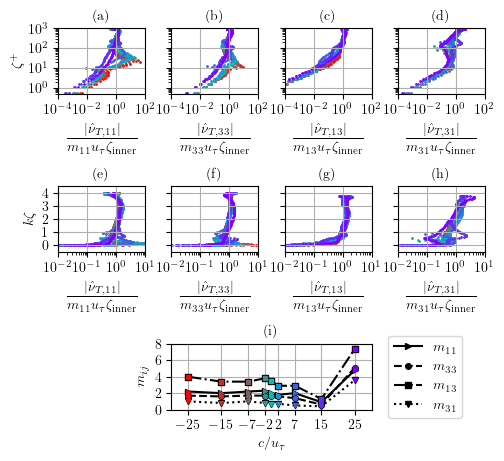

In [24]:
#Eddy viscosity from wave-induced stress normalised by inner layer depth scaling
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
plt.rcParams['text.usetex'] = True  # Enable LaTeX rendering
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' 
# Make sure these variables are defined before running:
# LES_data, nuT11_LES, nuT33_LES, nuT13_LES, nuT31_LES,
# inner_layer_depth, k_wavno, nu, ustar, c_array,
# color_array, font_size

fig = plt.figure(11, figsize=(5.5, 7))
gs = gridspec.GridSpec(nrows=4, ncols=4)
# Adjust spacing between subplots if needed
gs.update(wspace=0.3, hspace=1.4)

norm_power = 0

# ----------------- (a) Subplot -----------------
ax1 = fig.add_subplot(gs[0, 0])
nuT11_const = np.zeros((9,), dtype=float)
for num_data_select in range(9):
    arr = np.abs(LES_data[num_data_select].zw[0:-1].flatten() - 100 * nu / ustar)
    min_index = np.argmin(arr)
    nuT11_const[num_data_select] = np.round(
        np.mean(
            np.abs(nuT11_LES[min_index:-1, num_data_select]) 
            / (inner_layer_depth[num_data_select] / k_wavno)
        ), 1
    )

for num_data_select in range(9):
    ax1.scatter(
        np.abs(nuT11_LES[0:-1, num_data_select]) 
        / (nuT11_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (ustar / nu)**(1-norm_power) * LES_data[num_data_select].zw[0:-1].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,11}|}{m_{11} u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
if norm_power == 0:
    ax1.set_ylabel(r'$\zeta^+$', fontsize=font_size)
else:
    ax1.set_ylabel(r'$\zeta/\zeta_{\mathrm{inner}}$', fontsize=font_size)
ax1.set_xlim(1e-4, 1e2)
ax1.set_xticks([1e-4, 1e-2, 1, 1e2])
ax1.set_title('(a)', fontsize=font_size)
ax1.tick_params(labelsize=font_size)
if norm_power:
    ax1.set_ylabel(r'$\zeta/\zeta_{\mathrm{inner}}$', fontsize=font_size)
    ax1.set_ylim(1e-2, 1e2)
    ax1.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax1.set_ylim(5e-1, 1e3)
    ax1.set_yticks([1, 1e1, 1e2, 1e3])
ax1.grid()

# ----------------- (b) Subplot -----------------
ax2 = fig.add_subplot(gs[0, 1])
nuT33_const = np.zeros((9,), dtype=float)
for num_data_select in range(9):
    arr = np.abs(LES_data[num_data_select].zw[0:-1].flatten() - 100 * nu / ustar)
    min_index = np.argmin(arr)
    nuT33_const[num_data_select] = np.round(
        np.mean(
            np.abs(nuT33_LES[min_index:-1, num_data_select]) 
            / (inner_layer_depth[num_data_select] / k_wavno)
        ), 1
    )

for num_data_select in range(9):
    ax2.scatter(
        np.abs(nuT33_LES[0:-1, num_data_select]) 
        / (nuT33_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (ustar / nu)**(1-norm_power) * LES_data[num_data_select].zw[0:-1].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,33}|}{m_{33}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax2.set_xlim(1e-4, 1e2)
ax2.set_xticks([1e-4, 1e-2, 1, 1e2])
ax2.set_title('(b)', fontsize=font_size)
ax2.tick_params(labelsize=font_size)
ax2.set_yticklabels([])
if norm_power:
    ax2.set_ylim(1e-2, 1e2)
    ax2.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax2.set_ylim(5e-1, 1e3)
    ax2.set_yticks([1, 1e1, 1e2, 1e3])
ax2.grid()

# ----------------- (c) Subplot -----------------
ax3 = fig.add_subplot(gs[0, 2])
nuT13_const = np.zeros((9,), dtype=float)
for num_data_select in range(9):
    arr = np.abs(LES_data[num_data_select].zw[0:-1].flatten() - 100 * nu / ustar)
    min_index = np.argmin(arr)
    nuT13_const[num_data_select] = np.round(
        np.mean(
            np.abs(nuT13_LES[min_index:-1, num_data_select]) 
            / (inner_layer_depth[num_data_select] / k_wavno)
        ), 1
    )
    if num_data_select == 2:
        nuT13_const[num_data_select]=nuT13_const[num_data_select-1]
for num_data_select in range(9):
    ax3.scatter(
        np.abs(nuT13_LES[0:-30, num_data_select]) 
        / (nuT13_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (ustar / nu)**(1-norm_power) * LES_data[num_data_select].zw[0:-30].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,13}|}{m_{13}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax3.set_xlim(1e-4,1e2)
ax3.set_xticks([1e-4, 1e-2, 1, 1e2])
ax3.set_title('(c)', fontsize=font_size)
ax3.tick_params(labelsize=font_size)
ax3.set_yticklabels([])
if norm_power:
    ax3.set_ylim(1e-2, 1e2)
    ax3.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax3.set_ylim(5e-1, 1e3)
    ax3.set_yticks([1, 1e1, 1e2, 1e3])
ax3.grid()

# ----------------- (d) Subplot -----------------
ax4 = fig.add_subplot(gs[0, 3])
nuT31_const = np.zeros((9,), dtype=float)
for num_data_select in range(9):
    arr = np.abs(LES_data[num_data_select].zw[0:-1].flatten() - 100 * nu / ustar)
    min_index = np.argmin(arr)
    nuT31_const[num_data_select] = np.round(
        np.mean(
            np.abs(nuT31_LES[min_index:-1, num_data_select]) 
            / (inner_layer_depth[num_data_select] / k_wavno)
        ), 1
    )

for num_data_select in range(9):
    ax4.scatter(
        np.abs(nuT31_LES[0:-30, num_data_select]) 
        / (nuT31_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (ustar / nu)**(1-norm_power) * LES_data[num_data_select].zw[0:-30].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,31}|}{m_{31}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax4.set_xlim(1e-4,1e2)
ax4.set_xticks([1e-4, 1e-2, 1, 1e2])
ax4.set_title('(d)', fontsize=font_size)
ax4.tick_params(labelsize=font_size)
ax4.set_yticklabels([])
if norm_power:
    ax4.set_ylim(1e-2, 1e2)
    ax4.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax4.set_ylim(5e-1, 1e3)
    ax4.set_yticks([1, 1e1, 1e2, 1e3])
ax4.grid()

#######################################################################################################################
norm_power=0
# ----------------- (e) Subplot -----------------
ax5 = fig.add_subplot(gs[1, 0])
for num_data_select in range(9):
    ax5.scatter(
        np.abs(nuT11_LES[0:-1, num_data_select]) 
        / (nuT11_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (k_wavno) * LES_data[num_data_select].zw[0:-1].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax5.set_xscale('log')
ax5.set_yscale('linear')
ax5.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,11}|}{m_{11} u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
if norm_power ==0:
    ax5.set_ylabel(r'$k\zeta$', fontsize=font_size)
else:
    ax5.set_ylabel(r'$\zeta/\zeta_{\mathrm{inner}}$', fontsize=font_size)
ax5.set_xlim(1e-2, 1e1)
ax5.set_xticks([1e-2, 1e-1, 1, 1e1])
ax5.set_title('(e)', fontsize=font_size)
ax5.tick_params(labelsize=font_size)
if norm_power:
    ax5.set_ylabel(r'$\zeta/\zeta_{\mathrm{inner}}$', fontsize=font_size)
    ax5.set_ylim(1e-2, 1e2)
    ax5.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax5.set_ylim(-0.5, 4.5)
    ax5.set_yticks([0, 1, 2, 3, 4])
ax5.grid()

# ----------------- (f) Subplot -----------------
ax6 = fig.add_subplot(gs[1, 1])
for num_data_select in range(9):
    ax6.scatter(
        np.abs(nuT33_LES[0:-1, num_data_select]) 
        / (nuT33_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (k_wavno) * LES_data[num_data_select].zw[0:-1].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax6.set_xscale('log')
ax6.set_yscale('linear')
ax6.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,33}|}{m_{33}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax6.set_xlim(1e-2, 1e1)
ax6.set_xticks([1e-2, 1e-1, 1, 1e1])
ax6.set_title('(f)', fontsize=font_size)
ax6.tick_params(labelsize=font_size)
ax6.set_yticklabels([])
if norm_power:
    ax6.set_ylim(1e-2, 1e2)
    ax6.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax6.set_ylim(-0.5, 4.5)
    ax6.set_yticks([0, 1, 2, 3, 4])
ax6.grid()

# ----------------- (g) Subplot -----------------
ax7 = fig.add_subplot(gs[1, 2])
for num_data_select in range(9):
    ax7.scatter(
        np.abs(nuT13_LES[0:-30, num_data_select]) 
        / (nuT13_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (k_wavno) * LES_data[num_data_select].zw[0:-30].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1
    )

ax7.set_xscale('log')
ax7.set_yscale('linear')
ax7.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,13}|}{m_{13}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax7.set_xlim(1e-2, 1e1)
ax7.set_xticks([1e-2, 1e-1, 1, 1e1])
ax7.set_title('(g)', fontsize=font_size)
ax7.tick_params(labelsize=font_size)
ax7.set_yticklabels([])
if norm_power:
    ax7.set_ylim(1e-2, 1e2)
    ax7.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax7.set_ylim(-0.5, 4.5)
    ax7.set_yticks([0, 1, 2, 3, 4])
ax7.grid()

# ----------------- (h) Subplot -----------------
ax8 = fig.add_subplot(gs[1, 3])
ax8.grid(zorder=1)
for num_data_select in range(9):
    ax8.scatter(
        np.abs(nuT31_LES[0:-30, num_data_select]) 
        / (nuT31_const[num_data_select] * inner_layer_depth[num_data_select] / k_wavno),
        (k_wavno) * LES_data[num_data_select].zw[0:-30].flatten() 
        / inner_layer_depth[num_data_select]**norm_power,
        color=color_array[num_data_select], marker='o', s=1,zorder=1
    )

ax8.set_xscale('log')
ax8.set_yscale('linear')
ax8.set_xlabel(r'$\dfrac{|\hat{\nu}_{T,31}|}{m_{31}u_\tau \zeta_{\mathrm{inner}}}$', fontsize=font_size)
ax8.set_xlim(1e-2, 1e1)
ax8.set_xticks([1e-2, 1e-1, 1, 1e1])
ax8.set_title('(h)', fontsize=font_size)
ax8.tick_params(labelsize=font_size)
ax8.set_yticklabels([])
if norm_power:
    ax8.set_ylim(1e-2, 1e2)
    ax8.set_yticks([1e-2, 1e-1, 1, 1e1, 1e2])
else:
    ax8.set_ylim(-0.5, 4.5)
    ax8.set_yticks([0, 1, 2, 3, 4])

# ----------------- (i) Expanded Plot -----------------
ax9 = fig.add_subplot(gs[2, 1:3])  # row=2, columns=1 and 2
ax9.plot(c_array[:-1], nuT11_const, 'k', label=r'$m_{11}$',marker='>',zorder=2,markersize=4)
ax9.plot(c_array[:-1], nuT33_const, 'k--', label=r'$m_{33}$',marker='o',zorder=2,markersize=4)
ax9.plot(c_array[:-1], nuT13_const, 'k-.', label=r'$m_{13}$',marker='s',zorder=2,markersize=4)
ax9.plot(c_array[:-1], nuT31_const, 'k:', label=r'$m_{31}$',marker='v',zorder=2,markersize=4)

for num_data_select in range(9):
    ax9.scatter(
        c_array[num_data_select], nuT11_const[num_data_select],
        marker='>', s=8, color=color_array[num_data_select],zorder=3
    )
    ax9.scatter(
        c_array[num_data_select], nuT33_const[num_data_select],
        marker='o', s=8, color=color_array[num_data_select],zorder=3
    )
    ax9.scatter(
        c_array[num_data_select], nuT13_const[num_data_select],
        marker='s', s=8, color=color_array[num_data_select],zorder=3
    )
    ax9.scatter(
        c_array[num_data_select], nuT31_const[num_data_select],
        marker='v', s=8, color=color_array[num_data_select],zorder=3
    )

ax9.set_ylim(0, 8)
ax9.set_yticks([0, 2, 4, 6, 8])
ax9.set_xlim(-30, 30)
ax9.set_xticks([-25, -15, -7, -2, 2, 7, 15, 25])
ax9.set_xlabel(r'$c/u_\tau$', fontsize=font_size)
ax9.set_ylabel(r'$m_{ij}$', fontsize=font_size)
ax9.set_title('(i)', fontsize=font_size)
ax9.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(zorder=1)
plt.savefig(
    'nuTij_magnitude_profile_scaling.png',
    format='png',
    dpi=600,
    bbox_inches='tight',
    transparent=False,
    pad_inches=0.01
)
plt.show()



0 0 32.76273104531697 0.18823914520877874
0 1 32.932917144923366 0.23872869497435556
1 0 33.27119353531786 0.1892658688572014
1 1 33.594437254036016 0.254058056323948
2 0 33.92451991464729 0.18249802004140042
2 1 34.48985358382805 0.25328283084214703
3 0 35.082392630291125 0.17160970720508903
3 1 35.88933083381035 0.24458016205324784
4 0 55.68697533788989 0.17724861823405622
4 1 56.56903326658197 0.25350083028648757
5 0 37.325581844400034 0.2886859068863663
5 1 37.4342048964832 0.2815323673069042
6 0 43.51819102991674 0.6147321267233282
6 1 41.22716920461964 0.4097325339823856
7 0 71.04087274540701 0.8271341532566555
7 1 41.442071070576354 0.3265571281502984
8 0 37.19742822680483 0.3597398801379278
8 1 36.41422845124963 0.3134844085115395


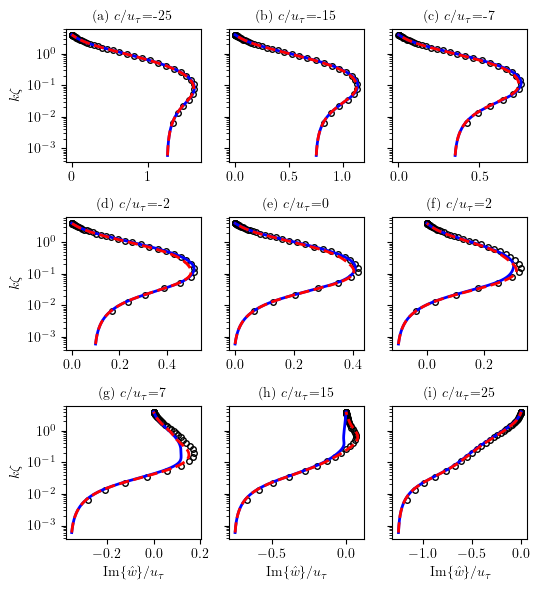

In [25]:
plt.figure(11,figsize=(5.5,6))
font_size=10
for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)

    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    plt.semilogy(w_LES_data[16,::3].imag,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label='LES',markersize=4)
    
    for n in n_num_array_index:
        w_imag_interp = CubicSpline(LES_data[num_data_select].zw[0:-1].flatten(),w_LES_data[16,0:-1].imag)
        w_imag_interp_profile = w_imag_interp(z)
        mape_imw = mape(w_imag_interp_profile,Imw[:,n,num_data_select])
        norm_imw = np.linalg.norm(w_imag_interp_profile-Imw[:,n,num_data_select])
        
        print(num_data_select,n,mape_imw,norm_imw)
        plt.semilogy(Imw[:,n,num_data_select].real, k_wavno*z, color_array_plot_Im[n], 
             linewidth=2, label=rf'$\epsilon_{{\mathrm{{Im}}\{{\hat{{w}}\}}}} = {mape_imw:.0f}$')

        #plt.semilogy(w_imag_interp_profile ,k_wavno*z,color_array_plot_Im[n],linewidth=2)
   
    if num_data_select >= 6:  
        ax1.set_xlabel(r'Im$\{\hat{w}\}/u_\tau$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)    #plt.legend(loc='lower right',fontsize=font_size)

plt.savefig('Imw_profile_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

0 0 92.1724007676987 33.63418545394084
0 1 92.32263679030885 33.645884336974085
0 2 91.01364934966392 33.559686961852265
0 3 88.88800014300452 33.52258244902632
0 4 91.15289284455113 33.569140302440125
3 0 99.95141828719952 40.42758652088888
3 1 99.48259915942546 40.25764840987049
3 2 101.0322083352641 40.852619105209534
3 3 101.17784195081035 40.8268183471301
3 4 101.03252815821475 40.82580783260242
5 0 98.05914884033405 7.414979137026465
5 1 96.03626843528129 7.024406367214222
5 2 102.30220342202028 8.245904590987477
5 3 102.46295366710069 8.153915090760943
5 4 102.24318630644937 8.20117210858403
8 0 101.54725341381533 4.829074110965536
8 1 100.4497216708978 4.751505862817531
8 2 97.51527329496601 4.30395071327256
8 3 97.26867382150093 4.438531470337218
8 4 97.98768256771136 4.327949283356279


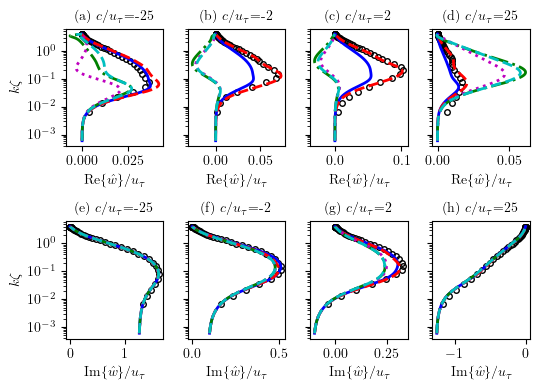

In [26]:
plt.figure(11,figsize=(5.5,4))
font_size=10
counter=1
for num_data_select in [0,3,5,8]:
    ax1=plt.subplot(2,4,counter)


    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    plt.semilogy(w_LES_data[16,::3].real,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label='LES',markersize=4)
    
    for n in [0,1,2,3,4]:# n_num_array_index:
        w_real_interp = CubicSpline(LES_data[num_data_select].zw[0:-1].flatten(),w_LES_data[16,0:-1].real)
        w_real_interp_profile = w_imag_interp(z)
        mape_Rew = mape(w_real_interp_profile,Rew[:,n,num_data_select])
        norm_Rew = np.linalg.norm(w_real_interp_profile-Rew[:,n,num_data_select])
        
        print(num_data_select,n,mape_Rew,norm_Rew)
        
        
        plt.semilogy(Rew[:,n,num_data_select].real, k_wavno*z, color_array_plot_Im[n], 
             linewidth=2, label=rf'$\epsilon_{{\mathrm{{Re}}\{{\hat{{w}}\}}}} = {mape_imw:.0f}$')
        ax1.set_xlabel(r'Re$\{\hat{w}\}/u_\tau$',fontsize=font_size)
    
    if counter == 1 or counter == 5:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + counter-1)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)

    ax1=plt.subplot(2,4,counter+4)

    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    plt.semilogy(w_LES_data[16,::3].imag,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label='LES',markersize=4)
    
    for n in [0,1,2,3,4]:# n_num_array_index:
        w_imag_interp = CubicSpline(LES_data[num_data_select].zw[0:-1].flatten(),w_LES_data[16,0:-1].imag)
        w_imag_interp_profile = w_imag_interp(z)
        mape_imw = mape(w_imag_interp_profile,Imw[:,n,num_data_select])

        plt.semilogy(Imw[:,n,num_data_select].real, k_wavno*z, color_array_plot_Im[n], 
             linewidth=2, label=rf'$\epsilon_{{\mathrm{{Im}}\{{\hat{{w}}\}}}} = {mape_imw:.0f}$')
        ax1.set_xlabel(r'Im$\{\hat{w}\}/u_\tau$',fontsize=font_size)
    
    
    if counter == 1 or counter == 5:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + counter-1+4)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)    #plt.legend(loc='lower right',fontsize=font_size)
    counter=counter+1
plt.savefig('Rew_Imw_profile_nuT_2x4.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

0 0 33.63418545394084
0 1 33.645884336974085
1 0 33.616473852204315
1 1 33.63977035170749
2 0 33.60877944401093
2 1 33.65704533364323
3 0 33.615037227020366
3 1 33.7029569060132
4 0 33.62416987280416
4 1 33.73420191154376
5 0 33.64343438025649
5 1 33.76396125023188
6 0 33.82440240552709
6 1 33.806797438487436
7 0 33.53863738057168
7 1 33.57571110565759
8 0 33.51314018675587
8 1 33.53579704311275


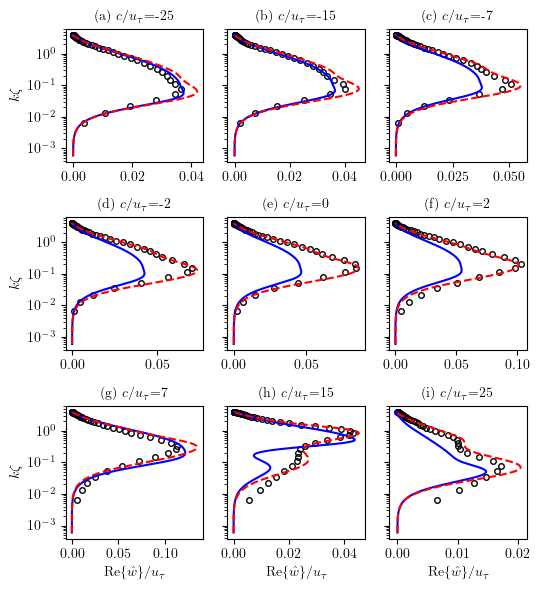

In [27]:
plt.figure(11,figsize=(5.5,6))

for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)
    w_LES_data = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    plt.semilogy(w_LES_data[16,::3].real,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label=r'$\Re\{\hat{w}\}$ (LES)',markersize=4)
    #plt.semilogy(w_LES_data[16,::3].real,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none')
    
    for n in n_num_array_index:
        w_real_interp = CubicSpline(LES_data[num_data_select].zw[0:-1].flatten(),w_LES_data[16,0:-1].real)
        w_real_interp_profile = w_imag_interp(z)
        mape_Rew = mape(w_real_interp_profile,Rew[:,n,num_data_select])
        norm_Rew = np.linalg.norm(w_real_interp_profile-Rew[:,n,num_data_select])
        
        print(num_data_select,n,norm_Rew)
        
        plt.semilogy(Rew[:,n,num_data_select].real,k_wavno*z,color_array_plot_Im[n])

    if num_data_select >= 6:  
        ax1.set_xlabel(r'Re$\{\hat{w}\}/u_\tau$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)

plt.savefig('Rew_profile_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()


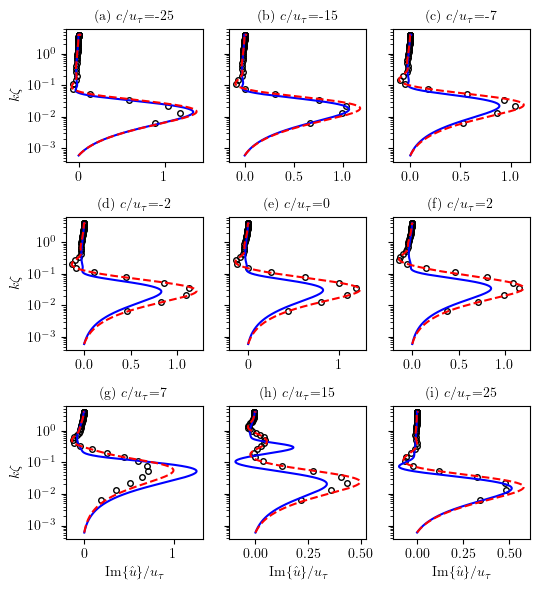

In [28]:
plt.figure(11,figsize=(5.5,6))

for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)
    
    u_LES_data = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    plt.semilogy(u_LES_data[16,::3].imag,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label='$\Im\{\hat{w}\}$ (LES)',markersize=4)
    
    
    for n in n_num_array_index:
        plt.semilogy(Imu[:,n,num_data_select].real,k_wavno*z,color_array_plot_Im[n],label='$\Im\{\hat{w}\}$ (Model)')
    
    
    
    if num_data_select >= 6:  
        ax1.set_xlabel(r'Im$\{\hat{u}\}/u_\tau$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)

plt.savefig('Imu_profile_apriori.png',format='png',dpi=600,bbox_inches='tight', \
            transparent=False,pad_inches=0.01)
plt.show()   


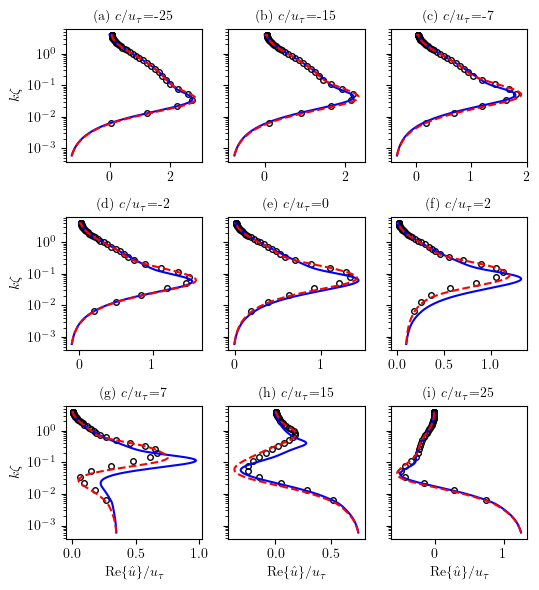

In [29]:
plt.figure(11,figsize=(5.5,6))

for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)
    
    u_LES_data = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    plt.semilogy(u_LES_data[16,::3].real,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',label='$\Im\{\hat{w}\}$ (LES)',markersize=4)
    
    
    for n in n_num_array_index:
        plt.semilogy(Reu[:,n,num_data_select].real,k_wavno*z,color_array_plot_Im[n],label='$\Im\{\hat{w}\}$ (Model)')
    
    
    
    if num_data_select >= 6:  
        ax1.set_xlabel(r'Re$\{\hat{u}\}/u_\tau$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)

plt.savefig('Reu_profile_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

#plt.savefig('Reu_profile_WRLES_vs_Model.png',format='png',dpi=600,bbox_inches='tight',
#                transparent=False,pad_inches=0.01)

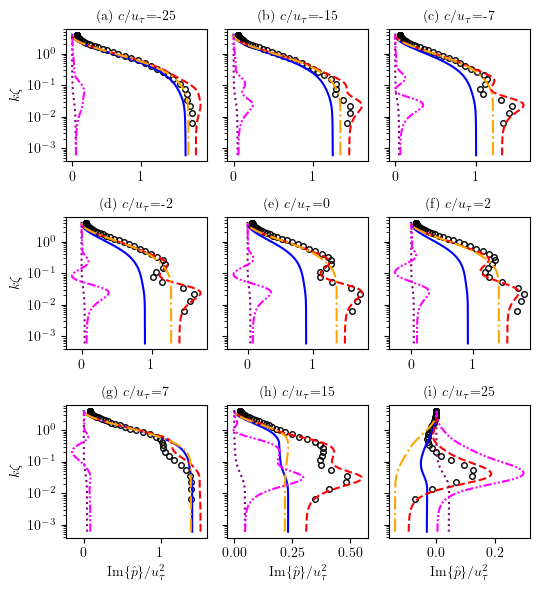

In [30]:
plt.figure(11,figsize=(5.5,6))

for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)
    
    p_LES_data = np.fft.fft(LES_data[num_data_select].p_w,axis=0,norm='forward')
    #plt.semilogy(p_LES_data[16,:].real,k*LES_data[num_data_select].zw,'ko',markerfacecolor='none')
    plt.semilogy(p_LES_data[16,::3].imag,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',markersize=4)
   
    for n in [0,1]:#n_num_array_index:
        if n==0:
            plt.semilogy(Imp[:,3,n,num_data_select].real,k_wavno*z,color='b')
        if n==1:
            plt.semilogy(Imp[:,3,n,num_data_select].real,k_wavno*z,color='red',linestyle='--')
            plt.semilogy(Imp[:,0,n,num_data_select].real,k_wavno*z,color='orange',linestyle='-.')
            plt.semilogy(Imp[:,1,n,num_data_select].real,k_wavno*z,color='purple',linestyle=':')
            plt.semilogy(Imp[:,2,n,num_data_select].real,k_wavno*z,color='magenta',dashes=[4, 1, 1, 1, 1, 1])
    if num_data_select >= 6:  
        ax1.set_xlabel(r'Im$\{\hat{p}\}/u_\tau^2$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)
plt.savefig('Imp_profile_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()
#plt.savefig('Imp_profile_WRLES_vs_Model.png',format='png',dpi=600,bbox_inches='tight',
#                transparent=False,pad_inches=0.01)

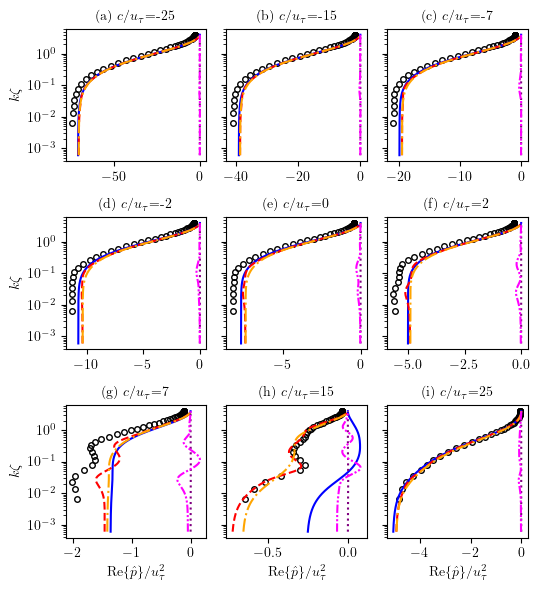

In [31]:
plt.figure(11,figsize=(5.5,6))

for num_data_select in range(9):
    ax1=plt.subplot(3,3,num_data_select+1)
    
    p_LES_data = np.fft.fft(LES_data[num_data_select].p_w,axis=0,norm='forward')
    plt.semilogy(p_LES_data[16,::3].real,k_wavno*LES_data[num_data_select].zw[::3],'ko',markerfacecolor='none',markersize=4)

    for n in [0,1]:#n_num_array_index:
        if n==0:
            plt.semilogy(Rep[:,3,n,num_data_select].real,k_wavno*z,color='b')
        if n==1:
            plt.semilogy(Rep[:,3,n,num_data_select].real,k_wavno*z,color='r',linestyle='--')
            plt.semilogy(Rep[:,0,n,num_data_select].real,k_wavno*z,color='orange',linestyle='-.')
            plt.semilogy(Rep[:,1,n,num_data_select].real,k_wavno*z,color='purple',linestyle=':')
            plt.semilogy(Rep[:,2,n,num_data_select].real,k_wavno*z,color='magenta',dashes=[4, 1, 1, 1, 1, 1])
    if num_data_select >= 6:  
        ax1.set_xlabel(r'Re$\{\hat{p}\}/u_\tau^2$',fontsize=font_size)
    if num_data_select == 0 or num_data_select == 3 or num_data_select == 6:  
        ax1.set_ylabel(r'$k\zeta$',fontsize=font_size)
    else:
        ax1.set_yticklabels('')
    ax1.tick_params(labelsize=font_size)
    ax1.set_title(f'({chr(97 + num_data_select)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=font_size)
    #plt.grid(True)
plt.savefig('Rep_profile_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()


In [32]:
wavelength=2*np.pi/k_wavno
arg=np.abs(x_LES-1*wavelength)
index_min=np.argmin(arg)+1
print(index_min,x_LES[index_min]/wavelength)

55 1.0196987253765932


\begin{align*}
F_p=\frac{1}{\lambda}\int_{0}^{\lambda}\frac{\widetilde{p}}{\rho_a u_\tau^2}\frac{d\widetilde{\eta}}{dx} \ dx
\end{align*}

\begin{align*}
    F_p&=\frac{ak\text{Im}\{\hat{p}(\zeta=0)\}}{2\pi \rho_a u_\tau^2}. 
\end{align*}

In [48]:
Fp=np.zeros((9,6),dtype='float')
for num_data_select in range(9):
    
    p_hat_LES = np.fft.fft(LES_data[num_data_select].p_w,axis=0,norm='forward')
    Fp[num_data_select,0] = a*k_wavno*p_hat_LES[16,0].imag#LES
    Fp[num_data_select,1] = a*k_wavno*Imp[0,3,1,num_data_select]#Turb curv model
    Fp[num_data_select,2] = a*k_wavno*Imp[0,3,0,num_data_select]#Visc curv model
    Fp[num_data_select,3] = a*k_wavno*Imp[0,3,2,num_data_select]#Turb Curv with modeled-1 stress
    Fp[num_data_select,4] = a*k_wavno*Imp[0,3,3,num_data_select]#Turb Curv with modeled-2 stress
    Fp[num_data_select,5] = a*k_wavno*Imp[0,3,4,num_data_select]#Turb Curv with modeled-3 stress
    

/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/4148169819.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  Fp[num_data_select,1] = a*k_wavno*Imp[0,3,1,num_data_select]#Turb curv model
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/4148169819.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  Fp[num_data_select,2] = a*k_wavno*Imp[0,3,0,num_data_select]#Visc curv model
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/4148169819.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  Fp[num_data_select,3] = a*k_wavno*Imp[0,3,2,num_data_select]#Turb Curv with modeled-1 stress
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/4148169819.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  Fp[num_data_select,4] = a*k_wavno*Imp[0,3,3,num_data_select]#Turb Curv with modeled-2 stress
/var/folders/b3/r_0g9bm1

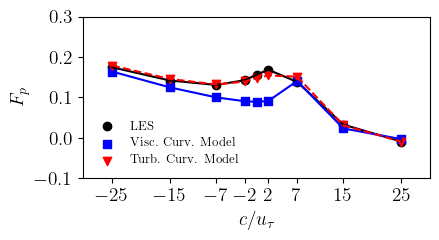

In [49]:
plt.figure(11,figsize=(4.5,2.5))
ax1=plt.subplot(1,1,1)


plt.scatter(c_array[0:-1],Fp[:,0],color='k',label='LES')
plt.scatter(c_array[0:-1],Fp[:,2],color='b',marker='s',label='Visc. Curv. Model')
plt.scatter(c_array[0:-1],Fp[:,1],color='r',marker='v',label='Turb. Curv. Model')

plt.legend(frameon=False,fontsize=9,loc='lower left')

plt.plot(c_array[0:-1],Fp[:,0],color='k')
plt.plot(c_array[0:-1],Fp[:,2],color='b',linestyle='-')
plt.plot(c_array[0:-1],Fp[:,1],color='r',linestyle='--')


ax1.set_xlabel(r'$c/u_\tau$',fontsize=14)
ax1.set_ylim(-0.1,0.3)
ax1.set_xlim(-30,30)
ax1.set_xticks([-25, -15, -7, -2, 2, 7, 15, 25])
#ax1.set_title(f'$c/u_*$={c_array[num_data_select]}', fontsize=15)
ax1.set_ylabel(r'$F_p$',fontsize=14)
ax1.tick_params(labelsize=14)


plt.savefig('form_drag_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()

/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


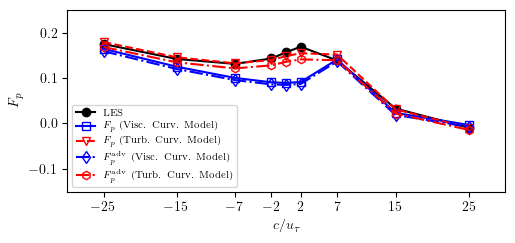

In [50]:
#Form drag LES
plt.figure(11,figsize=(5.25,4.5))
ax1=plt.subplot(2,1,1)
Fp_error=np.zeros((4,),dtype=float)
Fp_error[0]= mape(Fp[:, 0], Fp[:, 2])  # Visc error
Fp_error[1]= mape(Fp[:, 0], Fp[:, 1])  # Turb error
Fp_error[2]= mape(Fp[:, 0], a*k_wavno*Imp[0,0,0,:].real)  # adv-Visc error
Fp_error[3]= mape(Fp[:, 0], a*k_wavno*Imp[0,0,1,:].real)  # adv-turb error

plt.plot(c_array[0:-1],Fp[:,0],color='k',marker='o',label='LES',zorder=1)
plt.plot(c_array[0:-1],Fp[:,2], color='b', marker='s', markerfacecolor='none',label=r'$F_p$ (Visc. Curv. Model)', zorder=2, linestyle='-')
plt.plot(c_array[0:-1],Fp[:,1],color='r',marker='v',markerfacecolor='none',label=r'$F_p$ (Turb. Curv. Model)',zorder=2,linestyle='--')#Turb model
plt.plot(c_array[0:-1],a*k_wavno*Imp[0,0,0,:],color='b',marker='d',markerfacecolor='none',label=r'$F_p^{\mathrm{adv}}$ (Visc. Curv. Model)',zorder=2,linestyle='-.')#adv-Visc model
plt.plot(c_array[0:-1],a*k_wavno*Imp[0,0,1,:],color='r',marker='h',markerfacecolor='none',label=r'$F_p^{\mathrm{adv}}$ (Turb. Curv. Model)',zorder=2,linestyle='-.')#adv-Turb model


ax1.set_xlabel(r'$c/u_\tau$',fontsize=10)
ax1.set_ylim(-0.15,0.25)
ax1.set_xlim(-30,30)
ax1.set_xticks([-25, -15, -7, -2, 2, 7, 15, 25])
plt.legend(fontsize=7)
ax1.set_ylabel(r'$F_p$',fontsize=10)
ax1.tick_params(labelsize=10)

plt.savefig('form_drag_apriori.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)
plt.show()

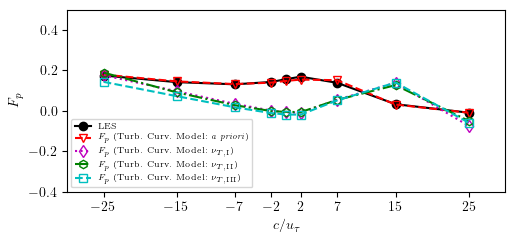

In [51]:
#Form drag: LES vs Model
plt.figure(11,figsize=(5.25,4.5))
ax1=plt.subplot(2,1,1)

plt.plot(c_array[0:-1],Fp[:,0],color='k',marker='o',label='LES',zorder=1)
plt.plot(c_array[0:-1],Fp[:,1],color='r',marker='v',markerfacecolor='none',label=r'$F_p$ (Turb. Curv. Model: \textit{a priori})'     ,zorder=2,linestyle='--')#Turb model (a priori)
plt.plot(c_array[0:-1],Fp[:,3],color='m',marker='d',markerfacecolor='none',label=r'$F_p$ (Turb. Curv. Model: $\nu_{T,\mathrm{I}}$)'  ,zorder=2,linestyle=':' )#Turb model (nu_T,I)
plt.plot(c_array[0:-1],Fp[:,4],color='g',marker='h',markerfacecolor='none',label=r'$F_p$ (Turb. Curv. Model: $\nu_{T,\mathrm{II}}$)' ,zorder=2,linestyle='-.')#Turb model (nu_T,II)
plt.plot(c_array[0:-1],Fp[:,5],color='c',marker='s',markerfacecolor='none',label=r'$F_p$ (Turb. Curv. Model: $\nu_{T,\mathrm{III}}$)',zorder=2,linestyle='--')#Turb model (nu_T,III)


ax1.set_xlabel(r'$c/u_\tau$',fontsize=10)
ax1.set_ylim(-0.4,0.5)
ax1.set_xlim(-30,30)
ax1.set_xticks([-25, -15, -7, -2, 2, 7, 15, 25])
plt.legend(fontsize=6)
ax1.set_ylabel(r'$F_p$',fontsize=10)
ax1.tick_params(labelsize=10)


plt.savefig('form_drag_LES_vs_Model.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()

In [37]:
plt.figure(18,figsize=(5.5,5))
taup13_mean_surf=np.zeros((9,),dtype=float)
for num_data_select in range(9):
   taup13_mean_surf[num_data_select] = LES_data[num_data_select].taup_13_mean[0]

<Figure size 550x500 with 0 Axes>

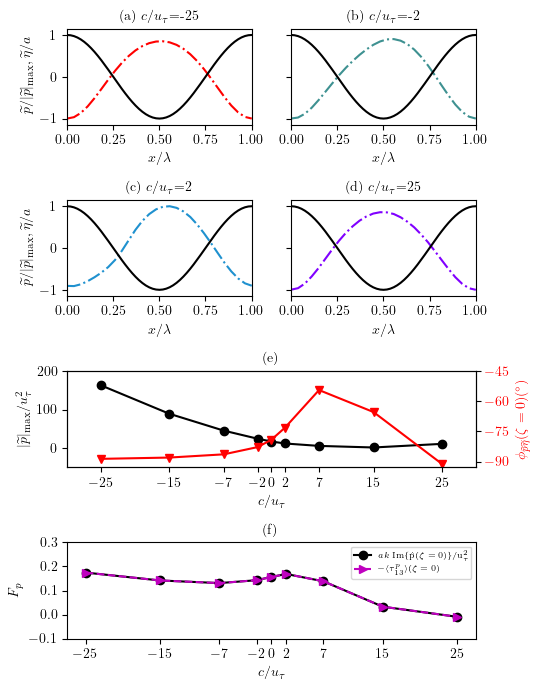

In [38]:
#Pressure on wave surface
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Assuming you have LES_data, x, k_wavno, c_array, color_array, Rep, Imp, n_num_array_index, y, a, color_array_plot defined

plt.figure(11, figsize=(5.5, 7))
wavelength = 2 * np.pi / k_wavno
p_abs_max = np.zeros((9,), dtype='float')
p_real_max = np.zeros((9,), dtype='float')
p_imag_max = np.zeros((9,), dtype='float')
p_phase    = np.zeros((9,), dtype='float')
gs = gridspec.GridSpec(4, 2)  # Create a 5x3 grid

counter=0
for num_data_select in range(9):
    ax1 = plt.subplot(gs[counter])  # Place subplots in the first 9 grid positions
    phase_diff = np.pi / 2 * 0
    vmin = np.abs(LES_data[num_data_select].p_w_surf[0:index_min] - np.mean(LES_data[num_data_select].p_w_surf[0:index_min])).min()
    vmax = np.abs(LES_data[num_data_select].p_w_surf[0:index_min] - np.mean(LES_data[num_data_select].p_w_surf[0:index_min])).max()
    p_abs_max[num_data_select] = vmax

    
    p_hat_surf = np.fft.fft(LES_data[num_data_select].p_w_surf - np.mean(LES_data[num_data_select].p_w_surf),axis=0,norm='forward')
    p_real_max[num_data_select] = p_hat_surf[16].real
    p_imag_max[num_data_select] = p_hat_surf[16].imag
    p_phase[num_data_select]    = np.arctan2(p_hat_surf[16].real,p_hat_surf[16].imag)*180/np.pi


for num_data_select in [0,3,5,8]:
    ax1 = plt.subplot(gs[counter])  # Place subplots in the first 9 grid positions
    phase_diff = np.pi / 2 * 0
    vmin = np.abs(LES_data[num_data_select].p_w_surf[0:index_min] - np.mean(LES_data[num_data_select].p_w_surf[0:index_min])).min()
    vmax = np.abs(LES_data[num_data_select].p_w_surf[0:index_min] - np.mean(LES_data[num_data_select].p_w_surf[0:index_min])).max()
    ax1.plot(x[0:index_min:2] / wavelength, (LES_data[num_data_select].p_w_surf[0:index_min:2] - np.mean(LES_data[num_data_select].p_w_surf[0:index_min])) / vmax, color=color_array[num_data_select], label='LES', markersize=5, linestyle='-.')
    #for n in n_num_array_index:
    #    ax1.plot(x / wavelength, (2 * Rep[0, 3, n, num_data_select] * np.cos(k_wavno * x) * 1 - 1 * 2 * Imp[0, 3, n, num_data_select] * np.sin(k_wavno * x)) / vmax, color=color_array_plot[n], label=r'$2Re\{\hat{p}\}\cos (k\xi)-2Im\{\hat{p}\}\sin (k\xi)$ (TurbCurv)', linewidth=2)
    ax1.plot(x_LES / wavelength, y / a, 'k')

    ax1.set_title(f'({chr(97 + counter)}) $c/u_\\tau$={c_array[num_data_select]}', fontsize=10)
    ax1.set_ylim(-1.15, 1.15)
    if num_data_select == 0 or num_data_select == 5:
        ax1.set_ylabel(r'$\widetilde{p}/|\widetilde{p}|_{\mathrm{max}}, \widetilde{\eta}/a$', fontsize=10)
        ax1.set_yticks([-1, 0, 1])
    else:
        #ax1.set_ylabel(r'$\widetilde{p}/|\widetilde{p}|_{\mathrm{max}}, \widetilde{\eta}/a$', fontsize=10)
        ax1.set_yticklabels([])
    ax1.set_xlabel(r'$x/\lambda$', fontsize=10)
    ax1.tick_params(labelsize=10)
    ax1.set_xlim(0, 1)
    counter=counter+1
# Place the extended subplot
ax1 = plt.subplot(gs[2, 0:]) # Place in the 11th grid position, and extend to the 12th position
plt.plot(c_array[0:-1],p_abs_max,'k',marker='o',label=r'$|\widetilde{p}_{\mathrm{LES}}|$')
#plt.plot(c_array[0:-1],p_real_max,'r',marker='v',label=r'$\rm{Re}\{p_{\mathrm{LES}}\}$')
#plt.plot(c_array[0:-1],p_imag_max,'b',marker='s',label=r'$\rm{Im}\{p_{\mathrm{LES}}\}$')
ax2 = ax1.twinx()
ax2.plot(c_array[0:-1], p_phase, 'r', marker='v', label=r'$\mathrm{Re}\{p_{\mathrm{LES}}\}$')
#ax2.plot(c_array[0:-1], p_imag_max, 'b', marker='s', label=r'$\mathrm{Im}\{p_{\mathrm{LES}}\}$')
ax2.set_ylabel(r'$\phi_{\widetilde{p}\widetilde{\eta}}(\zeta=0) (^\circ)$', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_yticks([-45, -60,-75, -90])
    #for num_data_select in range(9):
#    ax1.scatter(c_array[num_data_select], p_abs_max[num_data_select], marker='o', color='color_array[num_data_select]',zorder=2)
#plt.legend()
ax1.set_xlim(-30, 30)
ax1.set_ylim(-50, 200)
ax1.set_yticks([0, 100, 200])
ax1.set_title(r'(e)',fontsize=font_size)
ax1.set_xticks([-25,-15, -7,-2,0,2, 7,15, 25])
ax1.set_ylabel(r'$|\widetilde{p}|_{\mathrm{max}}/u_\tau^2$', fontsize=10)
ax1.set_xlabel(r'$c/u_\tau$', fontsize=10)

# Place the extended subplot
ax1 = plt.subplot(gs[3, 0:]) # Place in the 11th grid position, and extend to the 12th position
plt.plot(c_array[0:-1],Fp[:,0],color='k',marker='o',label=r'$ak \ \rm{Im}\{\hat{p}(\zeta=0)\}/u_\tau^2$',zorder=1)
#for num_data_select in range(9):
#    plt.scatter(c_array[num_data_select],Fp[num_data_select,0],color=color_array[num_data_select],zorder=2)
plt.plot(c_array[0:-1],-taup13_mean_surf[:],linestyle='--',color='m',marker='>',markerfacecolor='m',label=r'$-\langle\tau_{13}^p\rangle(\zeta=0)$',zorder=2)
    

#plt.scatter(c_array[0:-1],Fp[:,0],color='k',label='LES')
#plt.scatter(c_array[0:-1],Fp[:,1],color='r',marker='v',label='Turb. Curv. (\emph{apriori})')
#plt.scatter(c_array[0:-1],Fp[:,2],color='b',marker='s',label='Visc. Curv.')
#plt.scatter(c_array[0:-1],-taup13_mean_surf[:],color='m',marker='>',label=r'$\langle\tau_{13}^p\rangle(\zeta=0)$')
plt.legend(fontsize=6)
plt.ylim(-0.1,0.3)
ax1.set_xticks([-25,-15, -7,-2,0,2, 7,15, 25])
ax1.set_yticks([-0.1,0,0.1,0.2,0.3])
ax1.set_title(r'(f)',fontsize=font_size)
ax1.set_ylabel(r'$F_p$', fontsize=10)
ax1.set_xlabel(r'$c/u_\tau$', fontsize=10)

#plt.tight_layout() # This is necessary so the plots don't overlap.

plt.savefig('p_surface_form_drag_LES.png', format='png', dpi=600, bbox_inches='tight', transparent=False, pad_inches=0.01)
plt.show()

-25 uc -5.594524112190065 5.666127132052658
-25 wc -3.245338120350835 3.279109722616849
-25 pw -166.15354585266635 135.8492383137239
-2 uc -3.6054072267725044 3.3400415051827945
-2 wc -0.9860953990419276 1.1288509151295663
-2 pw -24.829699425569125 21.600940587739984
2 uc -3.0559643998703354 2.881517142620037
2 wc -0.7152399262796745 0.7271477806800491
2 pw -11.22369269952664 11.870861973664015
25 uc -2.501930526946932 2.4887906175115506
25 wc -2.4957703956781763 2.4957703956781754
25 pw -11.262303992188233 9.283150947223648


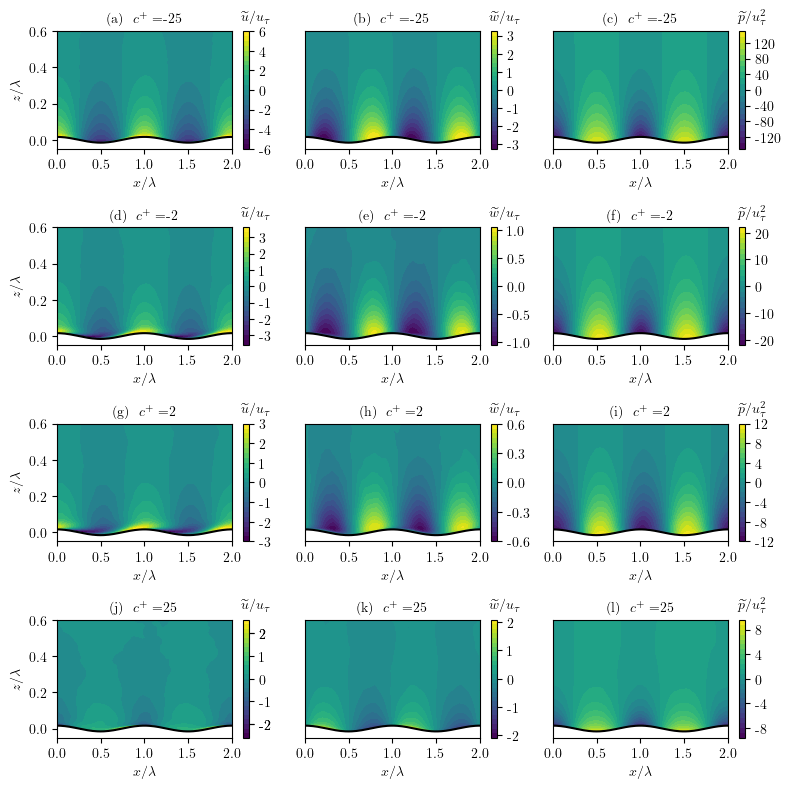

In [39]:
from matplotlib.colors import Normalize
plt.figure(11, figsize=(8,8))
font_size=10
counter = 1
num_levels = 25
wavelength = 2*np.pi/k_wavno
for num_data_select in [0,3,5,8]:#[1,2,6,7]:#
    z_phys_LES = np.zeros((Nx, Nz), dtype='float')
    x_phys_LES = np.zeros((Nx, Nz), dtype='float')
    
    for i in range(Nx):
        zeta_LES = LES_data[num_data_select].zw.flatten()
        z_phys_LES[i, :] = zeta_LES - (zeta_LES/zi - 1) * a * np.cos(k_wavno * x_LES[i])
        x_phys_LES[i, :] = x_LES[i]

    # u subplot
    ax1 = plt.subplot(4, 3, counter)
    uw = LES_data[num_data_select].u_w
    vmax = np.max(uw)
    vmin = np.min(uw)
    print(c_array[num_data_select],'uc',vmin,vmax)

    abs_limit = min(abs(vmin), abs(vmax))
    vmin = -abs_limit
    vmax = abs_limit

    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
    mask = (uw > vmin) & (uw < vmax)
    
    c = plt.contourf(x_phys_LES/wavelength, z_phys_LES/wavelength, LES_data[num_data_select].u_w*mask , num_levels, cmap='viridis',norm=norm)
    c1 = plt.contourf(x_phys_LES/wavelength, z_phys_LES/wavelength, LES_data[num_data_select].u_w, num_levels, cmap='viridis',norm=norm)
    
    plt.plot(x_LES/wavelength, a*np.cos(k_wavno*x_LES)/wavelength, 'k')
    #plt.title(r'$c/u_*=$' + f'{c_array[num_data_select]:.2f} (Model)', fontsize=15)
    plt.title(r'(' + chr(97 + counter - 1) + r') \ $c^+=$' + f'{c_array[num_data_select]:.0f}', fontsize=font_size)
    #quiver plot
    step = 6
    x_quiver = x_phys_LES[::step, ::step] / wavelength
    z_quiver = z_phys_LES[::step, ::step] / wavelength
    u_quiver = LES_data[num_data_select].u_w[::step, ::step]
    w_quiver = LES_data[num_data_select].w[::step, ::step]
    
    #plt.quiver(x_quiver, z_quiver, u_quiver, 0*w_quiver,scale=70)
    cbar = plt.colorbar(c)
    v_mid= (vmin+vmax)/2
    ticks =[vmin,(v_mid+vmin)/2,(vmin+vmax)/2,(v_mid+vmax)/2,vmax] #np.linspace(-vmax,vmax, num=5)
    ticks = np.round(np.linspace(-vmax,vmax, num=7))
    
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{tick:.0f}" for tick in ticks])
    cbar.ax.tick_params(labelsize=font_size)  # Set colorbar tick font size
    #cbar.ax.set_ylabel(r'$\widetilde{w}$', fontsize=15)

    
    plt.text(2.1, 0.66, r'$\widetilde{u}/u_\tau$', fontsize=font_size, color='black')

    plt.xlim(0, 2)
    plt.ylim(-0.05, 0.6)
    plt.xlabel(r'$x/\lambda$', fontsize=font_size)
    plt.ylabel(r'$z/\lambda$', fontsize=font_size)

    plt.xticks(np.arange(0,2.5,0.5) ,fontsize=font_size)
    plt.yticks(fontsize=font_size)

    ####################################################################################################################################################################################

    # w subplot
    ax1 = plt.subplot(4, 3, counter + 1)
    wc = LES_data[num_data_select].w[:,:-1]
    vmax = np.max(wc)
    vmin = np.min(wc)
    print(c_array[num_data_select],'wc',vmin,vmax)
    abs_limit = min(abs(vmin), abs(vmax))
    vmin = -abs_limit
    vmax = abs_limit

    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
    mask = (wc > vmin) & (wc < vmax)
    
    #c = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].w[:, :-1]*mask, num_levels, cmap='viridis')
    if num_data_select==3:
        c  = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].w[:, :-1]*mask, num_levels, cmap='viridis')
        c1 = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].w[:, :-1], num_levels, cmap='viridis')
        
    else:
        c = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].w[:, :-1]*mask, num_levels, cmap='viridis')
        c1   = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].w[:, :-1], num_levels, cmap='viridis')
        
    plt.plot(x_LES/wavelength, a*np.cos(k_wavno*x_LES)/wavelength, 'k')
    #plt.title(r'$c/u_*=$' + f'{c_array[num_data_select]:.2f} (LES)', fontsize=15)
    plt.title(r'(' + chr(97 + counter ) + r') \ $c^+=$' + f'{c_array[num_data_select]:.0f}', fontsize=font_size)

    #quiver plot
    step = 6
    x_quiver = x_phys_LES[::step, ::step] / wavelength
    z_quiver = z_phys_LES[::step, ::step] / wavelength
    u_quiver = LES_data[num_data_select].u_w[::step, ::step]
    w_quiver = LES_data[num_data_select].w[::step, ::step]
    
    #plt.quiver(x_quiver, z_quiver, 0*u_quiver, w_quiver,scale=70)

    cbar = plt.colorbar(c , extend='neither')
   
    v_mid= (vmin+vmax)/2
    ticks =[vmin,(v_mid+vmin)/2,(vmin+vmax)/2,(v_mid+vmax)/2,vmax] #np.linspace(-vmax,vmax, num=5)
    if num_data_select==0:
        ticks=np.round(np.linspace(-vmax,vmax,num=7))
    cbar.set_ticks(ticks)
    if num_data_select == 5:
        ticks_case5=[-0.6,-0.3,0,0.3,0.6]
        cbar.set_ticklabels([f"{tick:.1f}" for tick in ticks_case5])
    else:
        cbar.set_ticklabels([f"{tick:.0f}" for tick in ticks])
    if num_data_select == 3:
        cbar.set_ticklabels([f"{tick:.1f}" for tick in ticks])

    cbar.ax.tick_params(labelsize=font_size)  # Set colorbar tick font size
    plt.text(2.1, 0.66, r'$\widetilde{w}/u_\tau$', fontsize=font_size, color='black')

    
    plt.xlim(0, 2)
    plt.ylim(-0.05, 0.6)
    plt.xlabel(r'$x/\lambda$', fontsize=font_size)
    ax1.set_yticks([])
    plt.xticks(np.arange(0,2.5,0.5) ,fontsize=font_size)
    plt.yticks(fontsize=font_size)

    ####################################################################################################################################################################################

    # p subplot
    ax1 = plt.subplot(4, 3, counter + 2)
    pw = LES_data[num_data_select].p_w_tilde[:,:-1]
    vmax = np.max(pw)
    vmin = np.min(pw)
    print(c_array[num_data_select],'pw',vmin,vmax)

    abs_limit = min(abs(vmin), abs(vmax))
    vmin = -abs_limit
    vmax =  abs_limit

    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
    mask = (pw > vmin) & (pw < vmax)
    if num_data_select==3:
        c = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].p_w_tilde[:, :-1]*mask, num_levels, cmap='viridis')
        c1 = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].p_w_tilde[:, :-1], num_levels, cmap='viridis')

    else:
        c = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].p_w_tilde[:, :-1]*mask, num_levels, cmap='viridis')
        c1 = plt.contourf(x_phys_LES[:, :-1]/wavelength, z_phys_LES[:, :-1]/wavelength, LES_data[num_data_select].p_w_tilde[:, :-1], num_levels, cmap='viridis')

    
    plt.plot(x_LES/wavelength, a*np.cos(k_wavno*x_LES)/wavelength, 'k')
    plt.title(r'(' + chr(97 + counter +1 ) + r') \ $c^+=$' + f'{c_array[num_data_select]:.0f}', fontsize=font_size)

    
    #quiver plot
    step = 6
    x_quiver = x_phys_LES[::step, ::step] / wavelength
    z_quiver = z_phys_LES[::step, ::step] / wavelength
    u_quiver = LES_data[num_data_select].u_w[::step, ::step]
    w_quiver = LES_data[num_data_select].w[::step, ::step]
    

    cbar = plt.colorbar(c)
    v_mid= (vmin+vmax)/2
    ticks =[vmin,(v_mid+vmin)/2,(vmin+vmax)/2,(v_mid+vmax)/2,vmax] #np.linspace(-vmax,vmax, num=5)
    ticks=np.round(np.linspace(-vmax,vmax,num=7))
    if num_data_select==0:
        ticks=[-120,-80,-40,0,40,80,120]
    if num_data_select==3:
        ticks=[-20,-10,0,10,20]
    if num_data_select==5:
        ticks=[-12,-8,-4,0,4,8,12]
    if num_data_select==8:
        ticks=[-8,-4,0,4,8]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{tick:.0f}" for tick in ticks])
        
    cbar.ax.tick_params(labelsize=font_size)  # Set colorbar tick font size
    plt.text(2.1, 0.66, r'$\widetilde{p}/u_\tau^2$', fontsize=font_size, color='black')

    
    plt.xlim(0, 2)
    plt.ylim(-0.05, 0.6)
    plt.xlabel(r'$x/\lambda$', fontsize=font_size)
    ax1.set_yticks([])
    plt.xticks(np.arange(0,2.5,0.5) ,fontsize=font_size)
    plt.yticks(fontsize=font_size)

    counter += 3

plt.savefig('uwp_contour_LES.png',format='png',dpi=600,bbox_inches='tight',
                transparent=False,pad_inches=0.01)

plt.show()


In [40]:
Rep_interp = np.zeros((Nz,n_num,9),dtype='float')
Imp_interp = np.zeros((Nz,n_num,9),dtype='float')
Reu_interp = np.zeros((Nz,n_num,9),dtype='float')
Imu_interp = np.zeros((Nz,n_num,9),dtype='float')
Rew_interp = np.zeros((Nz,n_num,9),dtype='float')
Imw_interp = np.zeros((Nz,n_num,9),dtype='float')

tau11_hat_model_interp = np.zeros((Nz,n_num,9),dtype='complex')
tau33_hat_model_interp = np.zeros((Nz,n_num,9),dtype='complex')
tau13_hat_model_interp = np.zeros((Nz,n_num,9),dtype='complex')
tau31_hat_model_interp = np.zeros((Nz,n_num,9),dtype='complex')
    
for num_data_select in range(num_data-1): 
    w_hat_LES = np.fft.fft(LES_data[num_data_select].w,axis=0,norm='forward')
    u_hat_LES = np.fft.fft(LES_data[num_data_select].u_w,axis=0,norm='forward')
    dwdz_hat_LES = np.gradient(w_hat_LES[16,:],z_data,edge_order=2)
    dudz_hat_LES = np.gradient(u_hat_LES[16,:],z_data,edge_order=2)
    z_data = np.asarray(LES_data[num_data_select].zw).flatten()
    U_data = np.asarray(LES_data[num_data_select].u_mean).flatten()
    U_prime_LES    = np.gradient(U_data,z_data,edge_order=2)
   
    tau11_hat_LES = np.fft.fft(LES_data[num_data_select].tau11+LES_data[num_data_select].tau11_SGS,axis=0,norm='forward')
    tau33_hat_LES = np.fft.fft(LES_data[num_data_select].tau33+LES_data[num_data_select].tau33_SGS,axis=0,norm='forward')
    tau13_hat_LES = np.fft.fft(LES_data[num_data_select].tau13+LES_data[num_data_select].tau13_SGS,axis=0,norm='forward')
    tau31_hat_LES = np.fft.fft(LES_data[num_data_select].tau31+LES_data[num_data_select].tau31_SGS,axis=0,norm='forward')

    tau11_hat_model_interp[:,1,num_data_select] = tau11_hat_LES[16,:]
    tau33_hat_model_interp[:,1,num_data_select] = tau33_hat_LES[16,:]
    tau13_hat_model_interp[:,1,num_data_select] = tau13_hat_LES[16,:]
    tau31_hat_model_interp[:,1,num_data_select] = tau31_hat_LES[16,:]
    

    #nuT_linear = -tau13_mean_tot_LES/U_prime_LES*np.exp(-5*k_wavno*z_data[0:-1])# from LES
    nuT_linear = ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))#*np.exp(-5*k_wavno*z_data[0:-1]) # 1*0.41*z_data[0:-1]
    tau11_hat_model = 2*nuT_linear*dwdz_hat_LES
    tau13_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) - nuT_linear*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model =   nuT_linear*(1j*k_wavno*u_hat_LES[16,:]-dwdz_hat_LES)

    tau11_hat_model_interp[:,2,num_data_select] = tau11_hat_model
    tau33_hat_model_interp[:,2,num_data_select] = tau33_hat_model
    tau13_hat_model_interp[:,2,num_data_select] = tau13_hat_model
    tau31_hat_model_interp[:,2,num_data_select] = tau31_hat_model
    
    #nuT_linear_2 = -tau31_mean_tot_LES/U_prime_LES*np.exp(-5*k_wavno*z_data[0:-1]) # from LES    
    nuT_linear_2 = ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))*np.exp(-5*k_wavno*z_data) # 1*0.41*z_data[0:-1]
    tau11_hat_model_2 = 2*nuT_linear_2*dwdz_hat_LES
    tau13_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) - nuT_linear_2*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model_2 =   nuT_linear_2*(1j*k_wavno*u_hat_LES[16,:]-dwdz_hat_LES)

    tau11_hat_model_interp[:,3,num_data_select] = tau11_hat_model_2
    tau33_hat_model_interp[:,3,num_data_select] = tau33_hat_model_2
    tau13_hat_model_interp[:,3,num_data_select] = tau13_hat_model_2
    tau31_hat_model_interp[:,3,num_data_select] = tau31_hat_model_2
    
    for n in range(n_num):
        Rep_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Rep[:,3,n,num_data_select]))
        Rep_interp[0,n,num_data_select]      = np.real(Rep[1,3,n,num_data_select])
        Rep_interp[Nz-1,n,num_data_select]   = np.real(Rep[np.size(z)-3,3,n,num_data_select])
        Imp_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Imp[:,3,n,num_data_select]))
        Imp_interp[0,n,num_data_select]      = np.real(Imp[1,3,n,num_data_select])
        Imp_interp[Nz-1,n,num_data_select]   = np.real(Imp[np.size(z)-3,3,n,num_data_select])


        Reu_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Reu[:,n,num_data_select]))
        Reu_interp[0,n,num_data_select]      = np.real(Reu[1,n,num_data_select])
        Reu_interp[Nz-1,n,num_data_select]   = np.real(Reu[np.size(z)-3,n,num_data_select])
        Imu_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Imu[:,n,num_data_select]))
        Imu_interp[0,n,num_data_select]      = np.real(Imu[1,n,num_data_select])
        Imu_interp[Nz-1,n,num_data_select]   = np.real(Imu[np.size(z)-3,n,num_data_select])

        Rew_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Rew[:,n,num_data_select]))
        Rew_interp[0,n,num_data_select]      = np.real(Rew[1,n,num_data_select])
        Rew_interp[Nz-1,n,num_data_select]   = np.real(Rew[np.size(z)-3,n,num_data_select])
        Imw_interp[1:Nz-1,n,num_data_select] = np.interp(LES_data[num_data_select].zw[1:Nz-1].flatten(),z,np.real(Imw[:,n,num_data_select]))
        Imw_interp[0,n,num_data_select]      = np.real(Imw[1,n,num_data_select])
        Imw_interp[Nz-1,n,num_data_select]   = np.real(Imw[np.size(z)-3,n,num_data_select])


    nuT_linear_3 = ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))#*np.exp(-5*k_wavno*z_data) # 1*0.41*z_data[0:-1]
    w_hat_interp = np.real(Rew_interp[:,3,num_data_select])+1j*np.real(Imw_interp[:,3,num_data_select])
    u_hat_interp = np.real(Reu_interp[:,3,num_data_select])+1j*np.real(Imu_interp[:,3,num_data_select])
    dwdz_hat_interp = np.gradient(w_hat_interp,z_data,edge_order=2)
    dudz_hat_interp = np.gradient(u_hat_interp,z_data,edge_order=2)
    
    tau11_hat_model_3 = 2*nuT_linear_3*dwdz_hat_interp
    tau13_hat_model_3 =  -nuT_linear_3*(dudz_hat_interp+1j*k_wavno*w_hat_interp) - nuT_linear_3*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model_3 =  -nuT_linear_3*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model_3 =   nuT_linear_3*(1j*k_wavno*u_hat_interp-dwdz_hat_interp)

    tau11_hat_model_interp[:,3,num_data_select] = tau11_hat_model_3
    tau33_hat_model_interp[:,3,num_data_select] = tau33_hat_model_3
    tau13_hat_model_interp[:,3,num_data_select] = tau13_hat_model_3
    tau31_hat_model_interp[:,3,num_data_select] = tau31_hat_model_3

    nuT_linear_4 = ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))*np.exp(-5*k_wavno*z_data) # 1*0.41*z_data[0:-1]
    w_hat_interp = np.real(Rew_interp[:,4,num_data_select])+1j*np.real(Imw_interp[:,4,num_data_select])
    u_hat_interp = np.real(Reu_interp[:,4,num_data_select])+1j*np.real(Imu_interp[:,4,num_data_select])
    dwdz_hat_interp = np.gradient(w_hat_interp,z_data,edge_order=2)
    dudz_hat_interp = np.gradient(u_hat_interp,z_data,edge_order=2)
    
    tau11_hat_model_4 = 2*nuT_linear_3*dwdz_hat_interp
    tau13_hat_model_4 =  -nuT_linear_3*(dudz_hat_interp+1j*k_wavno*w_hat_interp) - nuT_linear_3*U_prime_LES*(1/zi)*(a/2)
    tau31_hat_model_4 =  -nuT_linear_3*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model_4 =   nuT_linear_3*(1j*k_wavno*u_hat_interp-dwdz_hat_interp)

    tau11_hat_model_interp[:,4,num_data_select] = tau11_hat_model_4
    tau33_hat_model_interp[:,4,num_data_select] = tau33_hat_model_4
    tau13_hat_model_interp[:,4,num_data_select] = tau13_hat_model_4
    tau31_hat_model_interp[:,4,num_data_select] = tau31_hat_model_4

    for model_type in range(n_num):
        Rep_interp[0:Nz-1,model_type,num_data_select]     = Rep_interp[0:Nz-1,model_type,num_data_select] -np.real( (1/3)*(tau11_hat_model_interp[0:Nz-1,model_type,num_data_select]+tau33_hat_model_interp[0:Nz-1,model_type,num_data_select]) )
        Imp_interp[0:Nz-1,model_type,num_data_select]     = Imp_interp[0:Nz-1,model_type,num_data_select] -np.imag( (1/3)*(tau11_hat_model_interp[0:Nz-1,model_type,num_data_select]+tau33_hat_model_interp[0:Nz-1,model_type,num_data_select]) )
        
      

/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1299: RuntimeWarning: divide by zero encountered in scalar divide
  b = - (dx2 + dx1) / (dx1 * dx2)
/Users/ghaneshnarasimhan/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1300: RuntimeWarning: divide by zero encountered in scalar divide
  c = (2. * dx2 + dx1) / (dx2 * (dx1 + dx2))
/U

In [41]:
p_induced_model_2D      = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
u_induced_model_2D      = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
w_induced_model_2D      = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
tau11_induced_model_2D  = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
tau33_induced_model_2D  = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
tau13_induced_model_2D  = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')
tau31_induced_model_2D  = np.zeros((Nx,Nz,n_num,num_data-1),dtype='float')


for num_data_select in range(num_data-1):
    
    for n in range(n_num):
        for i in range(Nx):
            for k in range(Nz):
                p_induced_model_2D[i,k,n,num_data_select]    = (2*Rep_interp[k,n,num_data_select]*np.cos(k_wavno*x_LES[i])*1-1*2*Imp_interp[k,n,num_data_select]*np.sin(k_wavno*x_LES[i]))
                u_induced_model_2D[i,k,n,num_data_select]    = (2*Reu_interp[k,n,num_data_select]*np.cos(k_wavno*x_LES[i])*1-1*2*Imu_interp[k,n,num_data_select]*np.sin(k_wavno*x_LES[i]))
                w_induced_model_2D[i,k,n,num_data_select]    = (2*Rew_interp[k,n,num_data_select]*np.cos(k_wavno*x_LES[i])*1-1*2*Imw_interp[k,n,num_data_select]*np.sin(k_wavno*x_LES[i]))

                Re_tau11 = np.real(tau11_hat_model_interp[:,n,num_data_select])
                Im_tau11 = np.imag(tau11_hat_model_interp[:,n,num_data_select])
                Re_tau33 = np.real(tau33_hat_model_interp[:,n,num_data_select])
                Im_tau33 = np.imag(tau33_hat_model_interp[:,n,num_data_select])
                Re_tau13 = np.real(tau13_hat_model_interp[:,n,num_data_select])
                Im_tau13 = np.imag(tau13_hat_model_interp[:,n,num_data_select])
                Re_tau31 = np.real(tau31_hat_model_interp[:,n,num_data_select])
                Im_tau31 = np.imag(tau31_hat_model_interp[:,n,num_data_select])
                
                
                tau11_induced_model_2D[i,k,n,num_data_select]    = (2*Re_tau11[k]*np.cos(k_wavno*x_LES[i])*1-1*2*Im_tau11[k]*np.sin(k_wavno*x_LES[i]))
                tau33_induced_model_2D[i,k,n,num_data_select]    = (2*Re_tau33[k]*np.cos(k_wavno*x_LES[i])*1-1*2*Im_tau33[k]*np.sin(k_wavno*x_LES[i]))
                tau13_induced_model_2D[i,k,n,num_data_select]    = (2*Re_tau13[k]*np.cos(k_wavno*x_LES[i])*1-1*2*Im_tau13[k]*np.sin(k_wavno*x_LES[i]))
                tau31_induced_model_2D[i,k,n,num_data_select]    = (2*Re_tau31[k]*np.cos(k_wavno*x_LES[i])*1-1*2*Im_tau31[k]*np.sin(k_wavno*x_LES[i]))
                

$$ \tau_{ij}^p=J^{-1} p \frac{\partial \xi_j}{\partial x_i}$$

\begin{align*}
\tau_{ij}^p=\begin{bmatrix}
\tau_{11}^p & \tau_{12}^p & \tau_{13}^p\\
\tau_{21}^p & \tau_{22}^p & \tau_{23}^p\\
\tau_{31}^p & \tau_{32}^p & \tau_{33}^p
\end{bmatrix}=
\begin{bmatrix}
p/\zeta_z & 0 & p\zeta_x/\zeta_z\\
0& p/\zeta_z & p\zeta_y/\zeta_z\\
0&0&p
\end{bmatrix}
\end{align*}

In [42]:
taup_11_model = np.zeros((Nx,Nz,n_num,num_data),dtype='float') 
taup_13_model = np.zeros((Nx,Nz,n_num,num_data),dtype='float') 
taup_33_model = np.zeros((Nx,Nz,n_num,num_data),dtype='float') 

for n in range(num_data-1):
    z_data = np.asarray(LES_data[n].zw).flatten()
    g_func = z_data/zi-1
    dgdz_func = 1/zi
    zetaz_J   = np.zeros((Nx,Nz),dtype='float64')
    zetax_J   = np.zeros((Nx,Nz),dtype='float64')
    
    for i in range(Nx):
           for k in range(Nz):
               eta_wave = a*np.cos(k_wavno*x_LES[i])
               eta_x_wave = -a*k_wavno*np.sin(k_wavno*x_LES[i])
               zetaz_J[i,k] = 1/(1-dgdz_func*eta_wave)
               zetax_J[i,k] = g_func[k]*eta_x_wave/(1-dgdz_func*eta_wave)

    for model_type in range(n_num):
        taup_11_model[:,:,model_type,n] = p_induced_model_2D[:,:,model_type,n]/zetaz_J[:,:]
        taup_13_model[:,:,model_type,n] = p_induced_model_2D[:,:,model_type,n]*zetax_J[:,:]/zetaz_J[:,:]
        taup_33_model[:,:,model_type,n] = p_induced_model_2D[:,:,model_type,n]
    
    


In [43]:
#wave-induced energy budget : comparison with eddy viscosity model
tau13_wave_production = np.zeros((Nz,num_data),dtype='float64')
taup_13_production    = np.zeros((Nz,num_data),dtype='float64')
taup_13_production_2    = np.zeros((Nz,num_data),dtype='float64')
taup_13_production_2_model    = np.zeros((Nz,n_num,num_data),dtype='float64')
wave_production_mean  = np.zeros((Nz,num_data),dtype='float64')

wave_to_turbulence_transfer = np.zeros((Nz,num_data),dtype='float64')
wave_viscous_dissipation    = np.zeros((Nz,num_data),dtype='float64')
wave_viscous_dissipation_model    = np.zeros((Nz,n_num,num_data),dtype='float64')
wave_SGS_dissipation        = np.zeros((Nz,num_data),dtype='float64')


wave_transport                     = np.zeros((Nz,num_data),dtype='float64')
wave_transport_model                     = np.zeros((Nz,n_num,num_data),dtype='float64')

Ew_transport                       = np.zeros((Nz,num_data),dtype='float64')
ui_tilde_taui3_tilde_transport     = np.zeros((Nz,num_data),dtype='float64')
ui_tilde_taui3_tilde_transport_model     = np.zeros((Nz,n_num,num_data),dtype='float64')

ui_tilde_taup_i3_tilde_transport         = np.zeros((Nz,num_data),dtype='float64')
ui_tilde_taup_i3_tilde_transport_model   = np.zeros((Nz,n_num,num_data),dtype='float64')

ui_tilde_taui3_nu_tilde_transport        = np.zeros((Nz,num_data),dtype='float64')
ui_tilde_taui3_nu_tilde_transport_model  = np.zeros((Nz,n_num,num_data),dtype='float64')

ui_tilde_taui3_SGS_tilde_transport       = np.zeros((Nz,num_data),dtype='float64')

for n in range(num_data-1):
    
    #Advection TKE term
    TKE_tilde = np.zeros((Nx,Nz),dtype='float64')  
    W_tilde   = np.zeros((Nx,Nz),dtype='float64')  
    z_data = np.asarray(LES_data[n].zw).flatten()
    U_data = np.asarray(LES_data[n].u_mean).flatten()
    dudz_TKE = np.gradient(U_data,z_data,edge_order=2)
    
    TKE_tilde = LES_TKE_data[n].TKE-np.mean(LES_TKE_data[n].TKE,axis=0)
    W_tilde   = LES_data[n].W_phase_avg-np.mean(LES_data[n].W_phase_avg,axis=0)    
    ####################################################################################################
    #Convective Transport
    uiuiU_TKE = np.zeros((Nx,Nz),dtype='float64')
    uiuiW_TKE = np.zeros((Nx,Nz),dtype='float64')

    ddx_uiuiU = np.zeros((Nx,Nz),dtype='float64')
    ddz_uiuiW = np.zeros((Nx,Nz),dtype='float64')

    uiuiU_TKE = 0.5*(LES_data[n].uiuiU_phase_avg - (LES_data[n].uu_w_phase_avg+LES_data[n].vv_w_phase_avg+LES_data[n].ww_phase_avg)*LES_data[n].U_phase_avg \
                -2*LES_data[n].u_w_phase_avg*(LES_data[n].uU_phase_avg-LES_data[n].u_w_phase_avg*LES_data[n].U_phase_avg) \
                -2*LES_data[n].v_w_phase_avg*(LES_data[n].vU_phase_avg-LES_data[n].v_w_phase_avg*LES_data[n].U_phase_avg) \
                -2*LES_data[n].w_phase_avg*(LES_data[n].wU_phase_avg-LES_data[n].w_phase_avg*LES_data[n].U_phase_avg));
                
    uiuiW_TKE = 0.5*(LES_data[n].uiuiW_phase_avg - (LES_data[n].uu_w_phase_avg+LES_data[n].vv_w_phase_avg+LES_data[n].ww_phase_avg)*LES_data[n].W_phase_avg \
                -2*LES_data[n].u_w_phase_avg*(LES_data[n].uW_phase_avg-LES_data[n].u_w_phase_avg*LES_data[n].W_phase_avg) \
                -2*LES_data[n].v_w_phase_avg*(LES_data[n].vW_phase_avg-LES_data[n].v_w_phase_avg*LES_data[n].W_phase_avg) \
                -2*LES_data[n].w_phase_avg*(LES_data[n].wW_phase_avg-LES_data[n].w_phase_avg*LES_data[n].W_phase_avg));
    
    for k in range(Nz):
        ddx_uiuiU[:,k] = ddxi_fft(uiuiU_TKE[:,k], x_LES, kx)
    for i in range(Nx):
        ddz_uiuiW[i,:] = np.gradient(uiuiW_TKE[i,:], z_data, edge_order=2)
    
    
    #pressure transport
    ddx_pp_Up = np.zeros((Nx,Nz),dtype='float64')
    ddz_pp_Wp = np.zeros((Nx,Nz),dtype='float64')
    for k in range(Nz):
        ddx_pp_Up[:,k] = ddxi_fft(LES_TKE_data[n].pp_Up_TKE[:,k], x_LES, kx)
    for i in range(Nx):
        ddz_pp_Wp[i,:] = np.gradient(LES_TKE_data[n].pp_Wp_TKE[i,:], z_data, edge_order=2)
    
    
    #viscous transport
    ddx_upi_taup_nu_i1 = np.zeros((Nx,Nz),dtype='float64')
    ddz_upi_taup_nu_i3 = np.zeros((Nx,Nz),dtype='float64')
    for k in range(Nz):
        ddx_upi_taup_nu_i1[:,k] = ddxi_fft(LES_TKE_data[n].upi_taup_nu_i1_TKE[:,k], x_LES, kx)
    for i in range(Nx):
        ddz_upi_taup_nu_i3[i,:] = np.gradient(LES_TKE_data[n].upi_taup_nu_i3_TKE[i,:], z_data, edge_order=2)
    
    
    ####################################################################################################
    #Production term
    tau11   = np.zeros((Nx,Nz),dtype='float64')
    tau21   = np.zeros((Nx,Nz),dtype='float64')
    tau31   = np.zeros((Nx,Nz),dtype='float64')
    tau13   = np.zeros((Nx,Nz),dtype='float64')
    tau23   = np.zeros((Nx,Nz),dtype='float64')
    tau33   = np.zeros((Nx,Nz),dtype='float64')
    
    tau11_tilde  = np.zeros((Nx,Nz),dtype='float64')
    tau21_tilde  = np.zeros((Nx,Nz),dtype='float64')
    tau31_tilde  = np.zeros((Nx,Nz),dtype='float64')
    tau13_tilde  = np.zeros((Nx,Nz),dtype='float64')
    tau23_tilde  = np.zeros((Nx,Nz),dtype='float64')
    tau33_tilde  = np.zeros((Nx,Nz),dtype='float64')
    
    tau11_mean   = np.zeros((Nz,1),dtype='float64')
    tau21_mean   = np.zeros((Nz,1),dtype='float64')
    tau31_mean   = np.zeros((Nz,1),dtype='float64')
    tau13_mean   = np.zeros((Nz,1),dtype='float64')
    tau23_mean   = np.zeros((Nz,1),dtype='float64')
    tau33_mean   = np.zeros((Nz,1),dtype='float64')
    
    tau11  = LES_data[n].uU_phase_avg - LES_data[n].u_w_phase_avg*LES_data[n].U_phase_avg
    tau21  = LES_data[n].vU_phase_avg - LES_data[n].v_w_phase_avg*LES_data[n].U_phase_avg
    tau31  = LES_data[n].wU_phase_avg -   LES_data[n].w_phase_avg*LES_data[n].U_phase_avg

    tau13  = LES_data[n].uW_phase_avg - LES_data[n].u_w_phase_avg*LES_data[n].W_phase_avg
    tau23  = LES_data[n].vW_phase_avg - LES_data[n].v_w_phase_avg*LES_data[n].W_phase_avg
    tau33  = LES_data[n].wW_phase_avg -   LES_data[n].w_phase_avg*LES_data[n].W_phase_avg

    #tau11 = tau11 - (1/3)*(tau11+tau33)
    #tau33 = tau33 - (1/3)*(tau11+tau33)
    
    tau11_mean = np.mean(tau11,axis=0)
    tau21_mean = np.mean(tau21,axis=0)
    tau31_mean = np.mean(tau31,axis=0)

    tau13_mean = np.mean(tau13,axis=0)
    tau23_mean = np.mean(tau23,axis=0)
    tau33_mean = np.mean(tau33,axis=0)

    tau11_tilde = tau11 - tau11_mean
    tau21_tilde = tau21 - tau21_mean
    tau31_tilde = tau31 - tau31_mean

    tau13_tilde = tau13 - tau13_mean
    tau23_tilde = tau23 - tau23_mean
    tau33_tilde = tau33 - tau33_mean


    u_tilde      = np.zeros((Nx,Nz),dtype='float64')
    v_tilde      = np.zeros((Nx,Nz),dtype='float64')
    w_tilde      = np.zeros((Nx,Nz),dtype='float64')
    ddx_u_tilde  = np.zeros((Nx,Nz),dtype='float64')
    ddx_v_tilde  = np.zeros((Nx,Nz),dtype='float64')
    ddx_w_tilde  = np.zeros((Nx,Nz),dtype='float64')
    ddz_u_tilde  = np.zeros((Nx,Nz),dtype='float64')
    ddz_v_tilde  = np.zeros((Nx,Nz),dtype='float64')
    ddz_w_tilde  = np.zeros((Nx,Nz),dtype='float64')
    u_mean_TKE   = np.zeros((Nx,Nz),dtype='float64')


    u_tilde_model      = np.zeros((Nx,Nz,n_num),dtype='float64')
    v_tilde_model      = np.zeros((Nx,Nz,n_num),dtype='float64')
    w_tilde_model      = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddx_u_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddx_v_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddx_w_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddz_u_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddz_v_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    ddz_w_tilde_model  = np.zeros((Nx,Nz,n_num),dtype='float64')
    
    
    u_tilde    = LES_data[n].u_w_phase_avg - np.mean( LES_data[n].u_w_phase_avg,axis=0)
    v_tilde    = LES_data[n].v_w_phase_avg - np.mean( LES_data[n].v_w_phase_avg,axis=0)
    w_tilde    =   LES_data[n].w_phase_avg - np.mean(   LES_data[n].w_phase_avg,axis=0)

    
    for k in range(Nz):
        ddx_u_tilde[:,k] = ddxi_fft(u_tilde[:,k],x_LES,kx)
        ddx_v_tilde[:,k] = ddxi_fft(v_tilde[:,k],x_LES,kx)
        ddx_w_tilde[:,k] = ddxi_fft(w_tilde[:,k],x_LES,kx)


    for i in range(Nx):
        ddz_u_tilde[i,:] = np.gradient(u_tilde[i,:],z_data,edge_order=2)
        ddz_v_tilde[i,:] = np.gradient(v_tilde[i,:],z_data,edge_order=2)
        ddz_w_tilde[i,:] = np.gradient(w_tilde[i,:],z_data,edge_order=2)

    for model_type in range(n_num):
        u_tilde_model[:,:,model_type] = u_induced_model_2D[:,:,model_type,n]
        w_tilde_model[:,:,model_type] = w_induced_model_2D[:,:,model_type,n]
        
        for k in range(Nz):
            ddx_u_tilde_model[:,k,model_type] = ddxi_fft(u_induced_model_2D[:,k,model_type,n],x_LES,kx)
            ddx_w_tilde_model[:,k,model_type] = ddxi_fft(w_induced_model_2D[:,k,model_type,n],x_LES,kx)
        for i in range(Nx):
            ddz_u_tilde_model[i,:,model_type] = np.gradient(u_induced_model_2D[i,:,model_type,n],z_data,edge_order=2)
            ddz_w_tilde_model[i,:,model_type] = np.gradient(w_induced_model_2D[i,:,model_type,n],z_data,edge_order=2)


        
    

    ############################################################################################################################################
    #Wave-induced energy budget
    ############################################################################################################################################

    #Transport terms
    #wave-induced energy transport
    E_wave  = np.zeros((Nx,Nz),dtype='float')
    W_tilde = np.zeros((Nx,Nz),dtype='float')
    E_wave  = 0.5*(u_tilde*u_tilde+v_tilde*v_tilde+w_tilde*w_tilde)
    W_tilde = LES_data[n].W
    Ew_transport[:,n]=np.gradient(np.mean(E_wave*W_tilde,axis=0),z_data,edge_order=2)

    ############################################################################################################################################

    #wave-induced turbulent transport
    w_hat_LES = np.fft.fft(LES_data[n].w,axis=0,norm='forward')
    u_hat_LES = np.fft.fft(LES_data[n].u_w,axis=0,norm='forward')
    dwdz_hat_LES = np.gradient(w_hat_LES[16,:],z_data,edge_order=2)
    dudz_hat_LES = np.gradient(u_hat_LES[16,:],z_data,edge_order=2)
    
    #tau11_hat_LES = np.fft.fft(LES_data[n].tau11+LES_data[n].tau11_SGS,axis=0,norm='forward')
    #tau33_hat_LES = np.fft.fft(LES_data[n].tau33+LES_data[n].tau33_SGS,axis=0,norm='forward')
    
    #nuT_linear = -tau13_mean_tot_LES/U_prime_LES*np.exp(-5*k_wavno*z_data[0:-1])# from LES
    nuT_linear = ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))#*np.exp(-5*k_wavno*z_data[0:-1]) # 1*0.41*z_data[0:-1]
    tau11_hat_model = 2*nuT_linear*dwdz_hat_LES
    tau13_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) - nuT_linear*dudz_TKE*(1/zi)*(a/2)
    tau31_hat_model =  -nuT_linear*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model =   nuT_linear*(1j*k_wavno*u_hat_LES[16,:]-dwdz_hat_LES)

    #nuT_linear_2 = -tau31_mean_tot_LES/U_prime_LES*np.exp(-5*k_wavno*z_data[0:-1]) # from LES    
    nuT_linear_2 = c1_fit_const[num_data_select]*ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))*np.exp(-5*k_wavno*z_data)*(1-z_data)**(c2_const)#ustar*kappa*z_data*(1-np.exp(-z_data*Retau/25))*np.exp(-5*k_wavno*z_data) # 1*0.41*z_data[0:-1]
    tau11_hat_model_2 = 2*nuT_linear_2*dwdz_hat_LES
    tau13_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) - nuT_linear_2*dudz_TKE*(1/zi)*(a/2)
    tau31_hat_model_2 =  -nuT_linear_2*(dudz_hat_LES+1j*k_wavno*w_hat_LES[16,:]) 
    tau33_hat_model_2 =   nuT_linear_2*(1j*k_wavno*u_hat_LES[16,:]-dwdz_hat_LES)
    
    ui_tilde_taui3_tilde=np.zeros((Nx,Nz),dtype='float')
    ui_tilde_taui3_tilde=u_tilde*tau13_tilde+v_tilde*tau23_tilde+w_tilde*tau33_tilde
    ui_tilde_taui3_tilde_transport[:,n]=np.gradient(np.mean(ui_tilde_taui3_tilde,axis=0),z_data,edge_order=2)

    for model_type in range(n_num):
        ui_tilde_taui3_tilde=np.zeros((Nx,Nz),dtype='float')
        ui_tilde_taui3_tilde = u_tilde_model[:,:,model_type]*tau13_induced_model_2D[:,:,model_type,num_data_select] \
                              +w_tilde_model[:,:,model_type]*tau33_induced_model_2D[:,:,model_type,num_data_select]
             
    ############################################################################################################################################

    #wave-induced pressure transport
    taup_11_tilde = np.zeros((Nx,Nz),dtype='float')
    taup_13_tilde = np.zeros((Nx,Nz),dtype='float')
    taup_11_mean  = np.zeros((Nx,Nz),dtype='float')
    taup_13_mean  = np.zeros((Nx,Nz),dtype='float')
    taup_33_tilde = np.zeros((Nx,Nz),dtype='float')
    taup_33_mean  = np.zeros((Nx,Nz),dtype='float')
    
    taup_11_tilde = LES_data[n].taup_11
    taup_13_tilde = LES_data[n].taup_13
    taup_33_tilde = LES_data[n].taup_33
    
    taup_11_mean = LES_data[n].taup_11_mean
    taup_13_mean = LES_data[n].taup_13_mean
    taup_33_mean = LES_data[n].taup_33_mean

    ui_tilde_taup_i3_tilde=np.zeros((Nx,Nz),dtype='float')
    ui_tilde_taup_i3_tilde=u_tilde*taup_13_tilde + w_tilde*taup_33_tilde
    ui_tilde_taup_i3_tilde_transport[:,n]=np.gradient(np.mean(ui_tilde_taup_i3_tilde,axis=0),z_data,edge_order=2)

    for model_type in range(n_num):
        ui_tilde_taup_i3_tilde=np.zeros((Nx,Nz),dtype='float')
        ui_tilde_taup_i3_tilde=u_tilde_model[:,:,model_type] *taup_13_model[:,:,model_type,n] + w_tilde_model[:,:,model_type] *taup_33_model[:,:,model_type,n]
        ui_tilde_taup_i3_tilde_transport_model[:,model_type,n] = np.gradient(np.mean(ui_tilde_taup_i3_tilde,axis=0),z_data,edge_order=2)

    
    #wave-induced viscous stress transport    
    tau11_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    tau21_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    tau31_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    
    tau13_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    tau23_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    tau33_nu_tilde=np.zeros((Nx,Nz),dtype='float')
    
    tau13_nu_mean=np.zeros((Nx,Nz),dtype='float')
    tau23_nu_mean=np.zeros((Nx,Nz),dtype='float')
    tau33_nu_mean=np.zeros((Nx,Nz),dtype='float')

    tau11_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau21_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau31_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    

    tau13_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau23_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau33_nu_tilde_model=np.zeros((Nx,Nz,n_num),dtype='float')
    
    tau13_nu_mean_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau23_nu_mean_model=np.zeros((Nx,Nz,n_num),dtype='float')
    tau33_nu_mean_model=np.zeros((Nx,Nz,n_num),dtype='float')

    
    tau11_nu_tilde = LES_data[n].tau11_nu
    tau21_nu_tilde = LES_data[n].tau21_nu
    tau31_nu_tilde = LES_data[n].tau31_nu
    
    tau13_nu_tilde = LES_data[n].tau13_nu
    tau23_nu_tilde = LES_data[n].tau23_nu
    tau33_nu_tilde = LES_data[n].tau33_nu
    
    tau13_nu_mean = LES_data[n].tau13_nu_mean
    tau23_nu_mean = LES_data[n].tau23_nu_mean
    tau33_nu_mean = LES_data[n].tau33_nu_mean

    for model_type in range(n_num):
        for i in range(Nx):
            for k in range(Nz):
                tau11_nu_tilde_model[i,k,model_type] = 2*nu*ddz_w_tilde_model[i,k,model_type]
                tau31_nu_tilde_model[i,k,model_type] = -nu*(ddz_u_tilde_model[i,k,model_type] + ddx_w_tilde_model[i,k,model_type])
        
                tau13_nu_tilde_model[i,k,model_type] = -nu*(ddz_u_tilde_model[i,k,model_type] + ddx_w_tilde_model[i,k,model_type]) - nu*dudz_TKE[k]*(1/zi)*a*np.cos(k_wavno*x_LES[i])
                tau33_nu_tilde_model[i,k,model_type] =  nu*(ddx_u_tilde_model[i,k,model_type] - ddz_w_tilde_model[i,k,model_type])    

    ui_tilde_taui3_nu_tilde=np.zeros((Nx,Nz),dtype='float')    
    ui_tilde_taui3_nu_tilde=u_tilde*tau13_nu_tilde+v_tilde*tau23_nu_tilde+w_tilde*tau33_nu_tilde
    ui_tilde_taui3_nu_tilde_transport[:,n]=np.gradient(np.mean(ui_tilde_taui3_nu_tilde,axis=0),z_data,edge_order=2)

    for model_type in range(n_num):
        ui_tilde_taui3_nu_tilde=np.zeros((Nx,Nz),dtype='float')    
        ui_tilde_taui3_nu_tilde=  u_tilde_model[:,:,model_type]*tau13_nu_tilde_model[:,:,model_type] \
                                 +w_tilde_model[:,:,model_type]*tau33_nu_tilde_model[:,:,model_type]
        ui_tilde_taui3_nu_tilde_transport_model[:,model_type,n]=np.gradient(np.mean(ui_tilde_taui3_nu_tilde,axis=0),z_data,edge_order=2)

   
    #wave-induced SGS stress transport   
    tau11_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    tau21_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    tau31_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
   
    tau13_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    tau23_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    tau33_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    
    tau13_SGS_mean=np.zeros((Nx,Nz),dtype='float')
    tau23_SGS_mean=np.zeros((Nx,Nz),dtype='float')
    tau33_SGS_mean=np.zeros((Nx,Nz),dtype='float')

    tau11_SGS_tilde = LES_data[n].tau11_SGS-0*(1/3)*(LES_data[n].tau11_SGS+LES_data[n].tau33_SGS)
    tau21_SGS_tilde = LES_data[n].tau21_SGS
    tau31_SGS_tilde = LES_data[n].tau31_SGS
    tau13_SGS_tilde = LES_data[n].tau13_SGS
    tau23_SGS_tilde = LES_data[n].tau23_SGS
    tau33_SGS_tilde = LES_data[n].tau33_SGS-0*(1/3)*(LES_data[n].tau11_SGS+LES_data[n].tau33_SGS)
    
    tau13_SGS_mean = LES_data[n].tau13_SGS_mean
    tau23_SGS_mean = LES_data[n].tau23_SGS_mean
    tau33_SGS_mean = LES_data[n].tau33_SGS_mean

    ui_tilde_taui3_SGS_tilde=np.zeros((Nx,Nz),dtype='float')
    ui_tilde_taui3_SGS_tilde=u_tilde*tau13_SGS_tilde+v_tilde*tau23_SGS_tilde+w_tilde*tau33_SGS_tilde
    ui_tilde_taui3_SGS_tilde_transport[:,n]=np.gradient(np.mean(ui_tilde_taui3_SGS_tilde,axis=0),z_data,edge_order=2)

    wave_transport[:,n] =    0*Ew_transport[:,n] \
                           + 1*ui_tilde_taui3_tilde_transport[:,n] \
                           + ui_tilde_taup_i3_tilde_transport[:,n] \
                           + ui_tilde_taui3_nu_tilde_transport[:,n] \
                           + 0*ui_tilde_taui3_SGS_tilde_transport[:,n]

    for model_type in range(n_num):
        wave_transport_model[:,model_type, n] =    0*Ew_transport[:,n] \
                                                   + ui_tilde_taui3_tilde_transport_model[:,model_type,n] \
                                                   + ui_tilde_taup_i3_tilde_transport_model[:,model_type,n] \
                                                   + ui_tilde_taui3_nu_tilde_transport_model[:,model_type,n] \
                                                   + 0*ui_tilde_taui3_SGS_tilde_transport[:,n]


    ###################################################################################################################################
    #Production terms
    tau13_wave                 = np.zeros((Nx,Nz),dtype='float')
    tau13_wave_mean            = np.zeros((Nz,1) ,dtype='float')
    
    tau13_wave                 = u_tilde*W_tilde
    tau13_wave_mean            = np.mean(tau13_wave,axis=0)
    tau13_wave_production[:,n] = tau13_wave_mean*dudz_TKE

    taup_13_production_2[:,n]        = -np.mean(  taup_11_tilde*ddx_u_tilde +     0 +     0 \
                                                + taup_13_tilde*ddz_u_tilde +     0 +     taup_33_tilde*ddz_w_tilde, axis=0)

    for model_type in range(n_num):
        taup_13_production_2_model[:,model_type,n] = -np.mean(  taup_11_model[:,:,model_type,n]*ddx_u_tilde_model[:,:,model_type]  +     0 +     0 \
                                                              + taup_13_model[:,:,model_type,n]*ddz_u_tilde_model[:,:,model_type]  +     0    \
                                                              + taup_33_model[:,:,model_type,n]*ddz_w_tilde_model[:,:,model_type] , axis=0)
 

    taup_13_production[:,n]    =  taup_13_mean*dudz_TKE

    wave_production_mean[:,n]        =  tau13_wave_production[:,n] + 0*taup_13_production[:,n]  
    
    wave_to_turbulence_transfer[:,n] = -np.mean(  tau11_tilde*ddx_u_tilde +     tau21_tilde*ddx_v_tilde +     tau31_tilde*ddx_w_tilde \
                                                + tau13_tilde*ddz_u_tilde +     tau23_tilde*ddz_v_tilde +     tau33_tilde*ddz_w_tilde, axis=0)
    
    wave_viscous_dissipation[:,n]    = -np.mean(  tau11_nu_tilde*ddx_u_tilde +     tau21_nu_tilde*ddx_v_tilde +     tau31_nu_tilde*ddx_w_tilde \
                                                + tau13_nu_tilde*ddz_u_tilde +     tau23_nu_tilde*ddz_v_tilde +     tau33_nu_tilde*ddz_w_tilde, axis=0)

    for model_type in range(n_num):
        wave_viscous_dissipation_model[:,model_type, n]   = -np.mean(  tau11_nu_tilde_model[:,:,model_type]*ddx_u_tilde_model[:,:,model_type] \
                                                                 +     tau31_nu_tilde_model[:,:,model_type]*ddx_w_tilde_model[:,:,model_type] \
                                                                 +     tau13_nu_tilde_model[:,:,model_type]*ddz_u_tilde_model[:,:,model_type] \
                                                                 +     tau33_nu_tilde_model[:,:,model_type]*ddz_w_tilde_model[:,:,model_type], axis=0)
    
    wave_SGS_dissipation[:,n]        = -np.mean(  tau11_SGS_tilde*ddx_u_tilde +     tau21_SGS_tilde*ddx_v_tilde +     tau31_SGS_tilde*ddx_w_tilde \
                                                + tau13_SGS_tilde*ddz_u_tilde +     tau23_SGS_tilde*ddz_v_tilde +     tau33_SGS_tilde*ddz_w_tilde, axis=0)

    

/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2898007720.py:376: RuntimeWarning: invalid value encountered in multiply
  + taup_13_model[:,:,model_type,n]*ddz_u_tilde_model[:,:,model_type]  +     0    \
/var/folders/b3/r_0g9bm16qv2jbpkgrhll7v80000gn/T/ipykernel_26777/2898007720.py:392: RuntimeWarning: invalid value encountered in multiply
  +     tau31_nu_tilde_model[:,:,model_type]*ddx_w_tilde_model[:,:,model_type] \


0
1
2
3
4
5
6
7
8


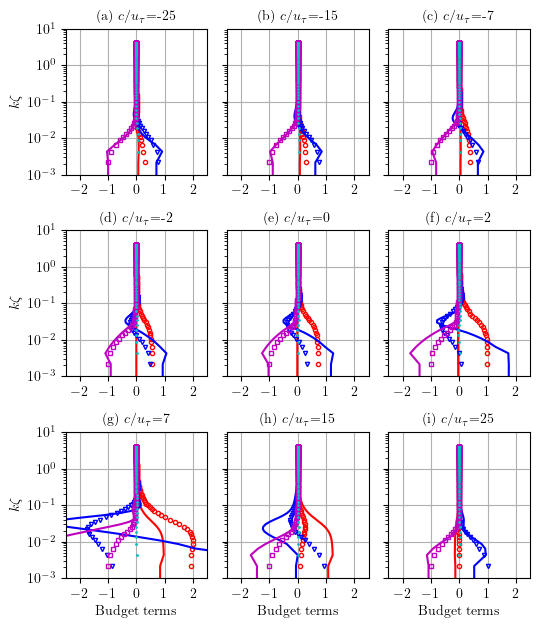

In [44]:
#Wave-induced energy budget
plt.figure(18,figsize=(5.5,8))
font_size=10
model_type=3
for n in range(num_data-1):
    if n<num_data-1:
        print(n)
        ax1=plt.subplot(4,3,n+1)
        ax1.set_title(f'({chr(97 + n)}) $c/u_\\tau$={c_array[n]}', fontsize=font_size)
    else:
        print(n,num_data)
        ax1=plt.subplot(4,3,n+2)
        ax1.set_title(f'({chr(97 + n)}) Flat wall', fontsize=font_size)
    normalisation=np.abs(1/wave_viscous_dissipation[0,n])
    
    #plt.semilogy(-normalisation*wave_production_mean[:,n],linestyle='--',z_data,color='r',label=r'$-\langle\tau_{ij}^w\rangle\frac{\partial \langle u_i\rangle}{\partial \xi_j}$')

    plt.semilogy(-normalisation*taup_13_production_2[:,n],k_wavno*z_data,color='r',marker='o',markersize=3,markerfacecolor='none',label=r'$\left\langle\widetilde{\tau}_{ij}^{p}\frac{\partial\widetilde{u}_i}{\partial \xi_j}\right\rangle$',linestyle='none')
    plt.semilogy(-normalisation*taup_13_production_2_model[0:-1,model_type,n],k_wavno*z_data[0:-1],color='r',linestyle='-',label=r'$\left\langle\widetilde{\tau}_{ij}^{p}\frac{\partial\widetilde{u}_i}{\partial \xi_j}\right\rangle$ (Model)')
    
    plt.semilogy(-normalisation*wave_transport[:,n],k_wavno*z_data,color='b',marker='v',markersize=3,markerfacecolor='none',label=r'$-{\partial T^w_j}/{\partial \xi_j}$',linestyle='none')
    plt.semilogy(-normalisation*wave_transport_model[0:-1,model_type,n],k_wavno*z_data[0:-1],color='b',linestyle='-',label=r'$-{\partial T^w_j}/{\partial \xi_j}$ (Model)')

    #plt.semilogy(-normalisation* ui_tilde_taup_i3_tilde_transport_model[:,1,n],z_data,color='c',linestyle='--',label=r'$-{\partial T^w_j}/{\partial \xi_j}$ (visc)')
    #plt.semilogy(-normalisation* ui_tilde_taup_i3_tilde_transport[:,n],z_data,color='b',linestyle='--',label=r'$-{\partial T^w_j}/{\partial \xi_j}$ (visc)')
   
    
    plt.semilogy(-normalisation*wave_viscous_dissipation[:,n],k_wavno*z_data,color='m',marker='s',markersize=3,markerfacecolor='none',label=r'$\left\langle\widetilde{\tau}_{ij}^\nu\frac{\partial\widetilde{u}_i}{\partial \xi_j}\right\rangle$',linestyle='none')
    plt.semilogy(-normalisation*wave_viscous_dissipation_model[0:-1,model_type,n],k_wavno*z_data[0:-1],color='m',linestyle='-')
    
    
    #plt.semilogy(-normalisation*wave_to_turbulence_transfer[:,n],z_data,color='k',label=r'$\left\langle\widetilde{\tau}_{ij}\frac{\partial\widetilde{u}_i}{\partial \xi_j}\right\rangle$')
    #plt.semilogy(-normalisation*wave_SGS_dissipation[:,n],z_data,color='c',label=r'$\left\langle\widetilde{\tau}_{ij}^{\mathrm{SGS}}\frac{\partial\widetilde{u}_i}{\partial \xi_j}\right\rangle$')
    
    plt.semilogy(normalisation*(-1*wave_production_mean[0:-1:2,n] \
                 -taup_13_production_2[0:-1:2,n] \
                 -wave_transport[0:-1:2,n] \
                 -1*wave_to_turbulence_transfer[0:-1:2,n] \
                 -wave_viscous_dissipation[0:-1:2,n] \
                 -1*wave_SGS_dissipation[0:-1:2,n]),k_wavno*z_data[0:-1:2],color='c',marker='o',linestyle='none',markersize=1)

        
    plt.grid(True)
    ax1.tick_params(labelsize=font_size)
    
    ax1.set_xlim(-2.5,2.5)
    ax1.set_xticks([-2,-1,0,1,2] )
    plt.ylim(1e-3,10)
    if  n == 0 or n == 3 or n == 6:
        ax1.set_ylabel('$k \zeta$',fontsize=font_size)
    else:
        plt.yticks([1e-3,1e-2,1e-1,1],[])
    if n > 5:
        ax1.set_xlabel('Budget terms',fontsize=font_size)

plt.savefig('wave_energy_budget_nuT2_comparison.png',format='png',dpi=600,bbox_inches='tight',
            transparent=False,pad_inches=0.01)

    
plt.show()